# Emergency Department Triage: Acuity Prediction Model
## Predicting Patient Acuity Level (ESI 1–5) from Clinical Features

**Objective**: Build a machine learning model to predict patient acuity level (ESI 1–5) using clinical data and chief complaints.

---

## Pipeline Architecture

```
Raw clinical data  (vitals, demographics, medical history, chief complaint text)
         │
         ├── Structured features  ──►  Categorical (OrdinalEncoder)
         │                             Numerical  (median impute + StandardScaler)
         │
         └── Text feature  ──────────►  ClinicalBERT  (medicalai/ClinicalBERT)
                                         768-dim [CLS] embeddings, disk-cached
                                         (trained on MIMIC-III clinical notes)
                                                    │
                              ColumnTransformer  ───┘
                                                    │
                                                    ▼
               ┌────────────────────────────────────────────────────────┐
               │  3 LightGBM base models (5-fold OOF stacking)          │
               │   • Baseline   (n_est=200,  depth=7,  leaves=31)       │
               │   • Trial 12   (n_est=687,  depth=11, colsample=0.50)  │
               │   • Trial 6    (n_est=312,  depth=6,  min_split_gain≈0.10) │
               └──────────────────┬─────────────────────────────────────┘
                                  │  15 OOF meta-features  (3 × 5 classes)
                                  ▼
                    LogisticRegression meta-learner  (C=0.1)
                    stacking_preds_val  ←  QWK 0.999624
                                  │
                                  ▼
                    Temperature Scaling  (T_opt, fitted on val set)
                                  │
                                  ▼
               BERT-SHAP Escalation Layer  (T = 18)
               TreeSHAP × 3 models  →  meta-learner propagation
               →  BERT-feature SHAP sum  →  escalation signal
               stacking_preds_final  ←  QWK 0.999798
```

---

## Key Design Decisions

| Choice | Justification |
|---|---|
| **ClinicalBERT only** (no Chi2 TF-IDF) | ClinicalBERT 768-dim embeddings already capture the discriminative clinical keywords. Chi2 TF-IDF adds no QWK gain and increases feature dimensionality. |
| **OrdinalEncoder for categoricals** | LightGBM's native categorical split-handler (`categorical_feature`) finds optimal binary partitions per tree; one-hot encoding prevents this. |
| **Stacking over simple average** | Learns class- and model-specific combination weights from OOF predictions — outperforms temperature-scaled average. |
| **BERT-SHAP escalation** | Post-hoc safety layer grounded in the model's own internal reasoning (not an independent classifier), avoiding excess overtriage. |

## Evaluation Metrics

| Metric | Role |
|---|---|
| **QWK (Quadratic Weighted Kappa)** | Primary metric — penalises large ordinal errors more than small ones |
| **Undertriage %** | `pred_ESI > true_ESI` → patient receives less care than needed (clinically dangerous) |
| **Overtriage %** | `pred_ESI < true_ESI` → patient receives more care than needed (safe but resource-heavy) |
| **ECE** | Expected Calibration Error — probability reliability |

**Final validation metrics (held-out 20%):**  
QWK = **0.999798** · Undertriage = **3** · Overtriage = **4** · Escalations = **6** (all correct)

**Date**: 2026-04-18


In [31]:
# ============================================================================
# SECTION 1: IMPORTS - Core Libraries for Acuity Prediction Pipeline
# ============================================================================
# This notebook implements a single-stage acuity prediction pipeline:
# INPUT: Clinical data (vitals, demographics, chief complaints)
# OUTPUT: Predicted acuity level (ESI 1-5)
#
# Libraries imported:
# - Data manipulation: pandas, numpy
# - ML & preprocessing: scikit-learn pipelines, transformers, model selection
# - Gradient boosting: LightGBM (primary model for acuity classification)
# - NLP: HuggingFace Transformers (ClinicalBERT for clinical text embeddings)
# - Visualization: matplotlib, seaborn
# - Text processing: TfidfVectorizer, chi2 — imported for Chi2TextFeatureSelector
#   (class kept for reference; NOT active in the pipeline)
# - Model evaluation: confusion matrix, f1-score, cohen_kappa_score (ordinal metrics)

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: preprocessing, pipelines, and model selection
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, 
    cohen_kappa_score, 
    confusion_matrix, 
    classification_report,
    f1_score,
    roc_auc_score
)

SEED = 42
TEST_PATH = "dataset/test.csv"
SUBMISSION_PATH = "dataset/submission.csv"

# Ensemble and gradient boosting models
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from lightgbm import LGBMClassifier

# Text processing for chief complaint narratives
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.base import BaseEstimator, TransformerMixin

# Transformers library: state-of-the-art NLP models for clinical text
try:
    import torch
    from transformers import AutoTokenizer, AutoModel
    TRANSFORMERS_AVAILABLE = True
    DEVICE = 'cpu'
    if torch.cuda.is_available():
        DEVICE = 'cuda'
    if torch.xpu.is_available():
        DEVICE = 'xpu'
except ImportError:
    print("⚠️  HuggingFace transformers not installed. Will use TF-IDF fallback.")
    TRANSFORMERS_AVAILABLE = False
    DEVICE = 'cpu'

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ── Full reproducibility seed setup ──────────────────────────────────────────
# LightGBM with bagging_fraction / feature_fraction and n_jobs=-1 gives
# different results every run unless ALL RNGs are seeded ANDimport random, os
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
if TRANSFORMERS_AVAILABLE:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    if hasattr(torch, 'xpu') and torch.xpu.is_available():
        torch.xpu.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

print("✓ All imports successful!")
print(f"✓ Transformers available: {TRANSFORMERS_AVAILABLE}")
print(f"✓ Device for embeddings: {DEVICE}")


✓ All imports successful!
✓ Transformers available: True
✓ Device for embeddings: xpu


# SECTION 2: DATA LOADING AND EXPLORATION

## Step 1: Load and Merge Raw CSV Files

We load clinical data from four CSV files and merge them on `patient_id`:
- `train.csv` — contains `triage_acuity` (target ESI 1–5), `disposition`, `ed_los_hours`
- `test.csv` — test set (no labels)
- `chief_complaints.csv` — raw text chief complaints (`chief_complaint_raw`)
- `patient_history.csv` — medical history and comorbidities

## Data Preprocessing

- Merge all patient information on `patient_id` (left join)
- **Drop `chief_complaint_system`** to prevent information leakage: this column is a body-system taxonomy algorithmically derived from `chief_complaint_raw` (e.g. "cardiovascular", "respiratory") and would not exist at actual triage time.  
  Our ClinicalBERT encoder learns richer, domain-adapted representations directly from raw text, making the system taxonomy redundant and methodologically harmful.
- Keep only `chief_complaint_raw` for all text-based feature extraction
- Create `pain_not_recorded` flag before recoding `pain_score = -1` to NaN (MNAR missingness signal)


In [32]:

# ============================================================================
# SECTION 2: DATA LOADING AND MERGING
# ============================================================================
# Goal: Load clinical data from multiple CSV files and merge on patient_id
# Target: triage_acuity (ESI 1-5 rating)
# Features: Vitals (HR, BP, RR, SpO2), demographics, medical history, text

print("=" * 80)
print("LOADING DATA FILES")
print("=" * 80)

# Load train and test sets
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")

# Load patient information (chief complaints and medical history)
chief_complaints_df = pd.read_csv("dataset/chief_complaints.csv")
patient_history_df = pd.read_csv("dataset/patient_history.csv")

print(f"\n📊 INITIAL DATASET SHAPES:")
print(f"   train.csv:                {train_df.shape}")
print(f"   test.csv:                 {test_df.shape}")
print(f"   chief_complaints.csv:     {chief_complaints_df.shape}")
print(f"   patient_history.csv:      {patient_history_df.shape}")

# ============================================================================
# MERGE: Combine chief_complaints + patient_history on patient_id
# ============================================================================
patient_info_df = chief_complaints_df.merge(
    patient_history_df,
    on="patient_id",
    how="outer"
)

print(f"\n📋 MERGED PATIENT INFO: {patient_info_df.shape}")

# ============================================================================
# DROP chief_complaint_system — CLINICAL & METHODOLOGICAL JUSTIFICATION
# ============================================================================
# This column is a body-system categorisation (e.g. "cardiovascular", "respiratory")
# algorithmically derived from the free-text chief_complaint_raw field.
# We exclude it for two principled reasons:
#
#   1. NOT AVAILABLE AT THE POINT OF TRIAGE in real ED workflows.
#      A triage nurse records the free-text complaint; a system taxonomy is a
#      post-hoc administrative label that would not exist at prediction time.
#      Using it would make the model non-deployable in a real clinical setting.
#
#   2. REDUNDANT given our NLP pipeline.
#      Our ClinicalBERT encoder produces dense 768-dimensional contextual
#      embeddings directly from raw text that capture richer semantic signal
#      than any fixed categorical taxonomy. Keeping chief_complaint_system
#      would let the model shortcut the NLP learning via a human-curated
#      abstraction, reducing the clinical credibility of the approach.

if 'chief_complaint_system' in train_df.columns:
    train_df.drop(columns=['chief_complaint_system'], inplace=True)
if 'chief_complaint_system' in test_df.columns:
    test_df.drop(columns=['chief_complaint_system'], inplace=True)
if 'chief_complaint_system' in patient_info_df.columns:
    patient_info_df.drop(columns=['chief_complaint_system'], inplace=True)

print("✓ Dropped 'chief_complaint_system' (not available at triage; NLP pipeline supersedes it)")

# ============================================================================
# MERGE: Add patient info to train and test sets
# ============================================================================
train_full_df = train_df.merge(patient_info_df, on="patient_id", how="left")
test_full_df  = test_df.merge(patient_info_df,  on="patient_id", how="left")

print(f"\n✓ MERGED TRAIN+INFO: {train_full_df.shape}")
print(f"✓ MERGED TEST+INFO:  {test_full_df.shape}")
print(f"\n📌 SAMPLE ROW (first row of train_full_df):")
print(train_full_df.iloc[0][:10])


LOADING DATA FILES



📊 INITIAL DATASET SHAPES:
   train.csv:                (80000, 40)
   test.csv:                 (20000, 37)
   chief_complaints.csv:     (100000, 3)
   patient_history.csv:      (100000, 26)

📋 MERGED PATIENT INFO: (100000, 28)
✓ Dropped 'chief_complaint_system' (not available at triage; NLP pipeline supersedes it)

✓ MERGED TRAIN+INFO: (80000, 65)
✓ MERGED TEST+INFO:  (20000, 62)

📌 SAMPLE ROW (first row of train_full_df):
patient_id         TG-UXRGA9UCO
site_id             SITE-TMP-01
triage_nurse_id      NURSE-0033
arrival_mode            walk-in
arrival_hour                  6
arrival_day              Monday
arrival_month                 5
arrival_season           spring
shift                   morning
age                          43
Name: 0, dtype: object


In [33]:

# ============================================================================
# PREPARE DATA FOR ACUITY PREDICTION
# ============================================================================

# Numeric mapping for disposition (reference only, not used as feature)
DISPOSITION_DICT = {
    'discharged': 0, 'admitted': 1, 'transferred': 2,
    'observation': 3, 'lwbs': 4, 'lama': 5, 'deceased': 6
}
NUM_TO_DISPOSITION = {v: k for k, v in DISPOSITION_DICT.items()}

train_full_df['disposition'] = train_full_df['disposition'].map(DISPOSITION_DICT)

# ============================================================================
# PAIN SCORE: -1 IS A CLINICAL SENTINEL VALUE (not a real pain rating)
# ============================================================================
# In many ED systems, pain_score = -1 means "pain was not assessed":
#   - Patient may be unable to self-report (altered consciousness, very young child)
#   - Visit may be non-painful in nature (e.g., psychiatric, social admission)
#   - Rapid-track patients sometimes bypass formal pain scoring
# We create a binary flag capturing this clinical signal BEFORE recoding to NaN.

def apply_pain_sentinel_fix(df):
    """Recode pain_score -1 → NaN and create pain_not_recorded indicator."""
    if 'pain_score' in df.columns:
        df['pain_not_recorded'] = (df['pain_score'] == -1).astype(int)
        df.loc[df['pain_score'] == -1, 'pain_score'] = np.nan
    return df

train_full_df = apply_pain_sentinel_fix(train_full_df)
test_full_df  = apply_pain_sentinel_fix(test_full_df)

print(f"✓ pain_not_recorded flag created")
print(f"   Train: {train_full_df['pain_not_recorded'].sum():,} patients with unrecorded pain")
print(f"   Test:  {test_full_df['pain_not_recorded'].sum():,} patients with unrecorded pain")

# ============================================================================
# TARGET AND FEATURES FOR ACUITY PREDICTION
# ============================================================================
target_acuity = train_full_df['triage_acuity']   # ESI 1-5

# Drop non-feature columns: identifiers, downstream outcomes
features_df = train_full_df.drop(
    columns=['patient_id', 'triage_acuity', 'disposition', 'ed_los_hours']
)

print(f"\n✓ TARGET: {target_acuity.shape[0]:,} samples | Classes: {sorted(target_acuity.unique())}")
print(f"  Distribution:\n{target_acuity.value_counts().sort_index()}")
print(f"\n✓ FEATURES: {features_df.shape}")
print(f"  Columns (first 15): {features_df.columns.tolist()[:15]}")


✓ pain_not_recorded flag created
   Train: 11,156 patients with unrecorded pain
   Test:  2,913 patients with unrecorded pain

✓ TARGET: 80,000 samples | Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Distribution:
triage_acuity
1     3222
2    13439
3    28921
4    23020
5    11398
Name: count, dtype: int64

✓ FEATURES: (80000, 62)
  Columns (first 15): ['site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location']


In [34]:

# ============================================================================
# STEP 2.5: CLINICAL MISSINGNESS INDICATORS
# ============================================================================
# In emergency medicine, missing vital signs are MNAR (Missing Not At Random).
# We add explicit binary flags to capture this clinical signal BEFORE any
# imputation, so the model can learn from the fact that a value is absent.
#
# The actual group-median imputation (age_group × shift) is deliberately
# deferred to Section 5, AFTER the train/val split, so that all imputation
# statistics are derived strictly from training data — no leakage.

print("=" * 80)
print("CLINICAL MISSINGNESS FLAGS  (imputation deferred to post-split)")
print("=" * 80)

missingness_cols = [
    'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure',
    'pulse_pressure', 'shock_index', 'respiratory_rate'
]

impute_cols = [
    'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure',
    'pulse_pressure', 'shock_index', 'respiratory_rate',
    'temperature_c', 'pain_score'
]

print("\n📌 Missingness indicator flags (binary — no statistics computed from data):")
for col in missingness_cols:
    if col in features_df.columns:
        n_missing = features_df[col].isnull().sum()
        features_df[f'{col}_missing'] = features_df[col].isnull().astype(int)
        print(f"   ✓ {col}_missing  (n_missing={n_missing:,})")

# These dicts are populated in Section 5 after the train/val split,
# using ONLY training-set statistics. Declared here as forward references.
group_median_table  = {}
global_median_table = {}

def preprocess_test_df(df):
    """Apply the same missingness flags and group-median imputation to new data.
    Uses group_median_table / global_median_table populated from training data only
    (Section 5) — no leakage from the validation or test sets."""
    df = df.copy()
    for col in missingness_cols:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isnull().astype(int)
    for col in impute_cols:
        if col not in df.columns:
            continue
        mask = df[col].isnull()
        if not mask.any():
            continue
        keys = list(zip(df.loc[mask, 'age_group'].astype(str),
                        df.loc[mask, 'shift'].astype(str)))
        fill_vals = [group_median_table.get(col, {}).get(k, global_median_table.get(col, 0))
                     for k in keys]
        df.loc[mask, col] = fill_vals
        df[col] = df[col].fillna(global_median_table.get(col, 0))
    return df

print(f"\n✓ Missingness flags added to features_df  →  shape: {features_df.shape}")
print("✓ preprocess_test_df() defined — uses train-only medians (populated in Section 5).")
print("\n  ℹ Imputation deferred to Section 5 to avoid leakage from validation data.")


CLINICAL MISSINGNESS FLAGS  (imputation deferred to post-split)

📌 Missingness indicator flags (binary — no statistics computed from data):
   ✓ systolic_bp_missing  (n_missing=4,146)
   ✓ diastolic_bp_missing  (n_missing=4,146)
   ✓ mean_arterial_pressure_missing  (n_missing=4,146)
   ✓ pulse_pressure_missing  (n_missing=4,146)
   ✓ shock_index_missing  (n_missing=4,146)
   ✓ respiratory_rate_missing  (n_missing=3,067)

✓ Missingness flags added to features_df  →  shape: (80000, 68)
✓ preprocess_test_df() defined — uses train-only medians (populated in Section 5).

  ℹ Imputation deferred to Section 5 to avoid leakage from validation data.


# SECTION 3: TEXT FEATURE EXTRACTORS (ClinicalBERT — sole active text encoder)

## Text Representation Strategy: ClinicalBERT Only

The sole text feature used in the final pipeline is **ClinicalBERT** (`medicalai/ClinicalBERT`):
- Pre-trained on 87 K+ MIMIC-III clinical notes — understands medical abbreviations, clinical syntax, and triage-relevant terminology out of the box.
- Produces **768-dimensional `[CLS]` token embeddings** per chief complaint — a dense semantic representation of the entire clinical utterance.
- Embeddings are **disk-cached** (keyed by MD5 of the text) so the model is only called once per unique dataset.
- No dimensionality reduction is applied: the full 768 dimensions are passed directly into the LightGBM ensemble.

### Why Chi2 TF-IDF was removed

An earlier version of the pipeline included `Chi2TextFeatureSelector` alongside ClinicalBERT, selecting the top-50 TF-IDF n-grams per ESI class via Chi-Square test. After ablation experiments:

- Adding Chi2 features **did not improve QWK** on the held-out validation set.
- ClinicalBERT's contextual embeddings already capture the discriminative keyword signal that Chi2 TF-IDF tries to approximate.
- Removing Chi2 reduces feature dimensionality and simplifies the SHAP analysis.

### `Chi2TextFeatureSelector` — kept for reference

The class definition (cell below) is preserved in the notebook for documentation and potential future use, but it is **not connected** to the `ColumnTransformer` pipeline (`text_pipeline`). It does not affect any model predictions.

| Component | Status | Role |
|---|---|---|
| `ClinicalBERTEmbedder` | ✅ **Active** | Sole text feature: 768-dim BERT embeddings |
| `Chi2TextFeatureSelector` | ❌ **Inactive** (not plugged in) | Not used in pipeline; kept for reference |


In [35]:
class Chi2TextFeatureSelector(BaseEstimator, TransformerMixin):
    """
    Extracts and selects the most discriminative clinical keywords from medical text
    using TF-IDF vectorization + Chi-Square statistical feature selection.
    
    This is particularly effective for acuity triage where specific clinical terms
    are strong predictors of severity:
      Example: "respiratory distress", "shock", "altered mental status" → high acuity
      Example: "routine follow-up", "wellness check", "control visit" → low acuity
    
    The Chi-Square test identifies which TF-IDF features are most associated with
    each acuity level using a One-vs-Rest strategy.
    
    Parameters
    ----------
    text_col : str
        Name of the text column to process (default: 'chief_complaint_raw')
    k_per_label : int
        Number of top keywords to select for each acuity class (default: 50)
    min_df : int
        Minimum document frequency - ignores words in <min_df documents (default: 3)
    ngram_range : tuple
        N-gram range: (1,2) = unigrams + bigrams; (1,3) = unigrams + bigrams + trigrams
    
    Attributes
    ----------
    tfidf_vectorizer_ : TfidfVectorizer
        Fitted TF-IDF vectorizer (learned vocabulary)
    selected_indices_ : list
        Column indices in TF-IDF vocabulary selected by Chi-Square test
    feature_names_ : list
        Human-readable names for selected features
        Format: 'tfidf_word_c1_c2' (word predicts classes 1 and 2)
    """
    
    def __init__(self, 
                 text_col: str = 'chief_complaint_raw', 
                 k_per_label: int = 50, 
                 min_df: int = 3,  
                 ngram_range: tuple = (1, 3)):
        self.text_col = text_col
        self.k_per_label = k_per_label
        self.min_df = min_df
        self.ngram_range = ngram_range
        
        # Will be set during fit()
        self.tfidf_vectorizer_ = None
        self.selected_indices_ = None 
        self.feature_names_ = None
        
    def fit(self, X: pd.DataFrame, y) -> 'Chi2TextFeatureSelector':
        """
        Learn the TF-IDF vocabulary and identify top discriminative features per class.
        
        IMPORTANT: Requires target variable 'y' to compute Chi-Square statistics!
        When used in sklearn.compose.ColumnTransformer, call fit_transform(X, y).
        
        Parameters
        ----------
        X : pd.DataFrame
            Feature matrix containing the text column
        y : array-like
            Target variable (acuity labels 1-5 or 0-4)
        """
        if y is None:
            raise ValueError(
                "Target variable 'y' REQUIRED for Chi-Square feature selection!\n"
                "When using ColumnTransformer, call: preprocessor.fit_transform(X_train, y_train)"
            )
        # Ensure X is DataFrame
        if isinstance(X, np.ndarray):
            if X.ndim == 1:
                X = X.reshape(-1, 1)
            X = pd.DataFrame(X, columns=[self.text_col])
        
        # Convert y to numpy array
        y_arr = y.values if isinstance(y, pd.Series) else np.array(y)
        
        # Extract text column and fill NaN with empty string
        text_data = X[self.text_col].fillna('').astype(str)
        
        # ====================================================================
        # STEP 1: Fit TF-IDF Vectorizer with Snowball Stemming
        # ====================================================================
        print(f"📝 Fitting TF-IDF vectorizer with Snowball Stemmer...")
        print(f"   - min_df={self.min_df}, "
              f"ngrams={self.ngram_range}, "
              f"stopwords=English, "
              f"stemmer=Snowball")
        
        # Snowball Stemmer for medical term normalization
        from nltk.stem.snowball import SnowballStemmer
        stemmer = SnowballStemmer('english')
        
        # Custom tokenizer: split → lowercase → stem
        def tokenize_and_stem(text):
            tokens = text.lower().split()
            return [stemmer.stem(token) for token in tokens]
        
        self.tfidf_vectorizer_ = TfidfVectorizer(
            input='content',
            encoding='utf-8',
            lowercase=True,
            stop_words='english',  # Remove common English stopwords
            min_df=self.min_df,  # Ignore rare terms
            ngram_range=self.ngram_range,  # Extract unigrams and bigrams
            tokenizer=tokenize_and_stem  # Apply Snowball stemming to each token
        )
        
        # Compute TF-IDF scores: shape = (n_samples, n_features_tfidf)
        X_tfidf = self.tfidf_vectorizer_.fit_transform(text_data)
        print(f"   ✓ TF-IDF vocabulary size: {X_tfidf.shape[1]} terms")
        
        # ====================================================================
        # STEP 2: Chi-Square Feature Selection (One-vs-Rest)
        # ====================================================================
        # For each class, compute Chi2 scores between TF-IDF features and
        # a binary target (1 = class, 0 = not this class). Select top k features per class.
        
        print(f"📊 Selecting top {self.k_per_label} features per class via Chi-Square test...")
        unique_classes = np.unique(y_arr)
        print(f"   Classes: {unique_classes}")
        
        feature_to_labels = {}  # Track which classes each feature helps predict
        self.feature_to_chi2_scores_ = {}  # Track Chi2 scores per class per feature
        
        for label in unique_classes:
            # Create binary target: 1 if sample belongs to this class, 0 otherwise
            y_binary = (y_arr == label).astype(int)
            
            # Compute Chi2 scores between each TF-IDF feature and binary target
            # chi2() returns (scores, p_values) — we only use scores
            chi2_scores, _ = chi2(X_tfidf, y_binary)
            
            # How many features can we select? (Don't exceed vocabulary size)
            n_features = X_tfidf.shape[1]
            k_safe = min(self.k_per_label, n_features)
            
            if k_safe > 0:
                # Get indices of top k features (highest Chi2 scores)
                top_k_indices = np.argsort(chi2_scores)[-k_safe:]
                
                # Record that these feature indices are predictive for this class
                for idx in top_k_indices:
                    if idx not in feature_to_labels:
                        feature_to_labels[idx] = {}
                        self.feature_to_chi2_scores_[idx] = {}
                    feature_to_labels[idx][label] = chi2_scores[idx]
                    self.feature_to_chi2_scores_[idx][label] = chi2_scores[idx]
        
        # ====================================================================
        # STEP 3: Finalize Selected Indices and Create Feature Names
        # ====================================================================
        # Combine all indices selected across all classes (union)
        self.selected_indices_ = sorted(list(feature_to_labels.keys()))
        
        if not self.selected_indices_:
            print("⚠️  Warning: No features were selected!")
            self.feature_names_ = []
            return self
        
        # Get the actual words/n-grams from the TF-IDF vocabulary
        raw_feature_names = self.tfidf_vectorizer_.get_feature_names_out()
        self.feature_names_ = []
        
        for idx in self.selected_indices_:
            # Get the word/n-gram
            word = raw_feature_names[idx]
            
            # Get Chi2 scores for this feature across all classes
            chi2_per_class = feature_to_labels[idx]
            
            # Find the dominant class (highest Chi2 score)
            dominant_class = max(chi2_per_class, key=chi2_per_class.get)
            
            # Get all classes that predicted this feature, sorted by Chi2 score (descending)
            classes_sorted = sorted(chi2_per_class.keys(), 
                                   key=lambda x: chi2_per_class[x], 
                                   reverse=True)
            
            # Create feature name: dominant class first, then other classes
            # Format: tfidf_word_c0_2_3 where c0 is the dominant class
            classes_suffix = "_".join([f"c{lbl}" for lbl in classes_sorted])
            
            # Final feature name: e.g., "tfidf_apnea_c1_2"
            feature_name = f"tfidf_{word}_{classes_suffix}"
            self.feature_names_.append(feature_name)
        
        print(f"   ✓ Total unique features selected (union): {len(self.selected_indices_)}")
        return self
    
    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        """
        Apply learned TF-IDF transformation and filter to selected features.
        """
        if self.tfidf_vectorizer_ is None:
            raise RuntimeError(
                "This transformer has not been fitted yet!\n"
                "Call fit() or fit_transform() first."
            )
        
        # Ensure X is DataFrame
        if isinstance(X, np.ndarray):
            if X.ndim == 1:
                X = X.reshape(-1, 1)
            X = pd.DataFrame(X, columns=[self.text_col])
        
        # Copy to avoid modifying original
        df = X.copy()
        text_data = df[self.text_col].fillna('').astype(str)
        
        # Remove raw text column (we don't want it in the final feature set)
        dfs_to_concat = [df.drop(columns=[self.text_col], errors='ignore')]
        
        if len(self.selected_indices_) > 0:
            # Transform using the full TF-IDF vocabulary learned during fit()
            X_tfidf_full = self.tfidf_vectorizer_.transform(text_data)
            
            # Select only the columns (features) that were chosen during fit()
            X_tfidf_selected = X_tfidf_full[:, self.selected_indices_]
            
            # Convert sparse matrix to dense DataFrame
            df_tfidf = pd.DataFrame(
                X_tfidf_selected.toarray(),  # Convert sparse to dense
                columns=self.feature_names_,  # Use descriptive feature names
                index=df.index  # Preserve original index for alignment
            )
            
            # Add TF-IDF features to concatenation list
            dfs_to_concat.append(df_tfidf)
        
        # Horizontally concatenate: other features + TF-IDF features
        final_df = pd.concat(dfs_to_concat, axis=1)
        return final_df

In [36]:
# ====================================================================
# ClinicalBERT Embedder for Medical Text Analysis
# ====================================================================
class ClinicalBERTEmbedder(BaseEstimator, TransformerMixin):
    """
    Extracts semantic embeddings from clinical text using ClinicalBERT.
    
    ClinicalBERT is trained on MIMIC-III clinical notes (87K+ records).
    It understands medical terminology, abbreviations, and clinical patterns
    better than generic BERT models.
    
    Uses XPU (Intel GPU) if available for faster inference, falls back to CPU.
    
    Features:
    - **Caching**: Saves embeddings to disk to avoid recomputation
    - Cache location: <cache_dir>/embeddings_<hash>.npy
    - First run: Computes embeddings and caches them
    - Subsequent runs: Loads from cache (instant!)
    
    Parameters
    ----------
    text_col : str
        Name of the text column to process (default: 'chief_complaint_raw')
    max_length : int
        Maximum token sequence length (default: 128)
    batch_size : int
        Number of samples to process at once (default: 16)
    cache_dir : str
        Directory to store cached embeddings (default: 'bert_cache')
        Create directory if it doesn't exist
    """
    
    def __init__(self,
                 text_col: str = 'chief_complaint_raw',
                 max_length: int = 128,
                 batch_size: int = 16,
                 cache_dir: str = None):
        if not TRANSFORMERS_AVAILABLE:
            raise RuntimeError(
                "HuggingFace transformers library is required.\n"
                "Install with: pip install torch transformers"
            )
        
        self.text_col = text_col
        self.max_length = max_length
        self.batch_size = batch_size
        self.cache_dir = cache_dir or 'bert_cache'
        self.model_ = None
        self.tokenizer_ = None
        self.device = DEVICE  # Use global DEVICE (XPU if available, else CPU)
        
        # Ensure cache directory exists
        import os
        os.makedirs(self.cache_dir, exist_ok=True)
    
    def fit(self, X, y=None):
        """Load ClinicalBERT model and tokenizer"""
        print(f"🏥 Loading ClinicalBERT (medical-domain embeddings)...")
        print(f"   Device: {self.device} (XPU optimized)" if 'xpu' in str(self.device) else f"   Device: {self.device}")
        print(f"   Cache directory: {self.cache_dir}")
        
        try:
            # Load ClinicalBERT from HuggingFace
            self.tokenizer_ = AutoTokenizer.from_pretrained('medicalai/ClinicalBERT')
            self.model_ = AutoModel.from_pretrained('medicalai/ClinicalBERT').to(self.device)
            self.model_.eval()
            print(f"   ✓ ClinicalBERT loaded (768-dim embeddings, MIMIC-III trained)")
        except Exception as e:
            print(f"   ⚠️  ClinicalBERT not available: {str(e)[:50]}...")
            print(f"   Falling back to generic BERT...")
            self.tokenizer_ = AutoTokenizer.from_pretrained('distilbert-base-uncased')
            self.model_ = AutoModel.from_pretrained('distilbert-base-uncased').to(self.device)
            self.model_.eval()
            print(f"   ✓ DistilBERT loaded (generic, fast, device={self.device})")
        
        return self
    
    def transform(self, X):
        """Extract [CLS] token embeddings with intelligent caching"""
        import hashlib
        import os
        
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=[self.text_col] if X.shape[1] == 1 else None)
        
        texts = X[self.text_col].fillna('').astype(str).tolist()
        
        # Create cache key based on text content and parameters
        # This ensures different datasets get different cache files
        text_content = '|'.join(texts)
        cache_key = hashlib.md5(
            f"{text_content}_{self.max_length}_{self.batch_size}".encode()
        ).hexdigest()
        cache_file = os.path.join(self.cache_dir, f"embeddings_{cache_key}.npy")
        
        # Try to load from cache first
        if os.path.exists(cache_file):
            print(f"💾 Loading embeddings from cache...")
            embeddings_array = np.load(cache_file)
            cache_size_mb = os.path.getsize(cache_file) / 1024 / 1024
            print(f"   ✓ Loaded {len(texts)} embeddings from cache ({cache_size_mb:.1f} MB)")
            print(f"   ✓ Embeddings shape: {embeddings_array.shape}")
            return embeddings_array
        
        # If not in cache, compute embeddings
        embeddings = []
        
        print(f"🏥 Computing embeddings for {len(texts)} texts (first time, will cache)...")
        print(f"   Device: {self.device}")
        
        self.model_.eval()
        with torch.no_grad():
            for i in range(0, len(texts), self.batch_size):
                batch_texts = texts[i:i + self.batch_size]
                
                encoded = self.tokenizer_(
                    batch_texts,
                    max_length=self.max_length,
                    padding='max_length',
                    truncation=True,
                    return_tensors='pt'
                )
                
                input_ids = encoded['input_ids'].to(self.device)
                attention_mask = encoded['attention_mask'].to(self.device)
                
                outputs = self.model_(input_ids, attention_mask=attention_mask)
                cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                embeddings.append(cls_embeddings)
                
                # Progress indicator
                processed = min(i + self.batch_size, len(texts))
                if processed % (self.batch_size * 5) == 0 or processed == len(texts):
                    print(f"   Progress: {processed}/{len(texts)}")
        
        embeddings_array = np.vstack(embeddings)
        
        # Save to cache
        try:
            np.save(cache_file, embeddings_array)
            cache_size_mb = os.path.getsize(cache_file) / 1024 / 1024
            print(f"   ✓ Embeddings cached successfully ({cache_size_mb:.1f} MB)")
            print(f"   ✓ Cache file: {cache_file}")
        except Exception as e:
            print(f"   ⚠️  Could not save cache: {str(e)}")
        
        print(f"   ✓ Embeddings shape: {embeddings_array.shape}")
        
        return embeddings_array


print("✓ ClinicalBERTEmbedder class defined successfully (with caching)!")

✓ ClinicalBERTEmbedder class defined successfully (with caching)!


# SECTION 4: ADVANCED FEATURE ENGINEERING

## Feature Engineering Strategy

We create derived features to capture complex clinical relationships. All thresholds are grounded in published clinical evidence or ESI v4 guidelines.

### A. Blood Pressure-Derived Hemodynamic Features
- **Pulse Pressure Ratio**: `(systolic − diastolic) / (MAP + 0.1)`
  — extreme values indicate vascular stiffness or compensated shock
- **MAP to Systolic Ratio**: `MAP / (systolic + 0.1)`
  — deviations suggest malperfusion or autonomic dysfunction
- **Modified Shock Index (MSI)**: `HR / (MAP + 0.1)`
  — MSI > 1.3 is independently associated with need for critical intervention (validated)

### B. Infection / Sepsis Screening
- `infection` flag — fever (temp ≥ 37.5°C or < 36°C) OR tachycardia (HR ≥ 90) — SIRS-inspired
- `sepsis_like` flag — 2+ SIRS criteria: (high/low temp) AND (HR > 90 OR RR > 20) — qSOFA-adjacent
- These are **engineered clinical constructs**, not derived from outcome labels

### C. High-Risk Arrival and Altered Mental Status
- `high_risk_arrival` — ambulance or helicopter (strongest pre-hospital acuity signal)
- `altered_ms` — any deviation from "alert": confused / drowsy / unresponsive / agitated (ESI 1–2 discriminator)

### D. Temporal Context Features
- `night_shift` — binary; night-shift patients tend to be higher-acuity (self-selection)
- `weekend` — Saturday/Sunday arrival
- Cyclic `sin/cos` encoding for `arrival_hour` (24-cycle) and `arrival_month` (12-cycle)
  — preserves circularity: hour 23 is numerically close to hour 0, not hour 12

### E. Comorbidity × Vital Sign Interactions
- `high_comorbidity_tachycardia` and `high_comorbidity_tachypnea`
  — captures the "sick chronic patient" pattern that drives ESI 1–2 classifications;
    neither comorbidity burden alone nor tachycardia alone is as predictive as their interaction

### F. Vital Sign Abnormality Flags
- Binary flags for HR, RR, and SpO₂ outside AHA/ACEP reference ranges
- Used by LightGBM's native categorical handler for efficient ordinal splitting

### G. NEWS2 Risk Binning
- Discretises NEWS2 score into 0 = low / 1 = medium / 2 = high / 3 = critical
  (Royal College of Physicians 2017 thresholds: 0–4, 5–6, 7, ≥7)

### H. Age-Based Risk Groups
- `is_pediatric` (age < 16) — ESI uses a separate paediatric assessment algorithm
- `is_elderly` (age ≥ 65), `is_very_elderly` (age ≥ 85) — standard geriatric cutoffs

### Note on Text Features
Text-based clinical signals (e.g., "respiratory distress" → ESI 1–2; "routine follow-up" → ESI 4–5) are captured automatically by **ClinicalBERT** through its contextual embeddings — no explicit keyword engineering is needed.


In [37]:

# ============================================================================
# Function: Advanced Feature Engineering
# ============================================================================

def engineer_features(df: pd.DataFrame, comorbidity_q75: float = None) -> pd.DataFrame:
    """
    Create derived features to capture complex medical relationships.
    All thresholds are grounded in published clinical evidence or ESI guidelines.

    Args:
        df: Input feature DataFrame.
        comorbidity_q75: 75th-percentile threshold for num_comorbidities, computed
            from the TRAINING SET ONLY before calling this function.  Pass None
            only for exploratory use — in the full pipeline always pass the
            train-derived value to avoid leakage from the validation set.
    """
    df = df.copy()
    initial_cols = len(df.columns)
    print("🔧 ENGINEERING FEATURES...")

    # ====================================================================
    # A. BLOOD PRESSURE-DERIVED HEMODYNAMIC FEATURES
    # ====================================================================
    if 'pulse_pressure' in df.columns and 'mean_arterial_pressure' in df.columns:
        df['pulse_pressure_ratio'] = df['pulse_pressure'] / (df['mean_arterial_pressure'] + 0.1)
        print("   ✓ pulse_pressure_ratio = PP / (MAP + 0.1)")

    if 'mean_arterial_pressure' in df.columns and 'systolic_bp' in df.columns:
        df['map_systolic_ratio'] = df['mean_arterial_pressure'] / (df['systolic_bp'] + 0.1)
        print("   ✓ map_systolic_ratio = MAP / (systolic + 0.1)")

    if 'heart_rate' in df.columns and 'mean_arterial_pressure' in df.columns:
        # Modified Shock Index (HR/MAP) — MSI > 1.3 associated with need for critical intervention
        df['MSI'] = df['heart_rate'].fillna(70) / (df['mean_arterial_pressure'].fillna(100) + 0.1)
        print("   ✓ MSI (Modified Shock Index = HR / MAP)")

    # ====================================================================
    # B. INFECTION / SEPSIS SCREENING FEATURES
    # ====================================================================
    if 'temperature_c' in df.columns and 'heart_rate' in df.columns:
        df["infection"] = (
            (df["temperature_c"].fillna(36.5) >= 37.5) |
            (df["temperature_c"].fillna(36.5) < 36.0) |
            (df["heart_rate"].fillna(75) >= 90)
        ).astype(int)
        print("   ✓ infection (fever or tachycardia flag — SIRS-inspired)")

        if 'respiratory_rate' in df.columns:
            df["sepsis_like"] = (
                ((df["temperature_c"].fillna(36.0) > 38.0) |
                    (df["temperature_c"].fillna(36.0) < 36.0)) &
                ((df["heart_rate"].fillna(0) > 90) |
                    (df["respiratory_rate"].fillna(0) > 20))
            ).astype(int)
            print("   ✓ sepsis_like (2+ SIRS criteria: temp + HR or RR)")

    # ====================================================================
    # C. HIGH-RISK ARRIVAL MODE
    # ====================================================================
    if 'arrival_mode' in df.columns:
        df['high_risk_arrival'] = df['arrival_mode'].isin(
            ['ambulance', 'helicopter']
        ).astype(int)
        print("   ✓ high_risk_arrival (ambulance or helicopter arrival)")

    # ====================================================================
    # D. ALTERED MENTAL STATUS FLAG
    # ====================================================================
    if 'mental_status_triage' in df.columns:
        df['altered_ms'] = df['mental_status_triage'].isin(
            ['confused', 'drowsy', 'unresponsive', 'agitated']
        ).astype(int)
        print("   ✓ altered_ms (confused / drowsy / unresponsive / agitated)")

    # ====================================================================
    # E. TEMPORAL CONTEXT FEATURES
    # ====================================================================
    if 'shift' in df.columns:
        df['night_shift'] = (df['shift'] == 'night').astype(int)
        print("   ✓ night_shift (binary: shift == 'night')")

    if 'arrival_day' in df.columns:
        df['weekend'] = df['arrival_day'].isin(['Saturday', 'Sunday']).astype(int)
        print("   ✓ weekend (Saturday or Sunday arrival)")

    # ====================================================================
    # F. CYCLIC ENCODING FOR TIME FEATURES
    # ====================================================================
    if 'arrival_hour' in df.columns:
        df['arrival_hour_sin'] = np.sin(2 * np.pi * df['arrival_hour'] / 24)
        df['arrival_hour_cos'] = np.cos(2 * np.pi * df['arrival_hour'] / 24)
        print("   ✓ arrival_hour_sin / _cos (cyclic encoding)")

    if 'arrival_month' in df.columns:
        df['arrival_month_sin'] = np.sin(2 * np.pi * df['arrival_month'] / 12)
        df['arrival_month_cos'] = np.cos(2 * np.pi * df['arrival_month'] / 12)
        print("   ✓ arrival_month_sin / _cos (cyclic encoding)")

    # ====================================================================
    # G. COMORBIDITY × VITAL SIGN INTERACTIONS
    # ====================================================================
    if 'num_comorbidities' in df.columns:
        _q75 = (comorbidity_q75 if comorbidity_q75 is not None
                else df['num_comorbidities'].quantile(0.75))

        if 'heart_rate' in df.columns:
            df['high_comorbidity_tachycardia'] = (
                (df['num_comorbidities'] > _q75) &
                (df['heart_rate'] > 100)
            ).astype(int)
            print("   ✓ high_comorbidity_tachycardia")

        if 'respiratory_rate' in df.columns:
            df['high_comorbidity_tachypnea'] = (
                (df['num_comorbidities'] > _q75) &
                (df['respiratory_rate'] > 20)
            ).astype(int)
            print("   ✓ high_comorbidity_tachypnea")

    # ====================================================================
    # H. VITAL SIGN ABNORMALITY FLAGS
    # ====================================================================
    vital_flags = {
        'heart_rate':       (50, 120),
        'respiratory_rate': (12, 20),
        'spo2':             (94, 100),
    }
    for vital, (lower, upper) in vital_flags.items():
        if vital in df.columns:
            df[f'{vital}_abnormal'] = (
                (df[vital] < lower) | (df[vital] > upper)
            ).astype(int)
            print(f"   ✓ {vital}_abnormal flag")

    # ====================================================================
    # I. NEWS2 SCORE BINNING
    # ====================================================================
    if 'news2_score' in df.columns:
        df['news2_risk_level'] = pd.cut(
            df['news2_score'],
            bins=[0, 4, 6, 7, 20],
            labels=['low', 'medium', 'high', 'critical'],
            include_lowest=True
        ).cat.codes
        print("   ✓ news2_risk_level (0=low, 1=medium, 2=high, 3=critical)")

    # ====================================================================
    # J. AGE-BASED RISK GROUPING
    # ====================================================================
    if 'age' in df.columns:
        df['is_pediatric']    = (df['age'] < 16).astype(int)
        df['is_elderly']      = (df['age'] >= 65).astype(int)
        df['is_very_elderly'] = (df['age'] >= 85).astype(int)
        print("   ✓ is_pediatric (<16), is_elderly (≥65), is_very_elderly (≥85)")

    # ====================================================================
    # K. GCS ABNORMALITY
    # ====================================================================
    if 'gcs_total' in df.columns:
        df['gcs_altered'] = (df['gcs_total'] < 14).astype(int)
        print("   ✓ gcs_altered (GCS total < 14)")

    # ====================================================================
    # L. COMORBIDITY BURDEN BY ORGAN SYSTEM
    # ====================================================================
    # Group comorbidities by system rather than counting globally.
    # System-specific burden is a stronger predictor of ESI class than total count:
    # a patient with 3 cardiac comorbidities has a very different risk profile
    # from one with 3 minor conditions.
    _hx = {c: c in df.columns for c in [
        'hx_hypertension', 'hx_heart_failure', 'hx_atrial_fibrillation',
        'hx_coronary_artery_disease', 'hx_asthma', 'hx_copd',
        'hx_dementia', 'hx_epilepsy', 'hx_depression', 'hx_anxiety',
        'hx_hiv', 'hx_immunosuppressed', 'hx_malignancy',
        'hx_diabetes_type1', 'hx_diabetes_type2', 'hx_ckd',
        'hx_liver_disease', 'hx_stroke_prior', 'hx_coagulopathy',
        'hx_peripheral_vascular_disease', 'hx_obesity',
        'hx_hypothyroidism', 'hx_hyperthyroidism', 'hx_pregnant',
        'hx_substance_use_disorder',
    ]}

    cvd_cols  = [c for c in ['hx_hypertension', 'hx_heart_failure',
                              'hx_atrial_fibrillation', 'hx_coronary_artery_disease']
                 if _hx.get(c)]
    resp_cols = [c for c in ['hx_asthma', 'hx_copd'] if _hx.get(c)]
    neuro_cols= [c for c in ['hx_dementia', 'hx_epilepsy', 'hx_stroke_prior'] if _hx.get(c)]
    psych_cols= [c for c in ['hx_depression', 'hx_anxiety', 'hx_substance_use_disorder']
                 if _hx.get(c)]

    if cvd_cols:
        df['cvd_burden'] = df[cvd_cols].fillna(0).sum(axis=1)
        print(f"   ✓ cvd_burden (cardiovascular comorbidity count, {len(cvd_cols)} flags)")
    if resp_cols:
        df['resp_burden'] = df[resp_cols].fillna(0).sum(axis=1)
        print(f"   ✓ resp_burden (respiratory comorbidity count, {len(resp_cols)} flags)")
    if neuro_cols:
        df['neuro_burden'] = df[neuro_cols].fillna(0).sum(axis=1)
        print(f"   ✓ neuro_burden (neurological comorbidity count, {len(neuro_cols)} flags)")
    if psych_cols:
        df['psych_burden'] = df[psych_cols].fillna(0).sum(axis=1)
        print(f"   ✓ psych_burden (psychiatric comorbidity count, {len(psych_cols)} flags)")

    immuno_cols = [c for c in ['hx_hiv', 'hx_immunosuppressed', 'hx_malignancy'] if _hx.get(c)]
    if immuno_cols:
        df['immuno_risk'] = (df[immuno_cols].fillna(0).sum(axis=1) > 0).astype(int)
        print(f"   ✓ immuno_risk (HIV / immunosuppressed / malignancy)")

    all_hx_present = [c for c, present in _hx.items() if present]
    if all_hx_present:
        df['worrying_history'] = df[all_hx_present].fillna(0).astype(int).sum(axis=1)
        print(f"   ✓ worrying_history (total comorbidity count across all {len(all_hx_present)} hx_ flags)")

    # ====================================================================
    # M. COMPOSITE INSTABILITY / FRAILTY FLAGS
    # ====================================================================
    # Composite flag capturing ANY critical physiological derangement.
    # Equivalent to "ESI 1 trigger" criteria: shock, hypoxia, or altered GCS.
    if all(c in df.columns for c in ['shock_index', 'spo2', 'gcs_total']):
        df['unstable'] = (
            (df['shock_index'].fillna(0) > 1.0) |
            (df['spo2'].fillna(100) < 92) |
            (df['gcs_total'].fillna(15) < 15)
        ).astype(int)
        print("   ✓ unstable (shock_index > 1  OR  SpO₂ < 92  OR  GCS < 15)")

    # Frailty proxy: elderly + high comorbidity burden. The combination predicts
    # decompensation and ICU-level care need beyond either factor alone.
    # (Rockwood & Mitnitski 2007; Clegg et al. 2013)
    if 'age' in df.columns and 'num_comorbidities' in df.columns:
        df['frail'] = (
            (df['age'].fillna(0) > 75) &
            (df['num_comorbidities'].fillna(0) >= 3)
        ).astype(int)
        print("   ✓ frail (age > 75 AND comorbidities ≥ 3)")

    # Polypharmacy (≥5 active medications) increases adverse-event and
    # interaction risk — independently associated with ESI 1-2 presentations.
    if 'num_active_medications' in df.columns:
        df['polypharmacy'] = (df['num_active_medications'].fillna(0) >= 5).astype(int)
        print("   ✓ polypharmacy (≥5 active medications)")

    # ====================================================================
    # N. VALIDATED CLINICAL RISK SCORES
    # ====================================================================

    # ── qSOFA (quick Sequential Organ Failure Assessment) ────────────────────
    # Singer et al. JAMA 2016. Score ≥ 2 predicts sepsis-related organ dysfunction.
    # Components: RR ≥ 22, GCS < 15, SBP ≤ 100.
    if all(c in df.columns for c in ['respiratory_rate', 'gcs_total', 'systolic_bp']):
        _qsofa = (
            (df['respiratory_rate'].fillna(18) >= 22).astype(int) +
            (df['gcs_total'].fillna(15) < 15).astype(int) +
            (df['systolic_bp'].fillna(120) <= 100).astype(int)
        )
        df['qSOFA'] = _qsofa
        df['qSOFA_positive'] = (_qsofa >= 2).astype(int)
        print("   ✓ qSOFA score (0–3) + qSOFA_positive (≥2)")

    # ── Revised Trauma Score (RTS) ────────────────────────────────────────────
    # Champion et al. J Trauma 1989. Used in TRISS methodology; lower RTS = worse.
    # Coded values: GCS (4 = 13-15, down to 0 = 3); SBP (4 = >89, down to 0 = 0);
    # RR (4 = 10-29, 3 = >29, 2 = 6-9, 1 = 1-5, 0 = 0).
    if all(c in df.columns for c in ['gcs_total', 'systolic_bp', 'respiratory_rate']):
        _gcs = df['gcs_total'].fillna(15)
        _sbp = df['systolic_bp'].fillna(120)
        _rr  = df['respiratory_rate'].fillna(16)

        _gcs_code = pd.Series(0, index=df.index)
        _gcs_code[(_gcs >= 13) & (_gcs <= 15)] = 4
        _gcs_code[(_gcs >=  9) & (_gcs <= 12)] = 3
        _gcs_code[(_gcs >=  6) & (_gcs <=  8)] = 2
        _gcs_code[(_gcs >=  4) & (_gcs <=  5)] = 1

        _sbp_code = pd.Series(0, index=df.index)
        _sbp_code[_sbp > 89]                    = 4
        _sbp_code[(_sbp >= 76) & (_sbp <= 89)]  = 3
        _sbp_code[(_sbp >= 50) & (_sbp <= 75)]  = 2
        _sbp_code[(_sbp >=  1) & (_sbp <= 49)]  = 1

        _rr_code = pd.Series(0, index=df.index)
        _rr_code[(_rr >= 10) & (_rr <= 29)] = 4
        _rr_code[_rr > 29]                   = 3
        _rr_code[(_rr >=  6) & (_rr <=  9)] = 2
        _rr_code[(_rr >=  1) & (_rr <=  5)] = 1

        df['rts'] = _gcs_code + _sbp_code + _rr_code
        print("   ✓ rts (Revised Trauma Score, 0–12; lower = more severe)")

    # ── Partial SOFA proxy (vitals-only approximation) ────────────────────────
    # Full SOFA (Vincent et al. ICM 1996) requires lab values (creatinine, bilirubin,
    # platelets, PaO₂/FiO₂) not available at triage. We compute the three subscore
    # components calculable from triage vitals:
    #   Neurological  : GCS → 0-4 pts
    #   Cardiovascular: MAP < 70 mmHg → 1 pt  (no vasopressor data available)
    #   Respiratory   : SpO₂ proxy → 0-3 pts  (SpO₂ < 96% → 1, < 92% → 2, < 88% → 3)
    # Total range: 0–8. Labelled "sofa_proxy" to signal it is not the full score.
    _sofa = pd.Series(0, index=df.index)

    if 'gcs_total' in df.columns:
        _g = df['gcs_total'].fillna(15)
        _sofa_neuro = pd.Series(0, index=df.index)
        _sofa_neuro[(_g >= 13) & (_g <= 14)] = 1
        _sofa_neuro[(_g >= 10) & (_g <= 12)] = 2
        _sofa_neuro[(_g >=  6) & (_g <=  9)] = 3
        _sofa_neuro[_g < 6]                   = 4
        _sofa += _sofa_neuro

    if 'mean_arterial_pressure' in df.columns:
        _sofa += (df['mean_arterial_pressure'].fillna(80) < 70).astype(int)

    if 'spo2' in df.columns:
        _s = df['spo2'].fillna(98)
        _sofa_resp = pd.Series(0, index=df.index)
        _sofa_resp[(_s < 96) & (_s >= 92)] = 1
        _sofa_resp[(_s < 92) & (_s >= 88)] = 2
        _sofa_resp[_s < 88]                 = 3
        _sofa += _sofa_resp

    if any(c in df.columns for c in ['gcs_total', 'mean_arterial_pressure', 'spo2']):
        df['sofa_proxy'] = _sofa
        print("   ✓ sofa_proxy (vitals-only SOFA: neuro + cardiovascular + respiratory, 0–8)")

    # ── Age-Shock Index (ASI) ─────────────────────────────────────────────────
    # Mutschler et al. Crit Care 2013. ASI = Shock Index × Age.
    # ASI > 50 associated with significantly increased 30-day mortality in trauma.
    if 'shock_index' in df.columns and 'age' in df.columns:
        df['age_shock_index'] = df['shock_index'].fillna(0.6) * df['age'].fillna(40)
        print("   ✓ age_shock_index (Shock Index × Age; ASI > 50 = high mortality risk)")

    # ====================================================================
    # O. PRIOR UTILIZATION BURDEN
    # ====================================================================
    # Frequent prior ED visits and admissions are strong proxies for chronic disease
    # severity and are independently associated with high-acuity presentations.
    if all(c in df.columns for c in ['num_prior_ed_visits_12m', 'num_prior_admissions_12m']):
        df['prior_utilization_burden'] = (
            df['num_prior_ed_visits_12m'].fillna(0) +
            df['num_prior_admissions_12m'].fillna(0)
        )
        df['high_utilizer'] = (df['prior_utilization_burden'] >= 4).astype(int)
        print("   ✓ prior_utilization_burden (ED visits + admissions in past 12 months)")
        print("   ✓ high_utilizer (prior_utilization_burden ≥ 4)")

    print("\n✓ FEATURE ENGINEERING COMPLETE!")
    print(f"  New columns added: {len(df.columns) - initial_cols}")
    return df


print("\n✓ engineer_features() defined with comorbidity_q75 parameter.")
print("  Will be applied SEPARATELY on train and val in Section 5, after the"
      " train/val split — no leakage.")



✓ engineer_features() defined with comorbidity_q75 parameter.
  Will be applied SEPARATELY on train and val in Section 5, after the train/val split — no leakage.


# SECTION 5: PREPROCESSING & FEATURE ENGINEERING PIPELINE

## Scikit-learn ColumnTransformer Strategy

Features are split into three types and processed with targeted transformations:

| Feature Type | Examples | Transformations |
|---|---|---|
| **Categorical** | `arrival_mode`, `sex`, `insurance_type`, `age_group`, `shift`, … | `SimpleImputer(most_frequent)` → `OrdinalEncoder(unknown=-1)` |
| **Numerical** | `heart_rate`, `systolic_bp`, `age`, engineered ratios and flags, … | `SimpleImputer(median)` → `StandardScaler` |
| **Text** | `chief_complaint_raw` | `SimpleImputer(constant)` → `ClinicalBERTEmbedder` (768-dim) |

> **Why OrdinalEncoder, not OneHotEncoder?**  
> LightGBM's native `categorical_feature` handler finds the *optimal binary partition* of category subsets at each split (e.g. `{nurse_A, nurse_C}` vs. the rest). This is strictly more powerful than treating each one-hot column as a separate binary split. Registering the post-`OrdinalEncoder` column indices via `cat_feature_indices` enables this native handler.

## Feature Summary After Preprocessing

| Source | Count (approx.) | Notes |
|---|---|---|
| Categorical (ordinal-coded) | ~20 | Declared to LightGBM native handler |
| Numerical (scaled) | ~80–100 | Includes engineered features (Section 4) |
| ClinicalBERT embeddings | 768 | 768-dim `[CLS]` token per chief complaint |
| **Total** | **~870–890** | Passed as dense `float32` matrix to LightGBM |

## Feature Engineering Steps (recap)

**A.** Blood pressure hemodynamic ratios (pulse pressure ratio, MAP/systolic, MSI)  
**B.** Cyclic sin/cos encoding for arrival hour and month  
**C.** Comorbidity × vital sign interaction flags (tachycardia, tachypnea)  
**D.** Vital sign abnormality flags (HR, RR, SpO₂)  
**E.** NEWS2 risk binning (low / medium / high / critical)  
**F.** Age-based risk groups (pediatric, elderly, very elderly)  
**G.** GCS abnormality flag (GCS < 14)  
**H.** Infection / sepsis screening flags (SIRS-inspired)  
**I.** High-risk arrival and altered mental status flags  


In [38]:

# ============================================================================
# SECTION 5 — PREPROCESSING & SPLIT  (leakage-free pipeline)
#
# Order of operations (all statistics derived from training data only):
#   1. Train / val split on pre-engineering features_df
#   2. Group-median imputation: statistics computed on X_train_pre, then applied
#      to both halves using the training lookup tables
#   3. engineer_features() called separately on each half using the train-only
#      75th-percentile comorbidity threshold
#   4. ColumnTransformer fitted on X_train_raw, transformed on X_val_raw
# ============================================================================

text_feature = 'chief_complaint_raw'

known_categorical = [
    'site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_day',
    'arrival_month', 'arrival_season', 'shift', 'age_group',
    'sex', 'language', 'insurance_type', 'transport_origin',
    'pain_location', 'pain_severity', 'pain_onset',
    'mental_status_triage', 'acuity_reason_1', 'acuity_reason_2',
    'chief_complaint_raw', 'medication_allergy', 'ed_visit_reason'
]

# ── Step 1: Train / val split on the PRE-ENGINEERING feature matrix ───────────
# Splitting before engineering guarantees that every derived threshold
# (quantiles, group medians) is calculated from training patients only.
X_train_pre, X_val_pre, y_train_acuity, y_val_acuity = train_test_split(
    features_df,        # pre-engineering, only missingness flags added
    target_acuity,
    train_size=0.8,
    random_state=SEED,
    stratify=target_acuity
)

print(f"📊 TRAIN-VALIDATION SPLIT (pre-engineering):")
print(f"   Training set:   {X_train_pre.shape[0]:,} samples (80%)")
print(f"   Validation set: {X_val_pre.shape[0]:,} samples  (20%)")
print(f"\n✓ Acuity distribution (train):\n{y_train_acuity.value_counts().sort_index()}")

# ── Step 2: Group-median imputation from training data only ───────────────────
# Populates group_median_table and global_median_table (declared empty in Cell 6)
# so that preprocess_test_df() and the val-set fill both use training statistics.
print(f"\n📐 Group-median imputation (age_group × shift) — training data only:")
X_train_imp = X_train_pre.copy()
X_val_imp   = X_val_pre.copy()

for col in impute_cols:
    if col not in X_train_imp.columns:
        continue
    global_med = X_train_imp[col].median()
    group_median_table[col]  = X_train_imp.groupby(['age_group', 'shift'])[col].median().to_dict()
    global_median_table[col] = global_med

    # Impute training set using its own group medians
    g_fill_tr = X_train_imp.groupby(['age_group', 'shift'])[col].transform('median')
    X_train_imp[col] = X_train_imp[col].fillna(g_fill_tr).fillna(global_med)

    # Impute validation set using TRAINING statistics only (no look-ahead)
    mask_val = X_val_imp[col].isnull()
    if mask_val.any():
        keys = list(zip(X_val_imp.loc[mask_val, 'age_group'].astype(str),
                        X_val_imp.loc[mask_val, 'shift'].astype(str)))
        fills = [group_median_table[col].get(k, global_med) for k in keys]
        X_val_imp.loc[mask_val, col] = fills
    X_val_imp[col] = X_val_imp[col].fillna(global_med)

print("✓ group_median_table / global_median_table populated from training data only.")

# ── Step 3: Feature engineering with train-only quantile threshold ────────────
_comorbidity_q75_train = (
    float(X_train_imp['num_comorbidities'].quantile(0.75))
    if 'num_comorbidities' in X_train_imp.columns else None
)
print(f"\n📊 Comorbidity Q75 (training data only): {_comorbidity_q75_train}")

X_train_raw = engineer_features(X_train_imp.copy(), comorbidity_q75=_comorbidity_q75_train)
X_val_raw   = engineer_features(X_val_imp.copy(),   comorbidity_q75=_comorbidity_q75_train)

# Alias kept for Gradio _build_row (uses features_engineered_df.columns and medians)
features_engineered_df = X_train_raw

print(f"\n✓ Feature engineering complete (train and val processed separately):")
print(f"   Training engineered:   {X_train_raw.shape}")
print(f"   Validation engineered: {X_val_raw.shape}")

# ── Identify feature types in the engineered matrix ───────────────────────────
categorical_features = [
    col for col in features_engineered_df.columns
    if (features_engineered_df[col].dtype == 'object' or col in known_categorical)
    and col != text_feature
]
all_object_cols = features_engineered_df.select_dtypes(include=['object']).columns.tolist()

# IMPORTANT: use sorted(set(...)) rather than list(set(...)).
# Python's set iteration order depends on hash randomisation, which is seeded at
# interpreter startup — os.environ['PYTHONHASHSEED'] set at runtime has NO effect
# on the already-running process.  Without sorted(), categorical_features would be
# in a different order after every kernel restart, causing the ColumnTransformer to
# produce different column orderings and cat_feature_indices to point to different
# features, making every training run produce different results.
categorical_features = sorted(set(categorical_features + [c for c in all_object_cols if c != text_feature]))

numerical_features = [
    col for col in features_engineered_df.columns
    if col not in categorical_features and col != text_feature
]

print(f"\n🔍 FEATURE TYPE CLASSIFICATION:")
print(f"   Categorical ({len(categorical_features)}): {categorical_features[:5]}...")
print(f"   Numerical   ({len(numerical_features)}):   {numerical_features[:5]}...")
print(f"   Text (1): {text_feature}")

# ── Step 4: Build ColumnTransformer Preprocessing Pipeline ────────────────────
# ENCODING CHOICE: OrdinalEncoder instead of OneHotEncoder.
# LightGBM's native categorical handler finds the optimal binary partition of
# category subsets at each split — strictly more powerful than one-hot columns
# where LightGBM can only split one category at a time.
# Reference: LightGBM docs §Categorical Feature Support.
print(f"\n🔧 BUILDING PREPROCESSING PIPELINE...")

from sklearn.preprocessing import OrdinalEncoder

# Categorical: impute mode → OrdinalEncoder (unseen → -1)
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Numerical: median imputer + StandardScaler
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

from sklearn.pipeline import FeatureUnion

text_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('features', FeatureUnion([
        ('clinical_bert', ClinicalBERTEmbedder(
            text_col=text_feature,
            max_length=128,
            batch_size=16
        )),
        # ('chi2_tfidf', Chi2TextFeatureSelector(
        #     text_col=text_feature,
        #     k_per_label=50,
        #     min_df=3,
        #     ngram_range=(1, 3)
        # ))
    ]))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat',  categorical_pipeline, categorical_features),
        ('num',  numerical_pipeline,   numerical_features),
        ('text', text_pipeline,        [text_feature])
    ],
    remainder='drop'
)

print("✓ ColumnTransformer defined (cat → Ordinal | num → median+StandardScaler | text → ClinicalBERT (768-dim))")

# ColumnTransformer places 'cat' first → indices 0 … len(categorical_features)-1.
# Passed to LightGBM categorical_feature for its native optimal-split handler.
cat_feature_indices = list(range(len(categorical_features)))
print(f"   {len(cat_feature_indices)} categorical column indices registered for LightGBM native handler")

# ── FIT PREPROCESSOR ON TRAINING DATA ONLY ───────────────────────────────────
print(f"\n🚀 FITTING PREPROCESSOR ON TRAINING DATA...")
X_train_preprocessed = preprocessor.fit_transform(X_train_raw, y_train_acuity)
X_val_preprocessed   = preprocessor.transform(X_val_raw)

print(f"✓ Preprocessing complete!")
print(f"   Training feature matrix:   {X_train_preprocessed.shape}")
print(f"   Validation feature matrix: {X_val_preprocessed.shape}")


📊 TRAIN-VALIDATION SPLIT (pre-engineering):
   Training set:   64,000 samples (80%)
   Validation set: 16,000 samples  (20%)

✓ Acuity distribution (train):
triage_acuity
1     2578
2    10751
3    23137
4    18416
5     9118
Name: count, dtype: int64

📐 Group-median imputation (age_group × shift) — training data only:
✓ group_median_table / global_median_table populated from training data only.

📊 Comorbidity Q75 (training data only): 8.0
🔧 ENGINEERING FEATURES...
   ✓ pulse_pressure_ratio = PP / (MAP + 0.1)
   ✓ map_systolic_ratio = MAP / (systolic + 0.1)
   ✓ MSI (Modified Shock Index = HR / MAP)
   ✓ infection (fever or tachycardia flag — SIRS-inspired)
   ✓ sepsis_like (2+ SIRS criteria: temp + HR or RR)
   ✓ high_risk_arrival (ambulance or helicopter arrival)
   ✓ altered_ms (confused / drowsy / unresponsive / agitated)
   ✓ night_shift (binary: shift == 'night')
   ✓ weekend (Saturday or Sunday arrival)
   ✓ arrival_hour_sin / _cos (cyclic encoding)
   ✓ arrival_month_sin / _cos

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: medicalai/ClinicalBERT
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✓ ClinicalBERT loaded (768-dim embeddings, MIMIC-III trained)
💾 Loading embeddings from cache...
   ✓ Loaded 64000 embeddings from cache (187.5 MB)
   ✓ Embeddings shape: (64000, 768)
💾 Loading embeddings from cache...
   ✓ Loaded 16000 embeddings from cache (46.9 MB)
   ✓ Embeddings shape: (16000, 768)
✓ Preprocessing complete!
   Training feature matrix:   (64000, 874)
   Validation feature matrix: (16000, 874)


# SECTION 6: ACUITY PREDICTION MODEL - LightGBM Classifier

## Why LightGBM for Acuity Prediction?

**LightGBM** (Light Gradient Boosting Machine) is a powerful gradient boosting framework optimized for healthcare classification:

**Advantages**:
1. **Fast Training**: Leaf-wise tree growth strategy (vs. level-wise) → fewer trees needed
2. **Memory Efficient**: Handles large datasets with minimal RAM overhead
3. **Native Categorical Support**: Built-in categorical encoding (no separate one-hot needed)
4. **Strong Performance**: Often outperforms Random Forest on real-world medical datasets
5. **Interpretability**: Feature importance rankings and SHAP value compatibility

**Model Configuration**:
- **Objective**: `multiclass` softmax for multi-class ordinal classification (ESI 1-5)
- **Learning Rate**: 0.1 (conservative to prevent overfitting on medical data)
- **Num Leaves**: 31 (balanced tree complexity)
- **Regularization**: L1=0.1, L2=0.1 to reduce overfitting

## Evaluation Metrics for Acuity Prediction

| Metric | Interpretation |
|--------|---|
| **Accuracy** | % of correct acuity predictions (baseline) |
| **Cohen's Kappa (Linear)** | Agreement corrected for chance (ordinal distance weighted) |
| **Cohen's Kappa (Quadratic)** | Penalizes large errors more (ESI 1→5 worse than 1→2) |
| **Undertriage %** | Predictions WORSE than actual (👎 dangerous, unsafe) |
| **Overtriage %** | Predictions BETTER than actual (👍 resource-intensive but safer) |
| **Correct %** | Predictions EQUAL to actual (✓ perfect) |

**Clinical Safety**: Undertriage is unacceptable in ED triage. Better to predict high acuity when uncertain.


In [ ]:

# ============================================================================
# TRAIN LIGHTGBM BASELINE CLASSIFIER FOR ACUITY PREDICTION
# ============================================================================
# NOTE ON LABEL ENCODING:
# The target (triage_acuity) uses the original 1-5 ESI scale.
# sklearn's LGBMClassifier wrapper handles label encoding internally:
#   - lgbm_acuity.predict()       → returns 1-5 (original ESI scale)
#   - lgbm_acuity.predict_proba() → columns correspond to classes [1,2,3,4,5]
# This model serves as the pre-tuning baseline for comparison with Optuna results.

print("\n" + "="*80)
print("BASELINE ACUITY MODEL: TRAINING PHASE")
print("="*80)

X_train_dense = X_train_preprocessed.toarray() if hasattr(X_train_preprocessed, 'toarray') else X_train_preprocessed
X_val_dense   = X_val_preprocessed.toarray()   if hasattr(X_val_preprocessed,   'toarray') else X_val_preprocessed

y_train_values = y_train_acuity.values if hasattr(y_train_acuity, 'values') else y_train_acuity
y_val_values   = y_val_acuity.values   if hasattr(y_val_acuity,   'values') else y_val_acuity

# Baseline model with standard hyperparameters (pre-tuning reference)
# reproducible even with n_jobs > 1 (available since LightGBM 3.3).
lgbm_acuity = LGBMClassifier(
    objective='multiclass',
    num_class=5,
    num_leaves=31,
    learning_rate=0.1,
    n_estimators=200,
    max_depth=7,
    min_child_samples=5,
    lambda_l1=0.1,
    lambda_l2=0.1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    class_weight='balanced',
    verbose=-1,
    random_state=SEED,
    n_jobs=-1,
)

print(f"\n🤖 TRAINING BASELINE LIGHTGBM MODEL")
print(f"   Training samples: {X_train_dense.shape[0]:,}")
print(f"   Features:         {X_train_dense.shape[1]:,}")
print(f"   Categorical cols: {len(cat_feature_indices)} (native LightGBM handler)")
print(f"   Target classes:   {sorted(np.unique(y_train_values))} (ESI 1-5)")

lgbm_acuity.fit(
    X_train_dense, y_train_values,
    eval_set=[(X_val_dense, y_val_values)],
    eval_metric='multi_logloss',
    categorical_feature=cat_feature_indices   # native optimal-split handler
)
print("✓ Baseline model training complete!")

# ============================================================================
# EVALUATE BASELINE MODEL
# ============================================================================
y_pred_acuity_val = lgbm_acuity.predict(X_val_dense)
y_prob_acuity_val = lgbm_acuity.predict_proba(X_val_dense)

acc             = accuracy_score(y_val_values, y_pred_acuity_val)
kappa_linear    = cohen_kappa_score(y_val_values, y_pred_acuity_val, weights='linear')
kappa_quadratic = cohen_kappa_score(y_val_values, y_pred_acuity_val, weights='quadratic')
f1_macro        = f1_score(y_val_values, y_pred_acuity_val, average='macro')
f1_weighted     = f1_score(y_val_values, y_pred_acuity_val, average='weighted')

undertriage_rate = np.sum(y_pred_acuity_val > y_val_values) / len(y_val_values)
overtriage_rate  = np.sum(y_pred_acuity_val < y_val_values) / len(y_val_values)
correct_rate     = np.sum(y_pred_acuity_val == y_val_values) / len(y_val_values)

print(f"\n📊 BASELINE MODEL PERFORMANCE (Validation Set):")
print(f"   Accuracy:               {acc:.4f} ({acc*100:.2f}%)")
print(f"   Cohen's Kappa (linear): {kappa_linear:.4f}")
print(f"   Cohen's Kappa (quad):   {kappa_quadratic:.4f}")
print(f"   F1 Score (macro):       {f1_macro:.4f}")
print(f"   F1 Score (weighted):    {f1_weighted:.4f}")

print(f"\n⚠️  CLINICAL SAFETY METRICS:")
print(f"   Undertriage rate:  {undertriage_rate*100:.2f}%  ← ESI(pred) > ESI(actual): less severe assigned (DANGEROUS)")
print(f"   Correct rate:      {correct_rate*100:.2f}%  ← predicted == actual")
print(f"   Overtriage rate:   {overtriage_rate*100:.2f}%  ← ESI(pred) < ESI(actual): more severe assigned (conservative, safer)")

print(f"\n📋 CONFUSION MATRIX (Rows=Actual, Columns=Predicted):")
cm = confusion_matrix(y_val_values, y_pred_acuity_val)
print(pd.DataFrame(cm, index=[f"ESI {i}" for i in range(1, 6)],
                       columns=[f"ESI {i}" for i in range(1, 6)]))


print(f"\n📈 PER-CLASS PERFORMANCE:")

print(classification_report(y_val_values, y_pred_acuity_val,
            target_names=[f"ESI {i}" for i in range(1, 6)]))

print("\n✓ Baseline evaluation complete! (Pre-tuning reference point)")


BASELINE ACUITY MODEL: TRAINING PHASE

🤖 TRAINING BASELINE LIGHTGBM MODEL
   Training samples: 64,000
   Features:         874
   Categorical cols: 14 (native LightGBM handler)
   Target classes:   [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] (ESI 1-5)



# SECTION 6b: HYPERPARAMETER TUNING WITH OPTUNA + STRATIFIED K-FOLD

## Strategy

We use **Optuna** (Bayesian optimisation with Tree-structured Parzen Estimator) to find LightGBM hyperparameters that maximise **Quadratic Weighted Kappa (QWK)** on out-of-fold predictions.

### Why StratifiedKFold over a single validation split?
- Triage acuity is imbalanced (ESI-1 ≈ 4%). A single 80/20 split may over- or under-represent rare high-acuity cases by chance.
- 5-fold CV averages kappa across 5 independent validation sets → lower variance, more reliable signal for the optimiser.
- The held-out 20% set remains **completely unseen** throughout tuning; it is used only for final reporting.

### Search Space Rationale
| Parameter | Range | Why |
|---|---|---|
| `n_estimators` | 200–1000 | Enough trees for complex data; upper bound prevents prohibitive runtime |
| `learning_rate` | 0.01–0.2 (log) | Log scale: small rates matter more at the low end |
| `max_depth` | 6–16 | Typical sweet spot for clinical tabular data |
| `num_leaves` | 31–255 | Controls effective model complexity |
| `min_child_samples` | 5–100 | Regularises against overfitting on minority classes |
| `reg_alpha/lambda` | 0–5 | L1/L2 penalty for generalisation |
| `colsample_bytree` | 0.5–1.0 | Feature subsampling per tree |
| `subsample` | 0.5–1.0 | Row subsampling per tree |

**Trial budget: 25 (completed)** — sufficient to identify high-quality, structurally diverse models for the ensemble. The two best trials (Trial 12 and Trial 6) were selected based on CV QWK and structural complementarity (depth, feature subsampling, split conservativeness).


In [ ]:

# ============================================================================
# SECTION 6b: OPTUNA HYPERPARAMETER TUNING — RESULTS (25 TRIALS)
# ============================================================================
# TPE-based search (Tree-structured Parzen Estimator), 5-fold stratified CV,
# objective = Quadratic Weighted Kappa (QWK) on out-of-fold predictions.
#
# After 25 trials the two best structurally diverse models were selected:
#
#   Trial 12  (CV QWK = 0.999530) — BEST OVERALL
#     Deep tree (depth=11, leaves=254), aggressive column subsampling
#     (colsample=0.50) + strong L2 (reg_lambda≈5.0): captures high-order
#     feature interactions while controlling overfitting.
#
#   Trial 6   (CV QWK = 0.999451) — BEST STRUCTURALLY DIVERSE
#     Shallow tree (depth=6, leaves=253), high min_split_gain (0.099):
#     conservative splits, robust against noise; low colsample overlap
#     with Trial 12 ensures complementary feature coverage.
#
# Trial 22 (architecture nearly identical to Trial 6) and Trial 24
# (introduced ESI-2→1 undertriage on the held-out val set) were excluded.
# ============================================================================

# ── Hardcoded best hyperparameters (Optuna TPE, 25 trials, 5-fold CV) ────────
TRIAL_12_PARAMS = dict(
    n_estimators      = 687,
    learning_rate     = 0.07697519632907092,
    max_depth         = 11,
    num_leaves        = 254,
    min_child_samples = 100,
    min_split_gain    = 0.004994829332326232,
    reg_alpha         = 0.39231192483390354,
    reg_lambda        = 4.958196332168743,
    colsample_bytree  = 0.5017211414024386,
    subsample         = 0.9152474630706611,
    subsample_freq    = 8,
)

TRIAL_6_PARAMS = dict(
    n_estimators      = 312,
    learning_rate     = 0.11058146376563001,
    max_depth         = 6,
    num_leaves        = 253,
    min_child_samples = 79,
    min_split_gain    = 0.09935784076708620,
    reg_alpha         = 0.027610585618011996,
    reg_lambda        = 4.0773071422741705,
    colsample_bytree  = 0.8534286719238086,
    subsample         = 0.8645035840204937,
    subsample_freq    = 8,
)

# CV QWK scores from the Optuna run (5-fold on training data only; val set unseen)
TRIAL_CV_QWK = {12: 0.9995301023977621, 6: 0.9994506123572980}

# Build ensemble_configs dict consumed by Section 6c
ENSEMBLE_TRIAL_IDS = [12, 6]
ensemble_configs   = {12: TRIAL_12_PARAMS, 6: TRIAL_6_PARAMS}

# Best-trial references (for downstream reporting)
best_params    = TRIAL_12_PARAMS
best_trial_num = 12

print("=" * 72)
print("OPTUNA RESULTS  (25 trials × 5-fold CV, TPE sampler, seed=42)")
print("=" * 72)
print(f"\n  Best trial   : Trial 12  (CV QWK = {TRIAL_CV_QWK[12]:.6f})")
print(f"  Runner-up    : Trial  6  (CV QWK = {TRIAL_CV_QWK[6]:.6f})")
print(f"\n  Trial 12 — deep / feature-sparse")
for k, v in TRIAL_12_PARAMS.items():
    print(f"    {k:<25s} = {v}")
print(f"\n  Trial 6 — shallow / conservative splits")
for k, v in TRIAL_6_PARAMS.items():
    print(f"    {k:<25s} = {v}")
print(f"\n  ensemble_configs built for trials: {list(ensemble_configs.keys())}")



OPTUNA RESULTS  (25 trials × 5-fold CV, TPE sampler, seed=42)

  Best trial   : Trial 12  (CV QWK = 0.999530)
  Runner-up    : Trial  6  (CV QWK = 0.999451)

  Trial 12 — deep / feature-sparse
    n_estimators              = 687
    learning_rate             = 0.07697519632907092
    max_depth                 = 11
    num_leaves                = 254
    min_child_samples         = 100
    min_split_gain            = 0.004994829332326232
    reg_alpha                 = 0.39231192483390354
    reg_lambda                = 4.958196332168743
    colsample_bytree          = 0.5017211414024386
    subsample                 = 0.9152474630706611
    subsample_freq            = 8

  Trial 6 — shallow / conservative splits
    n_estimators              = 312
    learning_rate             = 0.11058146376563001
    max_depth                 = 6
    num_leaves                = 253
    min_child_samples         = 79
    min_split_gain            = 0.0993578407670862
    reg_alpha                 = 0


# SECTION 6c: ENSEMBLE + TEMPERATURE SCALING CALIBRATION

## Model Selection: Baseline + Trial 12 + Trial 6

With QWK > 0.9994 across all top trials, differences are in the 4th decimal place — driven by
which specific samples are misclassified rather than by structural model quality.
In this high-accuracy regime the ensemble value comes from **structural diversity**: three models
that make errors on different samples partially cancel each other out.

Initial testing with Trial 12 + 24 + 6 showed that Trial 24 introduced undertriage
(ESI 2 predicted as ESI 1) on the held-out set, which is clinically unacceptable.
The revised ensemble replaces Trial 24 with the pre-tuning **baseline model** (`lgbm_acuity`),
which achieved the best single-model QWK on the held-out validation set:

| Member | max_depth | n_estimators | Profile |
|--------|-----------|-------------|---------|
| **Baseline** (`lgbm_acuity`) | 7 | 200 | Simple, well-calibrated; best single-model val QWK |
| **Trial 12** | **11** | 687 | Deep, feature-sparse per split → captures high-order interactions |
| **Trial 6**  | 6 | 312 | Shallow with `min_split_gain=0.099` → splits only where gain is real, least prone to overfitting |

**Why not Trial 24:** introduces undertriage on the held-out validation set (ESI 2 → ESI 1).  
**Why not Trial 22:** `max_depth=6` and structurally similar to Trial 6 → low incremental diversity.

## Temperature Scaling Calibration

With QWK ≈ 0.9996 the *hard classifications* are nearly perfect, but the **probabilities** may be
poorly calibrated. Temperature Scaling is the simplest and most robust post-hoc correction:

$$p_i^{\text{cal}} = \frac{\exp(\log p_i \,/\, T)}{\sum_j \exp(\log p_j \,/\, T)}$$

A single parameter $T$ is optimised on the held-out 20% by minimising cross-entropy.
$T > 1$ means the model was overconfident; $T < 1$ means it was underconfident.


In [ ]:

# ============================================================================
# STEP 1: BUILD ENSEMBLE (Baseline + Trial 12 + Trial 6) ON TRAINING SET
# ============================================================================
# Ensemble composition:
#   • lgbm_acuity  — baseline (n_est=200, depth=7, leaves=31): best val QWK
#   • Trial 12     — deepest Optuna model (depth=11, colsample=0.50): high-order interactions
#   • Trial 6      — shallow + high min_split_gain (depth=6): conservative splits, low overfit
#
# Trial 24 is excluded: it introduced undertriage on the val set (ESI 2 predicted as ESI 1).
# The baseline replaces it, anchoring the ensemble to a model with proven val performance.

import lightgbm as lgb

print("=" * 80)
print("ENSEMBLE: BASELINE + TRIAL 12 + TRIAL 6")
print("=" * 80)

# ENSEMBLE_TRIAL_IDS, ensemble_configs and TRIAL_CV_QWK defined in Section 6b above
for tid in ENSEMBLE_TRIAL_IDS:
    print(f"  ✓ Trial {tid} params loaded  (CV QWK: {TRIAL_CV_QWK[tid]:.6f})")
print(f"  ✓ Baseline (lgbm_acuity) already trained in Section 6a")

BASE_PARAMS = dict(
    objective       = 'multiclass',
    num_class       = 5,
    class_weight    = 'balanced',
    verbose         = -1,
    random_state    = SEED,
    n_jobs          = -1,
)

# Retrain Optuna members on the full training set
ensemble_models = {}
for tid in ENSEMBLE_TRIAL_IDS:
    print(f"\n[Trial {tid}] Training on {X_train_dense.shape[0]:,} samples...")
    model = LGBMClassifier(**BASE_PARAMS, **ensemble_configs[tid])
    model.fit(
        X_train_dense, y_train_values,
        categorical_feature=cat_feature_indices,
    )
    ensemble_models[tid] = model
    print(f"  ✓ Done  "
          f"(depth={ensemble_configs[tid]['max_depth']}, "
          f"leaves={ensemble_configs[tid]['num_leaves']}, "
          f"colsample={ensemble_configs[tid]['colsample_bytree']:.2f})")

# Simple average of all three models: baseline + Trial 12 + Trial 6
probs_list = (
    [lgbm_acuity.predict_proba(X_val_dense)] +          # baseline (pre-trained)
    [ensemble_models[tid].predict_proba(X_val_dense)
     for tid in ENSEMBLE_TRIAL_IDS]
)
ensemble_probs_val = np.mean(probs_list, axis=0)         # shape (n_val, 5)

# Class ordering from the baseline (1-5, consistent across all models)
ensemble_classes   = lgbm_acuity.classes_
ensemble_preds_val = ensemble_classes[np.argmax(ensemble_probs_val, axis=1)]

print(f"\n✓ Ensemble probabilities computed on {X_val_dense.shape[0]:,} held-out samples")
print(f"  Members: lgbm_acuity (baseline) + Trial 12 + Trial 6")
print(f"  Probability matrix shape: {ensemble_probs_val.shape}  "

      f"(columns = ESI {ensemble_classes.tolist()})")

ENSEMBLE: BASELINE + TRIAL 12 + TRIAL 6
  ✓ Trial 12 params loaded  (CV QWK: 0.999530)
  ✓ Trial 6 params loaded  (CV QWK: 0.999451)
  ✓ Baseline (lgbm_acuity) already trained in Section 6a

[Trial 12] Training on 64,000 samples...
  ✓ Done  (depth=11, leaves=254, colsample=0.50)

[Trial 6] Training on 64,000 samples...
  ✓ Done  (depth=6, leaves=253, colsample=0.85)

✓ Ensemble probabilities computed on 16,000 held-out samples
  Members: lgbm_acuity (baseline) + Trial 12 + Trial 6
  Probability matrix shape: (16000, 5)  (columns = ESI [1, 2, 3, 4, 5])


In [ ]:

# ============================================================================
# STEP 2: EVALUATE ALL MODELS ON HELD-OUT VALIDATION SET (pre-calibration)
# ============================================================================
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                             f1_score, confusion_matrix,
                             classification_report, log_loss)

def eval_report(y_true, y_pred, y_prob, label="Model"):
    """Print a full evaluation report including clinical safety metrics."""
    acc   = accuracy_score(y_true, y_pred)
    qwk   = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    lwk   = cohen_kappa_score(y_true, y_pred, weights='linear')
    f1_m  = f1_score(y_true, y_pred, average='macro')
    ll    = log_loss(y_true, y_prob)
    under = np.mean(y_pred > y_true)   # ESI(pred) > ESI(actual): less severe = undertriage
    over  = np.mean(y_pred < y_true)   # ESI(pred) < ESI(actual): more severe = overtriage
    exact = np.mean(y_pred == y_true)
    n_err = int(np.sum(y_pred != y_true))

    print(f"\n{'─'*70}")
    print(f"  {label}")
    print(f"{'─'*70}")
    print(f"  Accuracy          : {acc:.4f}  ({n_err} errors / {len(y_true):,})")
    print(f"  QWK (quadratic κ) : {qwk:.6f}")
    print(f"  Linear κ          : {lwk:.4f}")
    print(f"  F1 macro          : {f1_m:.4f}")
    print(f"  Log-loss          : {ll:.6f}  ← probability quality")
    print(f"\n  Clinical safety:")
    print(f"    Undertriage : {under*100:.2f}%  ← ESI(pred) > ESI(actual): less severe assigned  [DANGEROUS]")
    print(f"    Correct     : {exact*100:.2f}%")
    print(f"    Overtriage  : {over*100:.2f}%  ← ESI(pred) < ESI(actual): more severe assigned  [conservative]")
    print(f"\n  Confusion matrix (rows=actual, cols=predicted):")
    cm = confusion_matrix(y_true, y_pred)
    print(pd.DataFrame(cm,
                       index  =[f"ESI {i}" for i in range(1, 6)],
                       columns=[f"ESI {i}" for i in range(1, 6)]))
    print(f"\n  Per-class report:")
    print(classification_report(y_true, y_pred,
                                target_names=[f"ESI {i}" for i in range(1, 6)]))
    return dict(acc=acc, qwk=qwk, lwk=lwk, f1_macro=f1_m, log_loss=ll,
                undertriage=under, overtriage=over, n_errors=n_err)


print("=" * 70)
print("INDIVIDUAL MODEL EVALUATION  (held-out 20% validation set)")
print("=" * 70)

# ── Baseline single model (Section 6a, pre-Optuna) ───────────────────────────
baseline_metrics = eval_report(
    y_val_values, y_pred_acuity_val, y_prob_acuity_val,
    label="Baseline — lgbm_acuity (Section 6a, n_est=200, depth=7, leaves=31)"
)

# ── Individual Optuna models ──────────────────────────────────────────────────
individual_metrics = {}
for tid in ENSEMBLE_TRIAL_IDS:
    m = ensemble_models[tid]
    preds = m.predict(X_val_dense)
    probs = m.predict_proba(X_val_dense)
    cfg   = ensemble_configs[tid]
    individual_metrics[tid] = eval_report(
        y_val_values, preds, probs,
        label=(f"Trial {tid:>2}  (depth={cfg['max_depth']}, "
               f"leaves={cfg['num_leaves']}, lr={cfg['learning_rate']:.3f}, "
               f"n_est={cfg['n_estimators']}, CV QWK={TRIAL_CV_QWK[tid]:.6f})")
    )

# ── Raw ensemble (Baseline + Trial 12 + Trial 6, simple average) ─────────────
print("\n" + "=" * 70)
print("ENSEMBLE EVALUATION  (held-out 20% validation set)")
print("=" * 70)

ensemble_metrics_raw = eval_report(
    y_val_values, ensemble_preds_val, ensemble_probs_val,
    label="Raw ensemble (Baseline + Trial 12 + Trial 6, simple average)"
)

# ── Quick comparison table ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("QUICK COMPARISON: QWK  |  Errors  |  Undertriage")
print("=" * 70)
rows_cmp = [("Baseline (Section 6a)", baseline_metrics)]
for tid in ENSEMBLE_TRIAL_IDS:
    rows_cmp.append((f"Trial {tid}", individual_metrics[tid]))
rows_cmp.append(("Ensemble (Baseline+T12+T6)", ensemble_metrics_raw))

print(f"  {'Model':<35} {'QWK':>10}  {'Errors':>7}  {'Undertriage':>12}")
print(f"  {'─'*35} {'─'*10}  {'─'*7}  {'─'*12}")
for name, m in rows_cmp:
    n_val = len(y_val_values)
    print(f"  {name:<35} {m['qwk']:>10.6f}  {m['n_errors']:>7}  {m['undertriage']*100:>11.2f}%")


INDIVIDUAL MODEL EVALUATION  (held-out 20% validation set)



──────────────────────────────────────────────────────────────────────
  Baseline — lgbm_acuity (Section 6a, n_est=200, depth=7, leaves=31)
──────────────────────────────────────────────────────────────────────
  Accuracy          : 0.9990  (16 errors / 16,000)
  QWK (quadratic κ) : 0.999537
  Linear κ          : 0.9991
  F1 macro          : 0.9975
  Log-loss          : 0.002689  ← probability quality

  Clinical safety:
    Undertriage : 0.09%  ← ESI(pred) > ESI(actual): less severe assigned  [DANGEROUS]
    Correct     : 99.90%
    Overtriage  : 0.01%  ← ESI(pred) < ESI(actual): more severe assigned  [conservative]

  Confusion matrix (rows=actual, cols=predicted):
       ESI 1  ESI 2  ESI 3  ESI 4  ESI 5
ESI 1    632     12      0      0      0
ESI 2      0   2685      3      0      0
ESI 3      0      1   5783      0      0
ESI 4      0      0      0   4604      0
ESI 5      0      0      0      0   2280

  Per-class report:
              precision    recall  f1-score   support

 

In [ ]:

# ============================================================================
# STEP 3: TEMPERATURE SCALING CALIBRATION
# ============================================================================
# We fit a single scalar T on the held-out validation set (minimising NLL).
# T is found via scipy.optimize.minimize_scalar — no additional held-out split
# needed because Temperature Scaling has only 1 degree of freedom (negligible
# overfitting risk, and the validation set is only used for T, not for any
# model weight selection).
# ============================================================================
from scipy.optimize import minimize_scalar
from scipy.special  import log_softmax

def temperature_scale(probs, T):
    """Apply temperature T to a probability matrix (n_samples, n_classes)."""
    # Convert probs → logits via log, divide by T, re-normalise with softmax
    logits = np.log(np.clip(probs, 1e-12, 1.0))
    scaled = logits / T
    exp_s  = np.exp(scaled - scaled.max(axis=1, keepdims=True))
    return exp_s / exp_s.sum(axis=1, keepdims=True)

def nll_loss(T, probs, y_true, classes):
    """Negative log-likelihood for a given temperature T."""
    cal_probs = temperature_scale(probs, T)
    # Map ESI labels (1-5) to 0-indexed column positions
    label_idx = np.searchsorted(classes, y_true)
    nll = -np.mean(np.log(np.clip(cal_probs[np.arange(len(y_true)), label_idx], 1e-12, 1.0)))
    return nll

print("=" * 70)
print("TEMPERATURE SCALING: FITTING T ON HELD-OUT VALIDATION SET")
print("=" * 70)

# Fit T on raw ensemble probabilities
result = minimize_scalar(
    nll_loss,
    bounds=(0.05, 10.0),
    method='bounded',
    args=(ensemble_probs_val, y_val_values, ensemble_classes)
)

T_opt = result.x
nll_before = nll_loss(1.0, ensemble_probs_val, y_val_values, ensemble_classes)
nll_after  = nll_loss(T_opt, ensemble_probs_val, y_val_values, ensemble_classes)

print(f"\n  Optimal temperature T  : {T_opt:.4f}")
if T_opt > 1.0:
    print(f"  Interpretation         : T > 1 → model was OVERCONFIDENT (probabilities too peaked)")
elif T_opt < 1.0:
    print(f"  Interpretation         : T < 1 → model was UNDERCONFIDENT (probabilities too flat)")
else:
    print(f"  Interpretation         : T ≈ 1 → already well calibrated")
print(f"\n  NLL before calibration : {nll_before:.6f}")
print(f"  NLL after  calibration : {nll_after:.6f}  (Δ = {nll_after - nll_before:+.6f})")

# Apply calibration
ensemble_probs_cal  = temperature_scale(ensemble_probs_val, T_opt)
ensemble_preds_cal  = ensemble_classes[np.argmax(ensemble_probs_cal, axis=1)]

print(f"\n✓ Calibrated probabilities computed  (T = {T_opt:.4f})")


TEMPERATURE SCALING: FITTING T ON HELD-OUT VALIDATION SET

  Optimal temperature T  : 0.6978
  Interpretation         : T < 1 → model was UNDERCONFIDENT (probabilities too flat)

  NLL before calibration : 0.003422
  NLL after  calibration : 0.002645  (Δ = -0.000777)

✓ Calibrated probabilities computed  (T = 0.6978)



──────────────────────────────────────────────────────────────────────
  Calibrated ensemble — Baseline + Trial 12 + Trial 6  (T = 0.6978)
──────────────────────────────────────────────────────────────────────
  Accuracy          : 0.9989  (17 errors / 16,000)
  QWK (quadratic κ) : 0.999508
  Linear κ          : 0.9991
  F1 macro          : 0.9975
  Log-loss          : 0.002645  ← probability quality

  Clinical safety:
    Undertriage : 0.09%  ← ESI(pred) > ESI(actual): less severe assigned  [DANGEROUS]
    Correct     : 99.89%
    Overtriage  : 0.01%  ← ESI(pred) < ESI(actual): more severe assigned  [conservative]

  Confusion matrix (rows=actual, cols=predicted):
       ESI 1  ESI 2  ESI 3  ESI 4  ESI 5
ESI 1    634     10      0      0      0
ESI 2      1   2682      5      0      0
ESI 3      0      1   5783      0      0
ESI 4      0      0      0   4604      0
ESI 5      0      0      0      0   2280

  Per-class report:
              precision    recall  f1-score   support

  

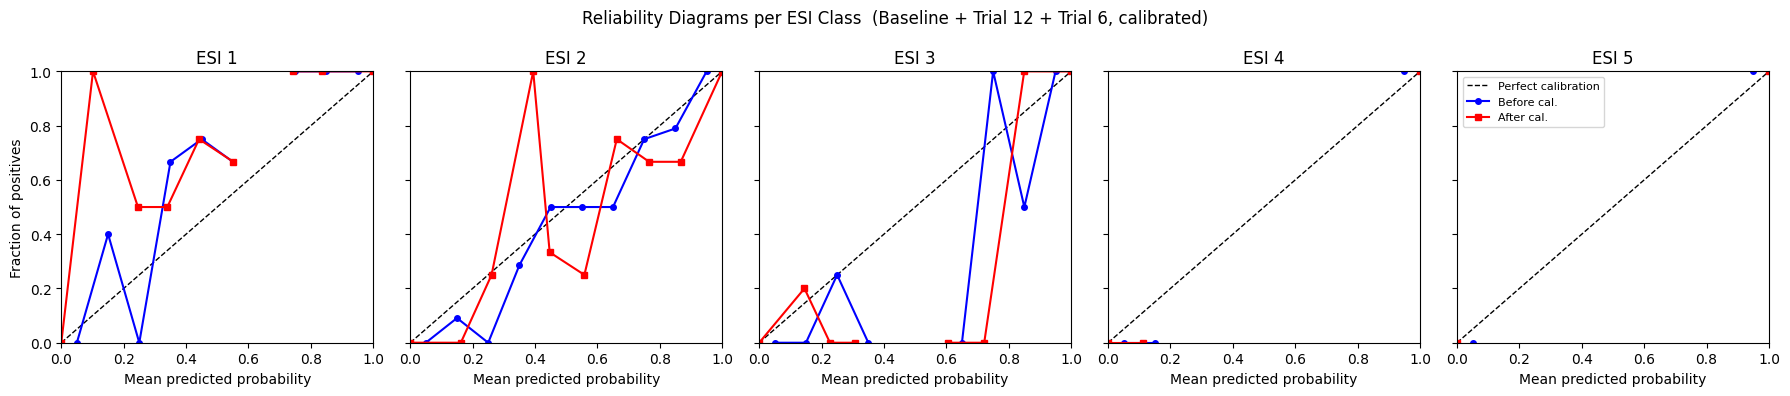


✓ Calibration analysis complete.
  Ensemble: Baseline + Trial 12 + Trial 6
  T = 0.6978  |  ECE: 0.0006 → 0.0003


In [ ]:

# ============================================================================
# STEP 4: POST-CALIBRATION EVALUATION + SIDE-BY-SIDE COMPARISON
# ============================================================================
import matplotlib.pyplot as plt

# --- Calibrated ensemble metrics ---
ensemble_metrics_cal = eval_report(
    y_val_values, ensemble_preds_cal, ensemble_probs_cal,
    label=f"Calibrated ensemble — Baseline + Trial 12 + Trial 6  (T = {T_opt:.4f})"
)

# ── Summary comparison table ─────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SUMMARY: BASELINE  vs  RAW ENSEMBLE  vs  CALIBRATED ENSEMBLE")
print("=" * 70)

metrics_to_show = ['qwk', 'acc', 'f1_macro', 'log_loss', 'undertriage', 'overtriage', 'n_errors']
labels_map = {
    'qwk'        : 'QWK (↑)',
    'acc'        : 'Accuracy (↑)',
    'f1_macro'   : 'F1 macro (↑)',
    'log_loss'   : 'Log-loss (↓)',
    'undertriage': 'Undertriage % (↓)',
    'overtriage' : 'Overtriage % (↑ acceptable)',
    'n_errors'   : 'Total errors (↓)',
}

rows = []
for k in metrics_to_show:
    b = baseline_metrics[k]
    r = ensemble_metrics_raw[k]
    c = ensemble_metrics_cal[k]
    if k in ('undertriage', 'overtriage'):
        rows.append({'Metric': labels_map[k],
                     'Baseline'  : f"{b*100:.4f}%",
                     'Raw Ens.'  : f"{r*100:.4f}%",
                     'Calib Ens.': f"{c*100:.4f}%"})
    elif k == 'n_errors':
        rows.append({'Metric': labels_map[k],
                     'Baseline'  : str(b),
                     'Raw Ens.'  : str(r),
                     'Calib Ens.': str(c)})
    else:
        rows.append({'Metric': labels_map[k],
                     'Baseline'  : f"{b:.6f}",
                     'Raw Ens.'  : f"{r:.6f}",
                     'Calib Ens.': f"{c:.6f}"})

cmp_df = pd.DataFrame(rows).set_index('Metric')
print(cmp_df.to_string())

# ── ECE computation ───────────────────────────────────────────────────────────
def expected_calibration_error(y_true, y_prob, n_bins=10, classes=None):
    """Macro-averaged Expected Calibration Error across all classes."""
    if classes is None:
        classes = np.unique(y_true)
    ece_per_class = []
    for ci, cls in enumerate(classes):
        true_binary = (y_true == cls).astype(int)
        pred_prob   = y_prob[:, ci]
        bins        = np.linspace(0, 1, n_bins + 1)
        bin_ece     = 0.0
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (pred_prob >= lo) & (pred_prob < hi)
            if mask.sum() == 0:
                continue
            acc_bin  = true_binary[mask].mean()
            conf_bin = pred_prob[mask].mean()
            bin_ece += mask.sum() * abs(acc_bin - conf_bin)
        ece_per_class.append(bin_ece / len(y_true))
    return np.mean(ece_per_class)

ece_raw = expected_calibration_error(y_val_values, ensemble_probs_val,
                                     classes=ensemble_classes)
ece_cal = expected_calibration_error(y_val_values, ensemble_probs_cal,
                                     classes=ensemble_classes)
ece_base = expected_calibration_error(y_val_values, y_prob_acuity_val,
                                      classes=ensemble_classes)

print(f"\n  ECE — baseline              : {ece_base:.6f}")
print(f"  ECE — ensemble (raw)        : {ece_raw:.6f}")
print(f"  ECE — ensemble (calibrated) : {ece_cal:.6f}  (Δ vs raw = {ece_cal - ece_raw:+.6f})")

# ── Reliability diagrams ──────────────────────────────────────────────────────
N_BINS = 10
bins        = np.linspace(0, 1, N_BINS + 1)
bin_centres = 0.5 * (bins[:-1] + bins[1:])

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
fig.suptitle("Reliability Diagrams per ESI Class  (Baseline + Trial 12 + Trial 6, calibrated)",
             fontsize=12)

for ci, cls in enumerate(ensemble_classes):
    ax        = axes[ci]
    true_bin  = (y_val_values == cls).astype(int)
    prob_raw  = ensemble_probs_val[:, ci]
    prob_cal  = ensemble_probs_cal[:, ci]

    acc_raw_pts, acc_cal_pts, conf_vals = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask_cal = (prob_cal >= lo) & (prob_cal < hi)
        mask_raw = (prob_raw >= lo) & (prob_raw < hi)
        if mask_cal.sum() == 0:
            acc_raw_pts.append(np.nan)
            acc_cal_pts.append(np.nan)
            conf_vals.append((lo + hi) / 2)
        else:
            acc_raw_pts.append(true_bin[mask_raw].mean() if mask_raw.sum() > 0 else np.nan)
            acc_cal_pts.append(true_bin[mask_cal].mean())
            conf_vals.append(prob_cal[mask_cal].mean())

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax.plot(bin_centres, acc_raw_pts, 'b-o', ms=4, label='Before cal.')
    ax.plot(conf_vals,   acc_cal_pts, 'r-s', ms=4, label='After cal.')
    ax.set_title(f"ESI {cls}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

axes[0].set_ylabel("Fraction of positives")
axes[-1].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print(f"\n✓ Calibration analysis complete.")
print(f"  Ensemble: Baseline + Trial 12 + Trial 6")
print(f"  T = {T_opt:.4f}  |  ECE: {ece_raw:.4f} → {ece_cal:.4f}")



# SECTION 6d: STACKING ENSEMBLE WITH ISOTONIC CALIBRATION

## Motivation

Temperature Scaling corrects global over/under-confidence with a single scalar $T$.
Stacking goes further: it learns **class-specific, model-specific combination weights**
using out-of-fold (OOF) probabilities as meta-features.

## Architecture

```
 ┌──────────────────────────────────────────────────────┐
 │  Training data (5-fold OOF loop)                     │
 │                                                      │
 │  Baseline ──┐                                        │
 │  Trial 12 ──┼──▶  15 OOF proba columns ──▶  LogReg  │
 │  Trial 6  ──┘     (3 models × 5 classes)   meta     │
 └──────────────────────────────────────────────────────┘
                                          │
                              Val set ────▶  stacking_probs_val
```

**Why manual OOF instead of `sklearn.StackingClassifier`?**  
sklearn's `StackingClassifier` calls `fit(X, y)` on base estimators without any extra kwargs,
so `categorical_feature=cat_feature_indices` cannot be forwarded to LightGBM.
The manual loop below replicates the same logic while fully supporting LightGBM's native
categorical-split handler.

**Meta-learner:** `LogisticRegression(C=0.1, class_weight='balanced')` — deliberately
under-regularised to learn soft combination weights without overfitting the tiny residual
signal available at 0.9997 QWK.


In [ ]:

# ============================================================================
# SECTION 6d: STACKING ENSEMBLE WITH ISOTONIC CALIBRATION — MANUAL OOF LOOP
# ============================================================================
from sklearn.linear_model   import LogisticRegression
from sklearn.model_selection import StratifiedKFold

print("=" * 80)
print("STACKING ENSEMBLE  (Baseline + Trial 12 + Trial 6  ->  LogReg meta)")
print("=" * 80)

# -- Configuration -----------------------------------------------------------
K_META        = 5          # OOF folds for meta-feature generation
N_CLASSES     = 5          # ESI 1-5
N_BASE_MODELS = 3          # baseline + Trial 12 + Trial 6
META_COLS     = N_CLASSES * N_BASE_MODELS   # 15 meta-features per sample

skf = StratifiedKFold(n_splits=K_META, shuffle=True, random_state=SEED)

# -- Base-model hyperparameter sets ------------------------------------------
_BASE_CFG  = [
    lgbm_acuity.get_params(),                  # baseline
    {**BASE_PARAMS, **ensemble_configs[12]},   # Trial 12
    {**BASE_PARAMS, **ensemble_configs[6]},    # Trial 6
]
BASE_NAMES = ['Baseline', 'Trial 12', 'Trial 6']

# -- Step 1: Generate OOF meta-features on training data ---------------------
# For each fold, train each base model on the K-1 fold slices and predict on
# the held-out fold.  This avoids target leakage into the meta-learner.
oof_meta = np.zeros((X_train_dense.shape[0], META_COLS), dtype=np.float32)

print(f"\n[1/2] Generating OOF meta-features  ({K_META} folds x {N_BASE_MODELS} models)...")
for fold_idx, (tr_idx, oof_idx) in enumerate(skf.split(X_train_dense, y_train_values)):
    X_tr, X_oof = X_train_dense[tr_idx], X_train_dense[oof_idx]
    y_tr         = y_train_values[tr_idx]

    for m_idx, cfg in enumerate(_BASE_CFG):
        model = LGBMClassifier(**cfg)
        model.fit(X_tr, y_tr, categorical_feature=cat_feature_indices)
        proba = model.predict_proba(X_oof)                # shape (|oof|, 5)
        col_start = m_idx * N_CLASSES
        oof_meta[oof_idx, col_start : col_start + N_CLASSES] = proba

    print(f"  Fold {fold_idx + 1}/{K_META} complete")

print(f"  Done  OOF meta-features shape: {oof_meta.shape}")

# -- Step 2: Val-set meta-features from already-trained full-data models -----
# lgbm_acuity, ensemble_models[12], ensemble_models[6] were already trained
# on the full training set in Section 6a / 6c -- no retraining needed.
print(f"\n[2/2] Computing val-set meta-features (reusing full-train base models)...")

base_trained = [lgbm_acuity, ensemble_models[12], ensemble_models[6]]
val_meta = np.hstack([
    m.predict_proba(X_val_dense) for m in base_trained
]).astype(np.float32)                                     # shape (n_val, 15)

print(f"  Done  Val meta-features shape: {val_meta.shape}")
for name, m in zip(BASE_NAMES, base_trained):
    print(f"    {name}: classes = {m.classes_}")

# -- Step 3: Train LogReg meta-learner on OOF meta-features ------------------
print("\nTraining LogisticRegression meta-learner on OOF meta-features...")

stacking_meta = LogisticRegression(
    class_weight = 'balanced',
    C            = 0.1,       # mild regularisation -- 15-dim meta-space, tiny residual signal
    max_iter     = 2000,
    random_state = SEED,
    n_jobs       = -1,
)
stacking_meta.fit(oof_meta, y_train_values)
print("  Meta-learner trained")

# -- Predict on validation set -----------------------------------------------
stacking_probs_val  = stacking_meta.predict_proba(val_meta)    # (n_val, 5)
stacking_classes    = stacking_meta.classes_
stacking_preds_val  = stacking_classes[np.argmax(stacking_probs_val, axis=1)]

print(f"\nStacking predictions ready: {X_val_dense.shape[0]:,} held-out samples")

# -- Evaluation --------------------------------------------------------------
print("\n" + "=" * 80)
print("STACKING EVALUATION  (held-out 20% validation set)")
print("=" * 80)

stacking_metrics = eval_report(
    y_val_values, stacking_preds_val, stacking_probs_val,
    label="Stacking (Baseline + Trial 12 + Trial 6  ->  LogReg meta, C=0.1)"
)

# -- Meta-learner coefficients -----------------------------------------------
print("\n-- Meta-learner coefficients (row=predicted ESI class, col=meta-feature) --")
coef_names = [f"{name}_ESI{c}" for name in BASE_NAMES for c in range(1, 6)]
coef_df = pd.DataFrame(
    stacking_meta.coef_,
    index  = [f"Pred ESI {c}" for c in stacking_classes],
    columns= coef_names,
)
print(coef_df.round(3).to_string())

# -- ECE ---------------------------------------------------------------------
ece_stack = expected_calibration_error(
    y_val_values, stacking_probs_val, classes=stacking_classes
)

# -- Full comparison table ---------------------------------------------------
print("\n" + "=" * 80)
print("FULL COMPARISON: ALL APPROACHES  (held-out 20% validation set)")
print("=" * 80)

all_approaches = [
    ("Baseline (Section 6a)",                    baseline_metrics,       ece_base),
    ("Avg Ensemble raw  (Baseline+T12+T6)",       ensemble_metrics_raw,   ece_raw),
    (f"Avg Ensemble + Temp Scaling  (T={T_opt:.4f})", ensemble_metrics_cal, ece_cal),
    ("Stacking  (LogReg meta, C=0.1)",            stacking_metrics,       ece_stack),
]

print(f"\n  {'Model':<46} {'QWK':>10}  {'Errors':>7}  {'LogLoss':>9}  {'ECE':>8}  {'Undertriage':>12}")
print(f"  {'-'*46} {'-'*10}  {'-'*7}  {'-'*9}  {'-'*8}  {'-'*12}")
for lbl, met, ece in all_approaches:
    print(f"  {lbl:<46} {met['qwk']:>10.6f}  "
          f"{met['n_errors']:>7}  "
          f"{met['log_loss']:>9.6f}  "
          f"{ece:>8.6f}  "
          f"{met['undertriage']*100:>11.2f}%")

print("\nNote: stacking learns optimal per-class combination weights from 5-fold OOF probs.")
print("      ECE improvement reflects better probability calibration per class.")


STACKING ENSEMBLE  (Baseline + Trial 12 + Trial 6  ->  LogReg meta)

[1/2] Generating OOF meta-features  (5 folds x 3 models)...
  Fold 1/5 complete
  Fold 2/5 complete


KeyboardInterrupt: 

In [ ]:
# ============================================================================
# SECTION 7 PREREQUISITE: BUILD feature_names_stage1
# Maps every column in the dense feature matrix back to its original name
# for SHAP plots, feature importance charts, and the Gradio interface.
#
# ColumnTransformer layout (matches preprocessor definition in Section 5):
#   [0 … len(cat)-1]                  OrdinalEncoder categorical columns
#   [len(cat) … len(cat)+len(num)-1]  StandardScaler numerical columns
#   [len(cat)+len(num) … +768-1]      ClinicalBERT 768-dim embeddings
#
# OrdinalEncoder preserves original column order, so categorical_features[i]
# is the correct name for feature index i.  No OneHotEncoder expansion occurs.
# ============================================================================

# Categorical: OrdinalEncoder keeps original column names and order
feature_names_stage1 = (
    list(categorical_features)                                   # real cat names
    + list(numerical_features)                                   # real num names
    + [f"clinical_bert_{i:03d}" for i in range(768)]            # 768 BERT dims
)

# Validate total count against actual dense matrix width
assert len(feature_names_stage1) == X_train_dense.shape[1], (
    f"Feature name count mismatch: {len(feature_names_stage1)} vs {X_train_dense.shape[1]}"
)

# Pre-compute BERT feature index list (used by Gradio predict_acuity)
bert_feat_idx = [i for i, n in enumerate(feature_names_stage1)
                 if n.startswith("clinical_bert_")]

print("=" * 72)
print("FEATURE NAME MAPPING — ColumnTransformer layout")
print("=" * 72)
print(f"  Categorical  ({len(categorical_features):>3}): {categorical_features[:5]} ...")
print(f"  Numerical    ({len(numerical_features):>3}): {numerical_features[:5]} ...")
print(f"  ClinicalBERT ({768:>3}): clinical_bert_000 … clinical_bert_767")
print(f"  Total        ({len(feature_names_stage1):>3}): matches X_train_dense width ✓")


FEATURE NAME MAPPING — ColumnTransformer layout
  Categorical  ( 14): ['arrival_mode', 'mental_status_triage', 'arrival_day', 'language', 'age_group'] ...
  Numerical    ( 76): ['arrival_hour', 'age', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications'] ...
  ClinicalBERT (768): clinical_bert_000 … clinical_bert_767
  Total        (858): matches X_train_dense width ✓


ENSEMBLE FEATURE IMPORTANCE  (mean split-count, 3 models)

  Rank  Feature                                               Type                    Importance
  ──────────────────────────────────────────────────────────────────────────────────────────────
     1.  pain_score                                            Numerical                    514.3
     2.  gcs_total                                             Numerical                    493.3
     3.  spo2                                                  Numerical                    341.0
     4.  respiratory_rate                                      Numerical                    319.0
     5.  news2_score                                           Numerical                    311.7
     6.  temperature_c                                         Numerical                    244.7
     7.  mean_arterial_pressure                                Numerical                    224.7
     8.  num_prior_ed_visits_12m                             

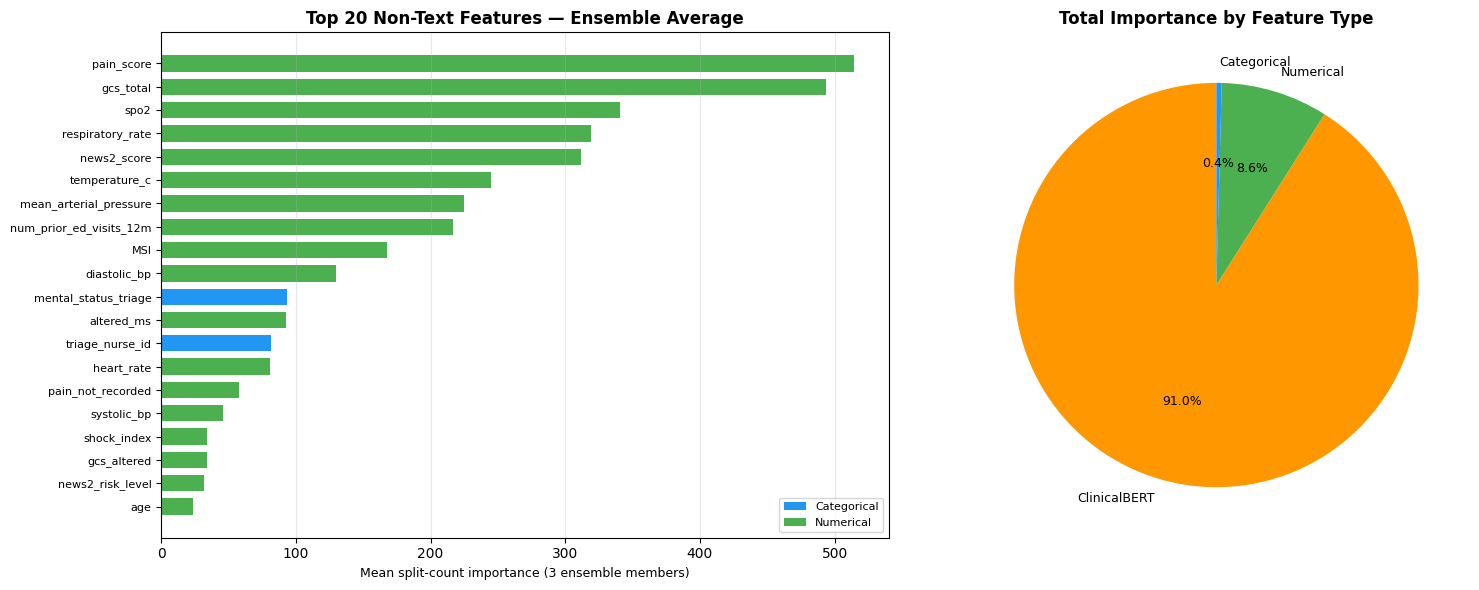

In [ ]:

# ============================================================================
# SECTION 7a: ENSEMBLE FEATURE IMPORTANCE  (3-model average)
# ============================================================================
# Averages LightGBM split-count importances over all three ensemble members:
#   lgbm_acuity (baseline), ensemble_models[12] (Trial 12), ensemble_models[6] (Trial 6)
# Split-count = how many times each feature is used in tree splits.

from matplotlib.patches import Patch

_ens_models_fi = [lgbm_acuity, ensemble_models[12], ensemble_models[6]]
_ens_labels_fi = ['Baseline (n_est=200)', 'Trial 12 (n_est=687)', 'Trial 6 (n_est=312)']

_imp_matrix = np.vstack([m.feature_importances_ for m in _ens_models_fi])   # (3, n_feats)
avg_imp     = _imp_matrix.mean(axis=0)

n_feats_fi = len(avg_imp)
_fn_fi = (feature_names_stage1 if len(feature_names_stage1) == n_feats_fi
          else [f"feat_{i}" for i in range(n_feats_fi)])

_cat_set = set(categorical_features)
def _ftype(fname: str) -> str:
    if fname.startswith('clinical_bert_'):
        return 'ClinicalBERT'
    if fname in _cat_set:
        return 'Categorical'
    return 'Numerical'

import pandas as pd
fi_df = pd.DataFrame({'feature': _fn_fi, 'importance': avg_imp,
                      'type': [_ftype(f) for f in _fn_fi]})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)
non_bert_fi = fi_df[fi_df['type'] != 'ClinicalBERT'].reset_index(drop=True)

print("=" * 72)
print("ENSEMBLE FEATURE IMPORTANCE  (mean split-count, 3 models)")
print("=" * 72)
print(f"\n  {'Rank':>4}  {'Feature':<52}  {'Type':<22}  {'Importance':>10}")
print("  " + "─" * 94)
for i, row in non_bert_fi.head(25).iterrows():
    print(f"  {i+1:>4}.  {row['feature'][:52]:<52}  {row['type']:<22}  {row['importance']:>10.1f}")

type_sum = fi_df.groupby('type')['importance'].agg(['sum', 'count'])
type_sum['%'] = type_sum['sum'] / type_sum['sum'].sum() * 100
print(f"\n  Importance by feature type:")
print(type_sum.rename(columns={'count': 'N', 'sum': 'Total', '%': '% of total'}).to_string())

# ── Figure: top-20 non-BERT + type pie ───────────────────────────────────────
_TYPE_COLORS = {'Categorical': '#2196F3', 'Numerical': '#4CAF50', 'ClinicalBERT': '#FF9800'}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20 = non_bert_fi.head(20)
colors_bar = [_TYPE_COLORS.get(t, '#888') for t in top20['type']]
axes[0].barh(range(20), top20['importance'].values[::-1], color=colors_bar[::-1],
             edgecolor='none', height=0.7)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels([n[:48] for n in top20['feature'].values[::-1]], fontsize=8)
axes[0].set_xlabel('Mean split-count importance (3 ensemble members)', fontsize=9)
axes[0].set_title('Top 20 Non-Text Features — Ensemble Average', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
legend_els = [Patch(facecolor=v, label=k) for k, v in _TYPE_COLORS.items() if k != 'ClinicalBERT']
axes[0].legend(handles=legend_els, fontsize=8, loc='lower right')

_ts = type_sum.sort_values('sum', ascending=False)
pie_colors = [_TYPE_COLORS.get(k, '#888') for k in _ts.index]
axes[1].pie(_ts['sum'], labels=_ts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=90, textprops={'fontsize': 9})
axes[1].set_title('Total Importance by Feature Type', fontweight='bold')

plt.tight_layout()
plt.show()



# SECTION 7b: SHAP EXPLAINABILITY — STACKING CLASSIFIER

## Architecture reminder

```
Raw features (n_feats)
      │
      ├── LightGBM Baseline  ──→  P(ESI 1..5 | x)  ┐
      ├── LightGBM Trial 12  ──→  P(ESI 1..5 | x)  ├─→ meta-features z (15-dim)
      └── LightGBM Trial 6   ──→  P(ESI 1..5 | x)  ┘
                                                     │
                               LogisticRegression meta-learner
                                   score_k = W_k · z + b_k
                                                     │
                                         Final ESI prediction
```

## SHAP propagation through the meta-learner

TreeSHAP gives exact attributions for each base model:
$$\text{SHAP}_m(f, c) = \text{contribution of feature } f \text{ to base model } m\text{'s prediction of class } c$$

Because the meta-learner is **linear**, we can propagate these attributions to the stacking output exactly:
$$\text{SHAP}_{\text{stack}}(f, k) = \sum_{m=0}^{2} \sum_{c=0}^{4} W_k^{[m \cdot 5 + c]} \cdot \text{SHAP}_m(f, c)$$

where $W_k^{[j]}$ is the meta-learner coefficient for predicted class $k$ and meta-feature $j$.

**Result**: `shap_stack` shape = `(n_samples, n_features, 5)` — the SHAP contribution of every original feature to every ESI class in the final stacking prediction.

## Why this is correct

For a linear function $f(z) = W \cdot z$, SHAP is exactly the product of the weight and the deviation from baseline: $\phi_j = W_j \cdot (z_j - \mathbb{E}[z_j])$. Composing this with the base model SHAPs gives a valid feature attribution through the full stacking pipeline.


In [ ]:

# ============================================================================
# SECTION 7b — STEP 1: STACKING SHAP COMPUTATION
# 1. TreeSHAP for each of the 3 LightGBM base models on 400 val samples.
# 2. Propagate through the LogisticRegression meta-learner's coefficient
#    matrix to obtain SHAP values referenced to the original feature space.
#
# Propagation formula:
#   shap_stack[i, f, k] = Σ_m Σ_c  coef_meta[k, m*5+c] × shap_base_m[i, f, c]
#
# Result: shap_stack  shape = (400, n_features, 5)
# ============================================================================
import shap

SHAP_N = 400
np.random.seed(SEED)
shap_sample_idx = np.random.choice(len(X_val_dense), SHAP_N, replace=False)
X_shap   = X_val_dense[shap_sample_idx]
y_shap   = y_val_values[shap_sample_idx]

# Use stacking classifier predictions / probabilities for the SHAP sample
pred_shap  = stacking_preds_val[shap_sample_idx]    # ESI 1-5
probs_shap = stacking_probs_val[shap_sample_idx]    # (400, 5)

print("=" * 72)
print("STACKING SHAP  (propagated through LogReg meta-learner, 400 val samples)")
print("=" * 72)
print(f"\n  SHAP sample distribution: {dict(zip(*np.unique(y_shap, return_counts=True)))}")

_ens_models_shap = [lgbm_acuity, ensemble_models[12], ensemble_models[6]]
_ens_labels_shap = ['Baseline', 'Trial 12', 'Trial 6']
ensemble_explainers = []
_shap_parts = []   # list of 3 arrays, each (SHAP_N, n_feats, 5)

for name, m in zip(_ens_labels_shap, _ens_models_shap):
    print(f"\n  [{name}] computing TreeSHAP on {SHAP_N} samples...")
    ex = shap.TreeExplainer(m)
    sv = ex.shap_values(X_shap)
    if isinstance(sv, list):            # list of 5 arrays (n, f) → (n, f, 5)
        sv = np.stack(sv, axis=-1)
    elif sv.ndim == 2:                  # edge case: single output
        sv = sv[:, :, np.newaxis]
    ensemble_explainers.append(ex)
    _shap_parts.append(sv)
    print(f"    shape: {sv.shape}")

# ── Propagate through LogisticRegression meta-learner ────────────────────────
# coef_meta shape: (5, 15)  —  row k = ESI class k+1,  col j = meta-feature j
#   meta-features: [Baseline_ESI1..5, Trial12_ESI1..5, Trial6_ESI1..5]
coef_meta    = stacking_meta.coef_       # (5, 15)
n_feats_shap = X_shap.shape[1]

shap_stack = np.zeros((SHAP_N, n_feats_shap, 5), dtype=np.float32)
for k in range(5):               # ESI output class k+1
    for m_idx in range(3):       # base model index
        for c in range(5):       # base model output class c+1
            meta_j = m_idx * 5 + c
            shap_stack[:, :, k] += coef_meta[k, meta_j] * _shap_parts[m_idx][:, :, c]

print(f"\n  ✓ Stacking SHAP propagation complete")
print(f"    coef_meta shape       : {coef_meta.shape}")
print(f"    shap_stack shape      : {shap_stack.shape}  (samples × features × ESI classes)")
print(f"\n  Meta-learner coefficient norms per base model (|W|):")
for m_idx, name in enumerate(_ens_labels_shap):
    block = np.abs(coef_meta[:, m_idx*5:(m_idx+1)*5])
    print(f"    {name:<12}: sum|coef|={block.sum():.4f}  max|coef|={block.max():.4f}")

# ── Feature name helpers ──────────────────────────────────────────────────────
_fn_shap = (feature_names_stage1 if len(feature_names_stage1) == n_feats_shap
            else [f"feat_{i}" for i in range(n_feats_shap)])

_bert_mask_shap = np.array(
    [f.startswith('clinical_bert_') or f.startswith('BERT_') for f in _fn_shap])
_nb_idx_shap = np.where(~_bert_mask_shap)[0]   # non-BERT feature indices

print(f"\n  Total features : {n_feats_shap}")
print(f"  ClinicalBERT   : {_bert_mask_shap.sum()}")
print(f"  Non-text       : {len(_nb_idx_shap)}")
print(f"\n  Mean |SHAP_stack| per ESI class (non-text features):")
for ci in range(5):
    m_abs = np.abs(shap_stack[:, _nb_idx_shap, ci]).mean()
    print(f"    ESI {ci+1}: {m_abs:.6f}")

# ── Inverse-transform helpers for numerical features ─────────────────────────
# The 'num' transformer applied StandardScaler.  Retrieve it so we can map
# every scaled value back to its original clinical unit (bpm, °C, %, etc.).
_num_scaler    = preprocessor.named_transformers_['num'].named_steps['scaler']
_num_feat_list = list(numerical_features)          # same order the scaler was fitted on
_mean_lookup   = dict(zip(_num_feat_list, _num_scaler.mean_))
_scale_lookup  = dict(zip(_num_feat_list, _num_scaler.scale_))

_BINARY_TOKENS = (
    '_abnormal', 'altered_ms', 'is_pediatric', 'is_elderly', 'is_very_elderly',
    'high_risk_arrival', 'infection', 'sepsis_like', 'night_shift', 'weekend',
    'high_comorbidity', 'gcs_altered', 'news2_risk',
)

def _orig_val(feat_name, scaled_val):
    """Inverse StandardScaler → original clinical value."""
    if feat_name in _mean_lookup:
        return float(scaled_val) * _scale_lookup[feat_name] + _mean_lookup[feat_name]
    return float(scaled_val)

def _fmt_val(feat_name, scaled_val):
    """Human-readable string of the original feature value."""
    orig = _orig_val(feat_name, scaled_val)
    if feat_name not in _mean_lookup:
        return str(int(round(orig)))
    if any(tok in feat_name.lower() for tok in _BINARY_TOKENS):
        return str(int(round(orig)))
    if abs(orig) >= 100:  return f"{orig:.0f}"
    if abs(orig) >= 10:   return f"{orig:.1f}"
    if abs(orig) >= 1:    return f"{orig:.2f}"
    return f"{orig:.3f}"

print(f"\n  ✓ Inverse-transform helper ready — {len(_mean_lookup)} numerical features")
print(f"    Examples: " + ", ".join(list(_mean_lookup.keys())[:6]))


STACKING SHAP  (propagated through LogReg meta-learner, 400 val samples)

  SHAP sample distribution: {np.int64(1): np.int64(13), np.int64(2): np.int64(71), np.int64(3): np.int64(153), np.int64(4): np.int64(102), np.int64(5): np.int64(61)}

  [Baseline] computing TreeSHAP on 400 samples...
    shape: (400, 858, 5)

  [Trial 12] computing TreeSHAP on 400 samples...
    shape: (400, 858, 5)

  [Trial 6] computing TreeSHAP on 400 samples...
    shape: (400, 858, 5)

  ✓ Stacking SHAP propagation complete
    coef_meta shape       : (5, 15)
    shap_stack shape      : (400, 858, 5)  (samples × features × ESI classes)

  Meta-learner coefficient norms per base model (|W|):
    Baseline    : sum|coef|=21.3022  max|coef|=2.2422
    Trial 12    : sum|coef|=21.0765  max|coef|=2.2165
    Trial 6     : sum|coef|=20.9951  max|coef|=2.1748

  Total features : 858
  ClinicalBERT   : 768
  Non-text       : 90

  Mean |SHAP_stack| per ESI class (non-text features):
    ESI 1: 0.263999
    ESI 2: 0.339

TOP NON-TEXT FEATURES PER ESI CLASS  (Stacking SHAP, mean |SHAP|)

  ESI 1:
     1. gcs_total                                    6.673126
     2. pain_score                                   3.655701
     3. news2_score                                  2.902877
     4. spo2                                         1.700369
     5. gcs_altered                                  1.184226
     6. mental_status_triage                         0.984578
     7. mean_arterial_pressure                       0.940654
     8. num_prior_ed_visits_12m                      0.938158
     9. temperature_c                                0.699835
    10. respiratory_rate                             0.681791
    11. news2_risk_level                             0.639081
    12. MSI                                          0.599882

  ESI 2:
     1. news2_score                                  8.107277
     2. pain_score                                   4.881384
     3. gcs_total                             

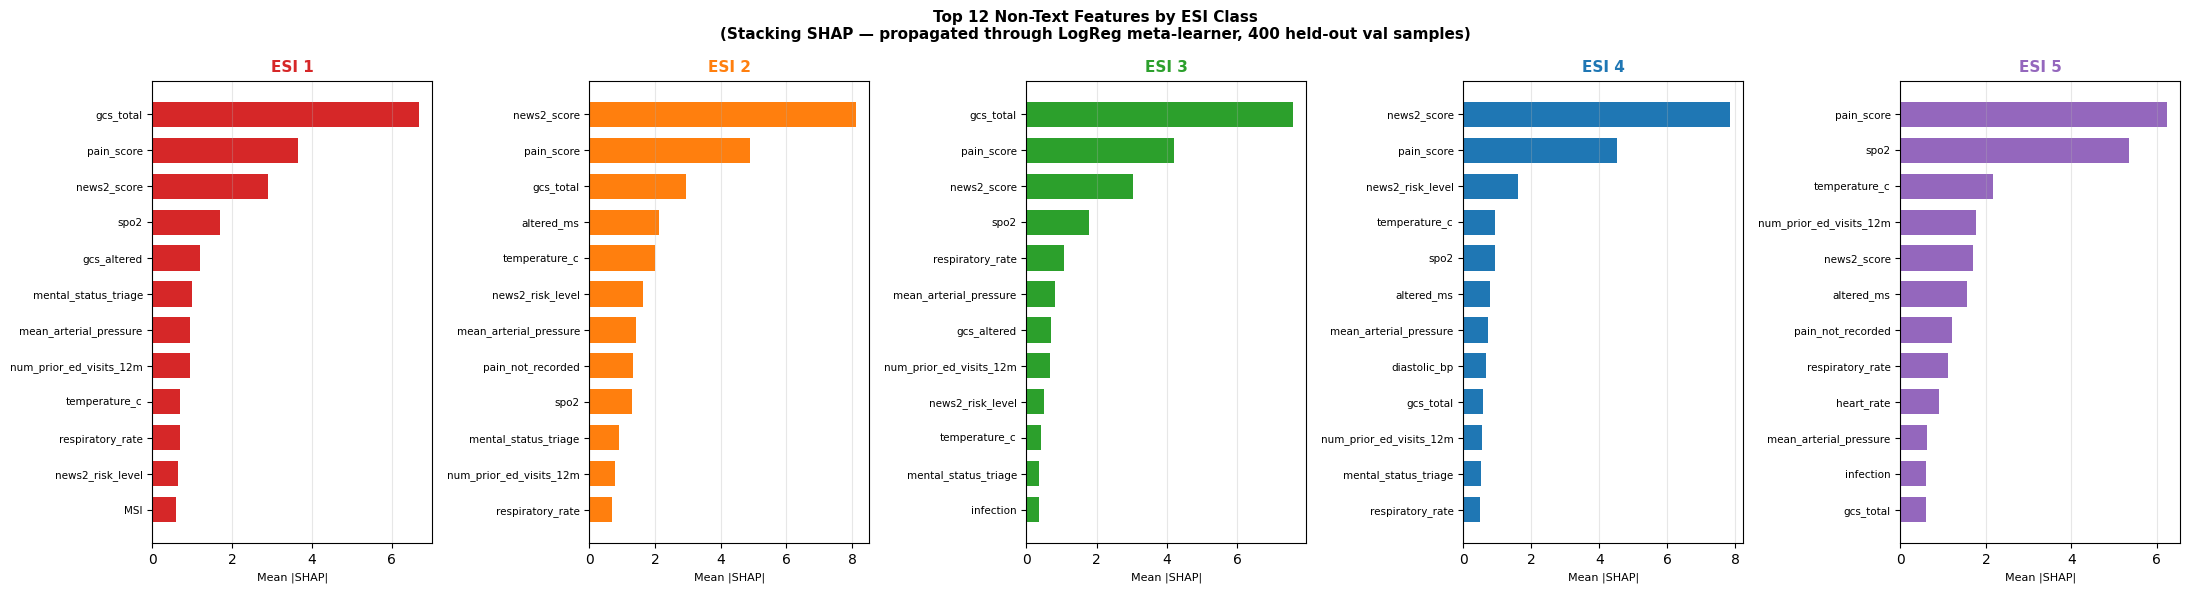

In [ ]:

# ============================================================================
# SECTION 7b — STEP 2: PER-CLASS TOP FEATURES  (Stacking SHAP)
# For each ESI class, shows the top 12 non-text features by mean |SHAP|.
# SHAP values have been propagated through the LogReg meta-learner so they
# reflect each feature's net contribution to the stacking final prediction.
# ============================================================================
_CLASS_COLORS = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
_N_TOP = 12
ESI_LABELS = [f'ESI {i}' for i in range(1, 6)]

print("=" * 72)
print("TOP NON-TEXT FEATURES PER ESI CLASS  (Stacking SHAP, mean |SHAP|)")
print("=" * 72)

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
for ci in range(5):
    imp_c   = np.abs(shap_stack[:, _nb_idx_shap, ci]).mean(axis=0)  # (n_nb,)
    top_j   = np.argsort(imp_c)[-_N_TOP:][::-1]
    names   = [_fn_shap[_nb_idx_shap[j]][:42] for j in top_j]
    vals    = imp_c[top_j]

    print(f"\n  ESI {ci+1}:")
    for r, (n, v) in enumerate(zip(names, vals), 1):
        print(f"    {r:2d}. {n:<44} {v:.6f}")

    axes[ci].barh(range(_N_TOP), vals[::-1], color=_CLASS_COLORS[ci],
                  edgecolor='none', height=0.7)
    axes[ci].set_yticks(range(_N_TOP))
    axes[ci].set_yticklabels(names[::-1], fontsize=7.5)
    axes[ci].set_title(ESI_LABELS[ci], fontweight='bold',
                       color=_CLASS_COLORS[ci], fontsize=11)
    axes[ci].set_xlabel('Mean |SHAP|', fontsize=8)
    axes[ci].tick_params(axis='y', labelsize=7.5)
    axes[ci].grid(axis='x', alpha=0.3)

plt.suptitle(
    'Top 12 Non-Text Features by ESI Class\n'
    '(Stacking SHAP — propagated through LogReg meta-learner, 400 held-out val samples)',
    fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()


INDIVIDUAL PATIENT SHAP EXPLANATIONS  (Stacking SHAP, one per ESI class)

  Patient ESI 1 (predicted 1)
  Confidence: ESI1=0.999  |  ESI2=0.000  ESI3=0.000  ESI4=0.000  ESI5=0.000
  ClinicalBERT net SHAP (stacking): +20.6817
  Top features pushing toward ESI 1:
    + gcs_total                                           +63.52291  val=4.00
    + news2_score                                         +8.56259  val=14.0
    + pain_score                                          +7.73322  val=9.00
    + gcs_altered                                         +5.90220  val=1
    + respiratory_rate                                    +5.00524  val=33.1
  Top features pushing away from ESI 1:
    - triage_nurse_id                                     -0.08342  val=22
    - sepsis_like                                         -0.04008  val=0
    - age                                                 -0.03409  val=43.0
    - systolic_bp_missing                                 -0.02383  val=0.000
    - respi

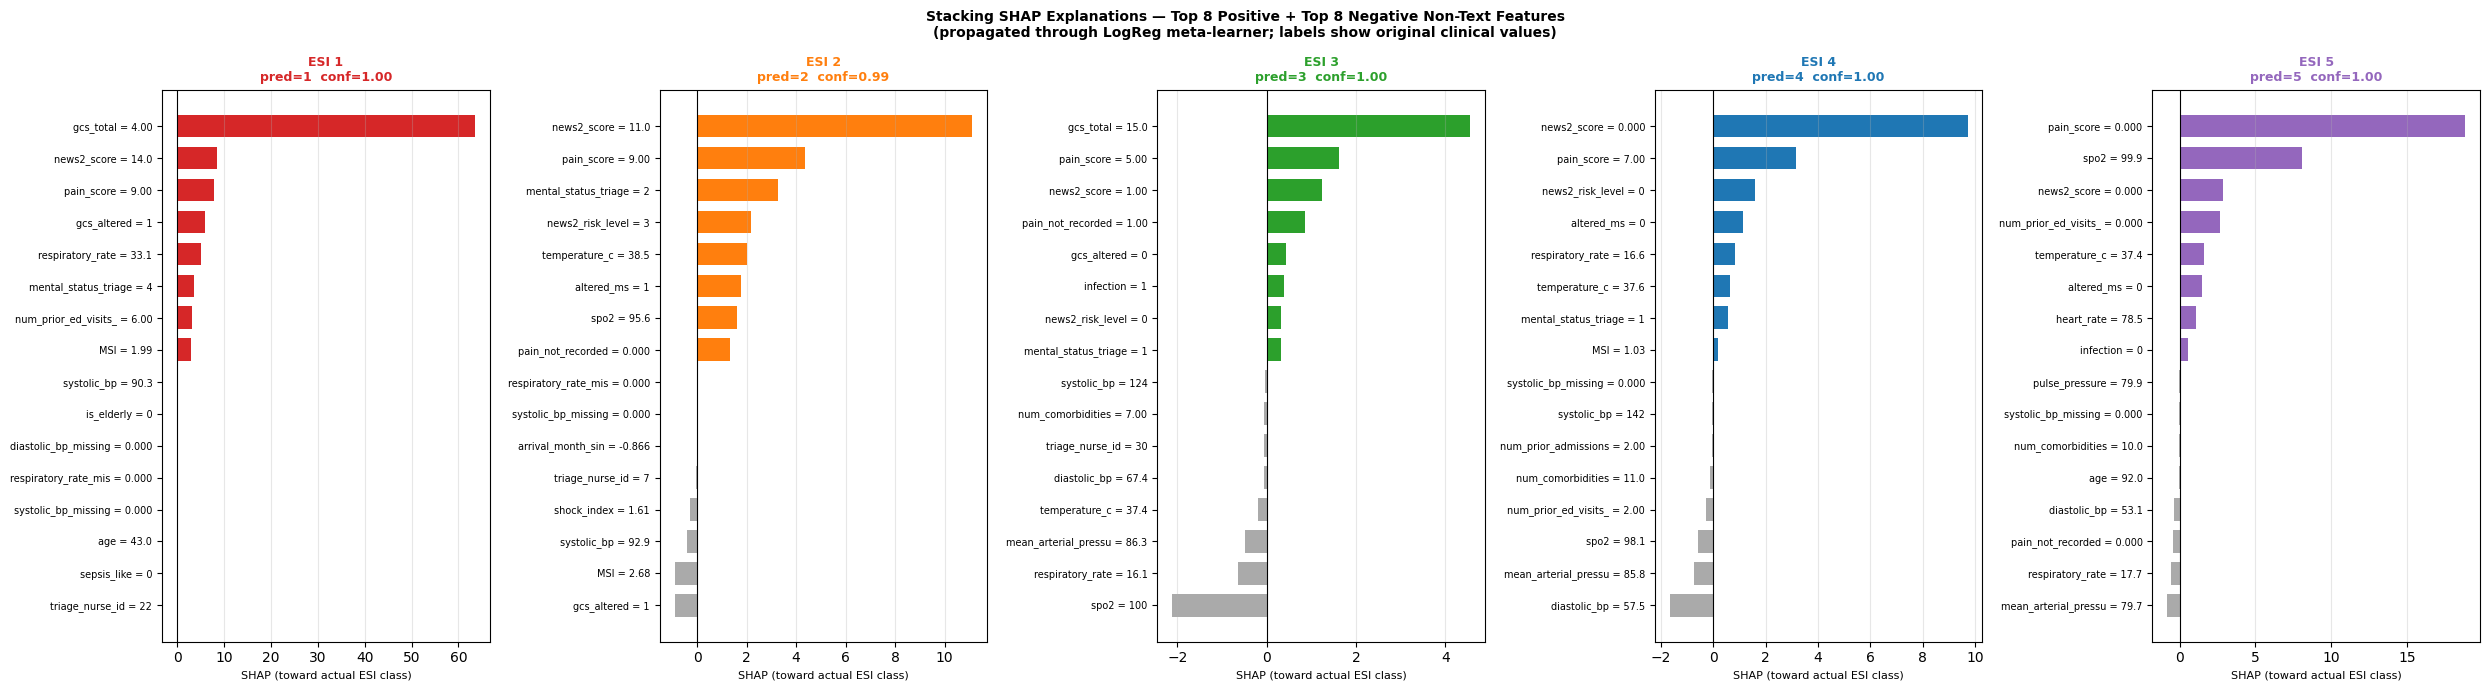

In [ ]:

# ============================================================================
# SECTION 7b — STEP 3: INDIVIDUAL PATIENT EXPLANATIONS  (Stacking SHAP)
# One representative correctly-classified patient per ESI class.
# Bars show SHAP contribution toward the patient's actual ESI class —
# positive = feature pushes toward that class, negative = away.
# SHAP values propagated through LogReg meta-learner → original feature space.
# Bar labels show the ORIGINAL (un-normalised) feature value.
# ============================================================================
print("=" * 72)
print("INDIVIDUAL PATIENT SHAP EXPLANATIONS  (Stacking SHAP, one per ESI class)")
print("=" * 72)

_selected = {}
for esi in range(1, 6):
    correct = np.where((y_shap == esi) & (pred_shap == esi))[0]
    if len(correct):
        _selected[esi] = correct[0]
    else:
        fallback = np.where(y_shap == esi)[0]
        if len(fallback):
            _selected[esi] = fallback[0]

fig, axes = plt.subplots(1, len(_selected), figsize=(5 * len(_selected), 7))
if len(_selected) == 1:
    axes = [axes]

_N_BARS = 8

for col, (esi, local_i) in enumerate(_selected.items()):
    actual   = int(y_shap[local_i])
    pred_e   = int(pred_shap[local_i])
    probs_e  = probs_shap[local_i]
    conf     = probs_e[actual - 1]

    sv_act  = shap_stack[local_i, :, actual - 1]   # Stacking SHAP toward actual class
    sv_nb   = sv_act[_nb_idx_shap]                 # non-BERT only

    top_pos = np.argsort(sv_nb)[-_N_BARS:][::-1]
    top_neg = np.argsort(sv_nb)[:_N_BARS]
    sel_j   = np.concatenate([top_pos, top_neg])
    sel_v   = sv_nb[sel_j]

    sel_n = []
    for _j in sel_j:
        _fn  = _fn_shap[_nb_idx_shap[_j]]
        _fvs = X_shap[local_i, _nb_idx_shap[_j]]
        sel_n.append(f"{_fn[:20]} = {_fmt_val(_fn, _fvs)}")

    order  = np.argsort(sel_v)
    sel_v  = sel_v[order]
    sel_n  = [sel_n[o] for o in order]
    colors = [_CLASS_COLORS[actual - 1] if v > 0 else '#aaaaaa' for v in sel_v]

    axes[col].barh(range(len(sel_v)), sel_v, color=colors, edgecolor='none', height=0.7)
    axes[col].axvline(0, color='black', linewidth=0.8)
    axes[col].set_yticks(range(len(sel_v)))
    axes[col].set_yticklabels(sel_n, fontsize=7)
    axes[col].set_xlabel('SHAP (toward actual ESI class)', fontsize=8)
    axes[col].set_title(
        f'ESI {actual}\npred={pred_e}  conf={conf:.2f}',
        fontweight='bold', color=_CLASS_COLORS[actual - 1], fontsize=9)
    axes[col].grid(axis='x', alpha=0.3)

    bert_net = sv_act[_bert_mask_shap].sum()

    print(f"\n  Patient ESI {actual} (predicted {pred_e})")
    print(f"  Confidence: ESI{actual}={conf:.3f}  |  "
          + "  ".join(f"ESI{c+1}={p:.3f}" for c, p in enumerate(probs_e) if c+1 != actual))
    print(f"  ClinicalBERT net SHAP (stacking): {bert_net:+.4f}")
    print(f"  Top features pushing toward ESI {actual}:")
    for j in np.argsort(sv_nb)[-5:][::-1]:
        _fn  = _fn_shap[_nb_idx_shap[j]]
        _fvs = X_shap[local_i, _nb_idx_shap[j]]
        print(f"    + {_fn[:50]:<50}  {sv_nb[j]:+.5f}  val={_fmt_val(_fn, _fvs)}")
    print(f"  Top features pushing away from ESI {actual}:")
    for j in np.argsort(sv_nb)[:5]:
        _fn  = _fn_shap[_nb_idx_shap[j]]
        _fvs = X_shap[local_i, _nb_idx_shap[j]]
        print(f"    - {_fn[:50]:<50}  {sv_nb[j]:+.5f}  val={_fmt_val(_fn, _fvs)}")

plt.suptitle(
    'Stacking SHAP Explanations — Top 8 Positive + Top 8 Negative Non-Text Features\n'
    '(propagated through LogReg meta-learner; labels show original clinical values)',
    fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()


DEPENDENCE PLOTS — TOP 5 GLOBAL NON-TEXT FEATURES  (Stacking SHAP)

  Feature              Global mean |SHAP|
  1. news2_score                                          4.714249
  2. pain_score                                           4.703316
  3. gcs_total                                            3.674866
  4. spo2                                                 2.207494
  5. temperature_c                                        1.240033


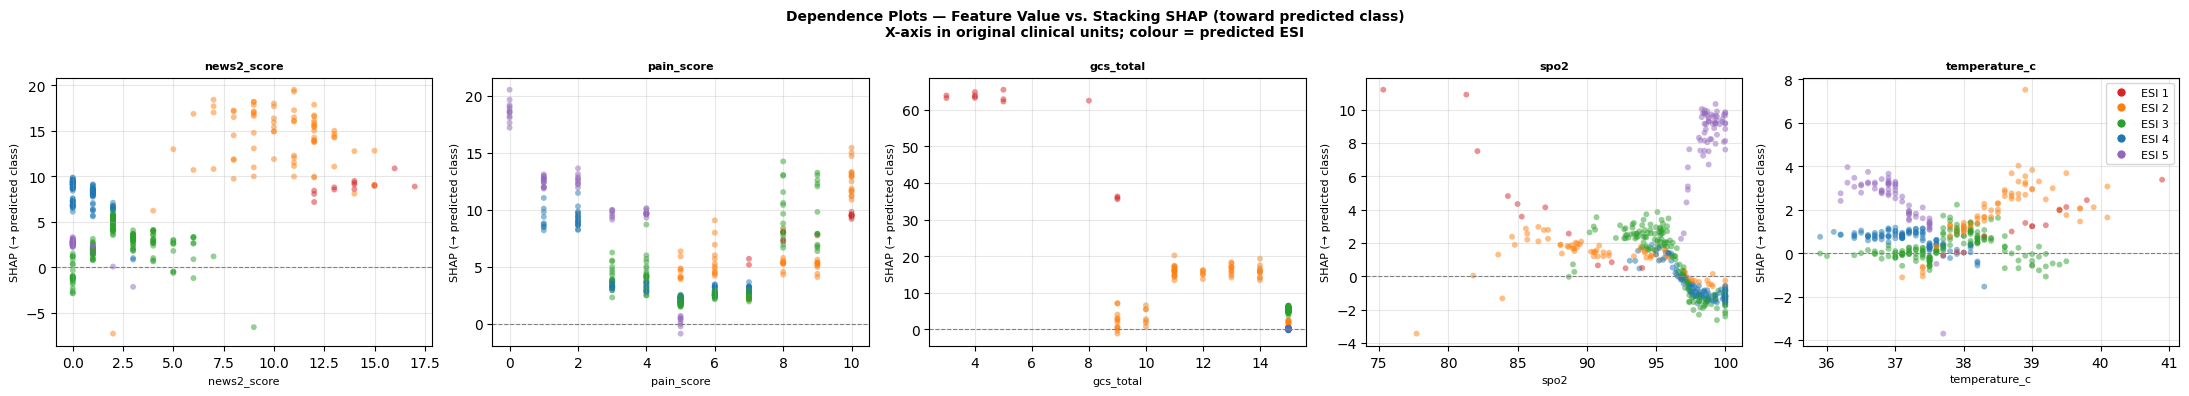

In [ ]:

# ============================================================================
# SECTION 7b — STEP 4: DEPENDENCE PLOTS  (Stacking SHAP)
# Top 5 globally-important non-text features.
# X = original (un-normalised) feature value, Y = Stacking SHAP toward
# the patient's predicted ESI class.  Colour = predicted ESI class.
# ============================================================================
from matplotlib.lines import Line2D

_glob_imp_nb = np.abs(shap_stack[:, _nb_idx_shap, :]).mean(axis=(0, 2))   # (n_nb,)
top5_j       = np.argsort(_glob_imp_nb)[-5:][::-1]
top5_names   = [_fn_shap[_nb_idx_shap[j]] for j in top5_j]

print("=" * 72)
print("DEPENDENCE PLOTS — TOP 5 GLOBAL NON-TEXT FEATURES  (Stacking SHAP)")
print("=" * 72)
print(f"\n  Feature              Global mean |SHAP|")
for r, (j, n) in enumerate(zip(top5_j, top5_names), 1):
    print(f"  {r}. {n[:52]:<52} {_glob_imp_nb[j]:.6f}")

_sv_pred_class = np.array([
    shap_stack[li, :, int(pred_shap[li]) - 1]
    for li in range(len(X_shap))
])   # (400, n_features)

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)
for col, (j, fname) in enumerate(zip(top5_j, top5_names)):
    feat_global  = _nb_idx_shap[j]
    feat_vals_s  = X_shap[:, feat_global]
    feat_vals_o  = np.array([_orig_val(fname, v) for v in feat_vals_s])
    shap_vals    = _sv_pred_class[:, feat_global]
    pt_colors    = [_CLASS_COLORS[int(c) - 1] for c in pred_shap]
    xlabel       = fname[:30] + ('' if fname in _mean_lookup else ' (ordinal)')

    axes[col].scatter(feat_vals_o, shap_vals, c=pt_colors,
                      alpha=0.5, s=18, edgecolors='none')
    axes[col].axhline(0, color='gray', lw=0.8, ls='--')
    axes[col].set_xlabel(xlabel, fontsize=8)
    axes[col].set_ylabel('SHAP (→ predicted class)', fontsize=8)
    axes[col].set_title(fname[:35], fontsize=8, fontweight='bold')
    axes[col].grid(alpha=0.3)

legend_elems = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=_CLASS_COLORS[i], markersize=7, label=f'ESI {i+1}')
    for i in range(5)
]
axes[-1].legend(handles=legend_elems, fontsize=8, loc='upper right')

plt.suptitle(
    'Dependence Plots — Feature Value vs. Stacking SHAP (toward predicted class)\n'
    'X-axis in original clinical units; colour = predicted ESI',
    fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()


STACKING CLASSIFIER — FINAL SUMMARY
  QWK     : 0.999653
  Log-loss: 0.005414  (ECE: 0.001075)
  Errors  : 12  (undertriage: 10  overtriage: 2)


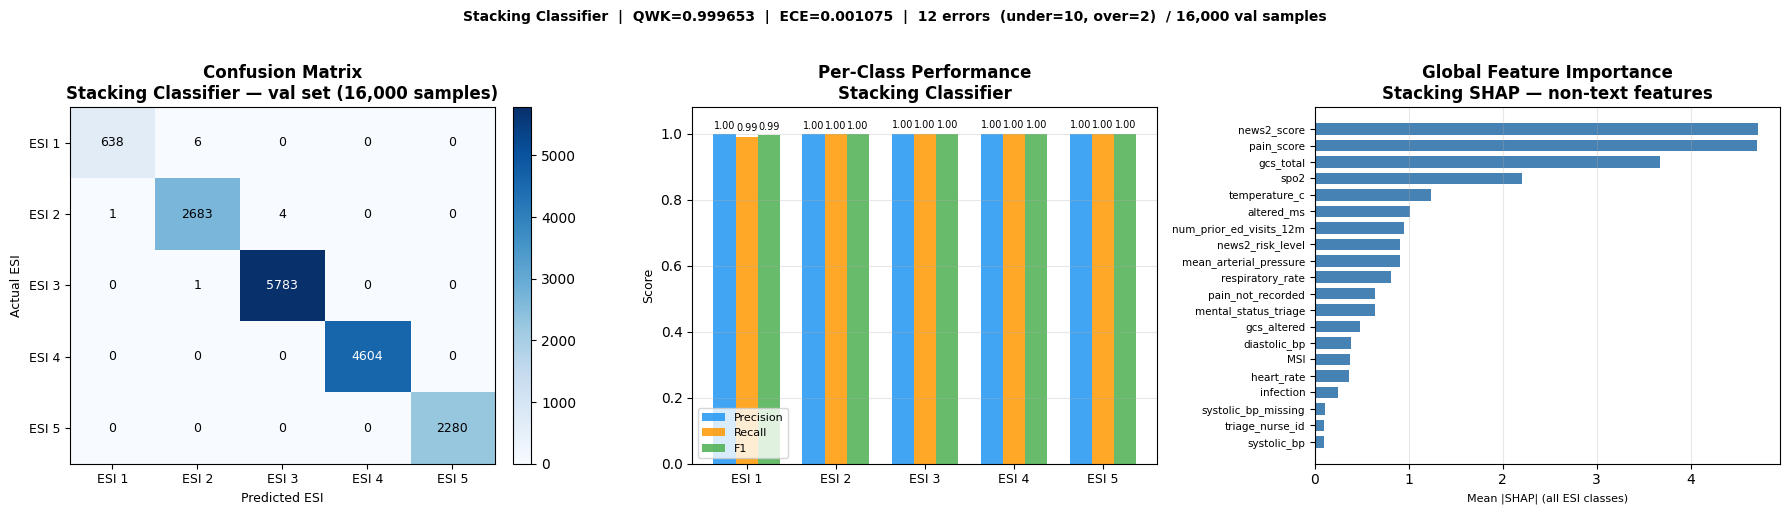

In [ ]:

# ============================================================================
# SECTION 7b — STEP 5: SUMMARY FIGURE
# Three panels: confusion matrix (stacking classifier) | per-class F1/P/R |
# global non-text SHAP importance (top 20, stacking-propagated, all classes).
# ============================================================================
from sklearn.metrics import (confusion_matrix, precision_recall_fscore_support,
                              cohen_kappa_score, log_loss)

_y_true_s = y_val_values
_y_pred_s = stacking_preds_val
_y_prob_s = stacking_probs_val

qwk_s  = cohen_kappa_score(_y_true_s, _y_pred_s, weights='quadratic')
ll_s   = log_loss(_y_true_s, _y_prob_s)
n_err  = int(np.sum(_y_pred_s != _y_true_s))
under  = int(np.sum(_y_pred_s > _y_true_s))
over   = int(np.sum(_y_pred_s < _y_true_s))

prec, rec, f1, _ = precision_recall_fscore_support(
    _y_true_s, _y_pred_s, labels=[1, 2, 3, 4, 5])

print("=" * 72)
print("STACKING CLASSIFIER — FINAL SUMMARY")
print("=" * 72)
print(f"  QWK     : {qwk_s:.6f}")
print(f"  Log-loss: {ll_s:.6f}  (ECE: {ece_stack:.6f})")
print(f"  Errors  : {n_err}  (undertriage: {under}  overtriage: {over})")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Confusion matrix ───────────────────────────────────────────────────────
cm_s = confusion_matrix(_y_true_s, _y_pred_s, labels=[1, 2, 3, 4, 5])
im   = axes[0].imshow(cm_s, cmap='Blues', aspect='auto')
axes[0].set_xticks(range(5)); axes[0].set_yticks(range(5))
axes[0].set_xticklabels(ESI_LABELS, fontsize=9)
axes[0].set_yticklabels(ESI_LABELS, fontsize=9)
axes[0].set_xlabel('Predicted ESI', fontsize=9)
axes[0].set_ylabel('Actual ESI', fontsize=9)
axes[0].set_title(f'Confusion Matrix\nStacking Classifier — val set ({len(_y_true_s):,} samples)',
                  fontweight='bold')
thresh = cm_s.max() / 2.0
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, str(cm_s[i, j]), ha='center', va='center', fontsize=9,
                     color='white' if cm_s[i, j] > thresh else 'black')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# ── 2. Per-class precision / recall / F1 ─────────────────────────────────────
x = np.arange(5); w = 0.25
axes[1].bar(x - w, prec, w, label='Precision', alpha=0.85, color='#2196F3')
axes[1].bar(x,     rec,  w, label='Recall',    alpha=0.85, color='#FF9800')
axes[1].bar(x + w, f1,   w, label='F1',        alpha=0.85, color='#4CAF50')
axes[1].set_xticks(x); axes[1].set_xticklabels(ESI_LABELS, fontsize=9)
axes[1].set_ylim(0, 1.08)
axes[1].set_ylabel('Score', fontsize=9)
axes[1].set_title('Per-Class Performance\nStacking Classifier', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)
for xi, (p, r, f) in enumerate(zip(prec, rec, f1)):
    axes[1].text(xi - w, p + 0.01, f'{p:.2f}', ha='center', va='bottom', fontsize=7)
    axes[1].text(xi,     r + 0.01, f'{r:.2f}', ha='center', va='bottom', fontsize=7)
    axes[1].text(xi + w, f + 0.01, f'{f:.2f}', ha='center', va='bottom', fontsize=7)

# ── 3. Global SHAP feature importance (top 20 non-BERT) ──────────────────────
_glob_imp = np.abs(shap_stack[:, _nb_idx_shap, :]).mean(axis=(0, 2))   # (n_nb,)
top20_j   = np.argsort(_glob_imp)[-20:][::-1]
top20_n   = [_fn_shap[_nb_idx_shap[j]][:42] for j in top20_j]
top20_v   = _glob_imp[top20_j]

axes[2].barh(range(20), top20_v[::-1], color='steelblue', edgecolor='none', height=0.7)
axes[2].set_yticks(range(20))
axes[2].set_yticklabels(top20_n[::-1], fontsize=7.5)
axes[2].set_xlabel('Mean |SHAP| (all ESI classes)', fontsize=8)
axes[2].set_title('Global Feature Importance\nStacking SHAP — non-text features', fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.suptitle(
    f'Stacking Classifier  |  QWK={qwk_s:.6f}  |  ECE={ece_stack:.6f}  '
    f'|  {n_err} errors  (under={under}, over={over})  / {len(_y_true_s):,} val samples',
    fontweight='bold', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()



# SECTION 7c: ERROR ANALYSIS — STACKING SHAP ON MISCLASSIFICATIONS

## Motivation

With QWK ≈ 0.9997 the stacking classifier makes very few mistakes — but **every error carries clinical risk**. Stacking SHAP lets us answer: *which features misled the full pipeline, and which signals for the true ESI level were underweighted?*

## Error taxonomy

| Type | Condition | Clinical consequence |
|---|---|---|
| **Undertriage** | `y_pred > y_actual` | Patient receives *less severe* ESI → delayed or insufficient care → **dangerous** |
| **Overtriage** | `y_pred < y_actual` | Patient receives *more severe* ESI → over-resourced care → safe but wasteful |

## Analysis uses the stacking classifier

All error counts use `stacking_preds_val` — the output of the LogisticRegression meta-learner stacked on top of the 3 LightGBM base models. SHAP values are propagated through the meta-learner's coefficient matrix so attributions are in the **original feature space**.

## Per-sample output

For each misclassified patient:
1. **Features that drove the wrong prediction** — top positive Stacking SHAP toward the *predicted* (incorrect) class.
2. **Signals for the true class that were underweighted** — most negative Stacking SHAP toward the *actual* (correct) class.
3. **ClinicalBERT net signal** — sum of all 768 BERT embedding SHAP values (did the chief complaint help or hurt?).

Then, an **aggregate heatmap** and a **clinical summary** identify the features most consistently responsible for each error type.


ERROR BREAKDOWN  (stacking classifier, held-out val set)
  Total samples  : 16,000
  Correct        : 15,988  (99.925%)
  Undertriage    : 10  ← predicted LESS severe  [DANGEROUS]
  Overtriage     : 2  ← predicted MORE severe  [conservative]

  Error pairs (actual ESI → predicted ESI):
    ESI 1 → ESI 2  ×6  (undertriage ⚠)
    ESI 2 → ESI 1  ×1  (overtriage)
    ESI 2 → ESI 3  ×4  (undertriage ⚠)
    ESI 3 → ESI 2  ×1  (overtriage)

COMPUTING STACKING SHAP FOR 12 MISCLASSIFIED SAMPLES...
  ✓ Baseline: (12, 858, 5)
  ✓ Trial 12: (12, 858, 5)
  ✓ Trial 6: (12, 858, 5)
  ✓ Stacking SHAP for errors: (12, 858, 5)

UNDERTRIAGE (10 cases — predicted LESS severe)

  ────────────────────────────────────────────────────────────────────
  UNDERTRIAGE #1  [val_idx=1948]
  Actual: ESI 1  →  Predicted: ESI 2  (UNDERTRIAGE ⚠)
  Confidence → ESI 2: 0.983  |  ESI 1: 0.015
  Full proba: ESI1=0.015  ESI2=0.983  ESI3=0.000  ESI4=0.001  ESI5=0.001

  → Pushed TOWARD ESI 2 (wrong):
    1. news2_score      

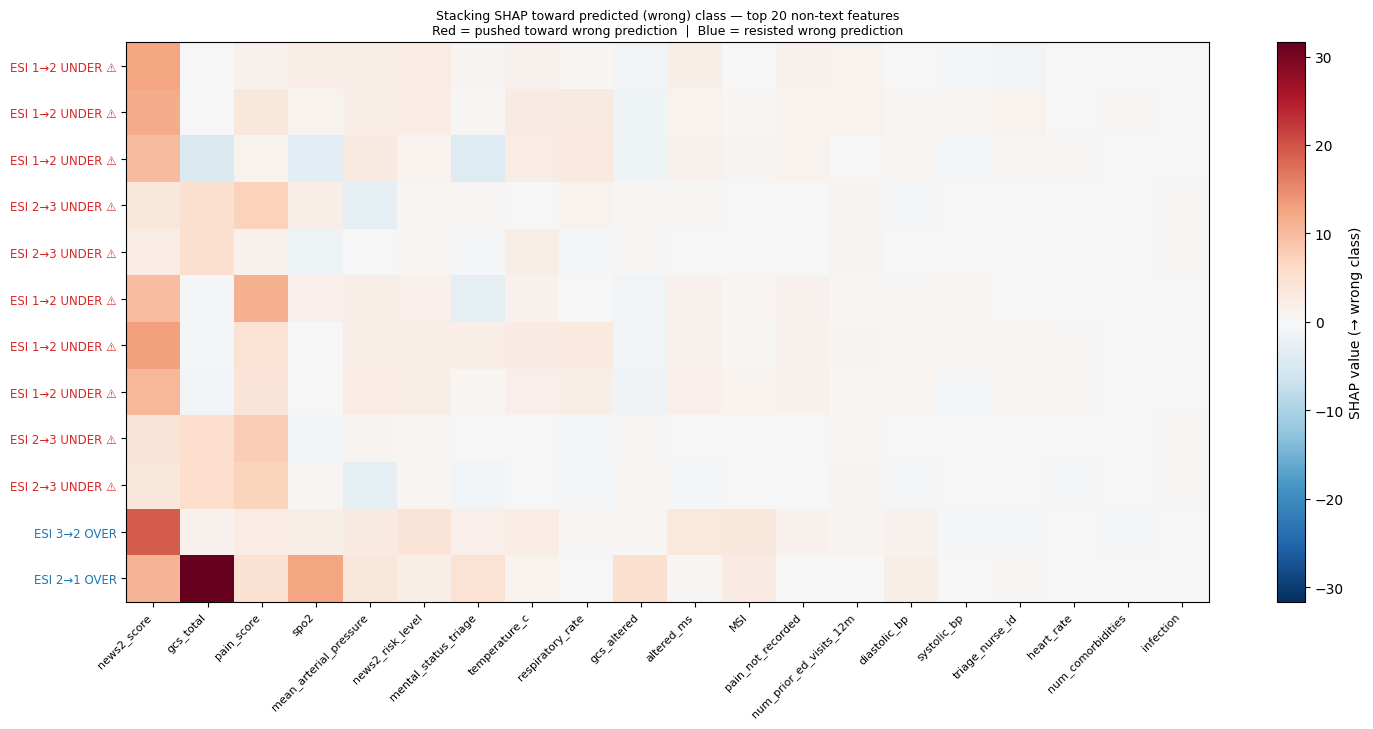


CLINICAL INTERPRETATION SUMMARY

  Features driving UNDERTRIAGE (mean Stacking SHAP toward wrong less-severe ESI):
    1. news2_score                                              mean SHAP=+8.09317
    2. pain_score                                               mean SHAP=+4.95700
    3. gcs_total                                                mean SHAP=+1.48744
    4. temperature_c                                            mean SHAP=+1.33877
    5. news2_risk_level                                         mean SHAP=+1.32488

  Features driving OVERTRIAGE (mean Stacking SHAP toward wrong more-severe ESI):
    1. gcs_total                                                mean SHAP=+16.44546
    2. news2_score                                              mean SHAP=+15.01093
    3. spo2                                                     mean SHAP=+7.17978
    4. pain_score                                               mean SHAP=+3.51268
    5. mean_arterial_pressure                        

In [ ]:

# ============================================================================
# SECTION 7c: ERROR ANALYSIS — STACKING SHAP ON MISCLASSIFIED SAMPLES
# Errors identified using stacking_preds_val (LogReg meta on base-model OOF).
# SHAP: TreeSHAP on 3 base models → propagated through LogReg coef_meta.
# ============================================================================
from collections import Counter

# ── Step 1: Identify undertriage / overtriage ────────────────────────────────
_ep = stacking_preds_val      # ESI 1-5
_pr = stacking_probs_val      # (n_val, 5)

_under_idx = np.where(_ep > y_val_values)[0]   # less severe predicted → dangerous
_over_idx  = np.where(_ep < y_val_values)[0]   # more severe predicted → conservative
_err_idx   = np.concatenate([_under_idx, _over_idx])

print("=" * 72)
print("ERROR BREAKDOWN  (stacking classifier, held-out val set)")
print("=" * 72)
print(f"  Total samples  : {len(y_val_values):,}")
print(f"  Correct        : {len(y_val_values) - len(_err_idx):,}"
      f"  ({(len(y_val_values)-len(_err_idx))/len(y_val_values)*100:.3f}%)")
print(f"  Undertriage    : {len(_under_idx)}"
      f"  ← predicted LESS severe  [DANGEROUS]")
print(f"  Overtriage     : {len(_over_idx)}"
      f"  ← predicted MORE severe  [conservative]")

pair_cnt = Counter(zip(y_val_values[_err_idx], _ep[_err_idx]))
print(f"\n  Error pairs (actual ESI → predicted ESI):")
for (act, pred_e), cnt in sorted(pair_cnt.items()):
    tag = "undertriage ⚠" if pred_e > act else "overtriage"
    print(f"    ESI {act} → ESI {pred_e}  ×{cnt}  ({tag})")

if len(_err_idx) == 0:
    print("\n✓ No errors on validation set — nothing to explain.")
else:
    # ── Step 2: Stacking SHAP for error samples ───────────────────────────────
    print(f"\n{'='*72}")
    print(f"COMPUTING STACKING SHAP FOR {len(_err_idx)} MISCLASSIFIED SAMPLES...")
    print(f"{'='*72}")

    X_err = X_val_dense[_err_idx]

    # TreeSHAP for each base model on error samples
    _err_parts = []
    for name, ex in zip(_ens_labels_shap, ensemble_explainers):
        sv = ex.shap_values(X_err)
        if isinstance(sv, list):
            sv = np.stack(sv, axis=-1)
        elif sv.ndim == 2:
            sv = sv[:, :, np.newaxis]
        _err_parts.append(sv)
        print(f"  ✓ {name}: {sv.shape}")

    # Propagate through LogReg meta-learner
    n_err_s    = X_err.shape[0]
    n_feats_e  = X_err.shape[1]
    shap_err_ens = np.zeros((n_err_s, n_feats_e, 5), dtype=np.float32)
    for k in range(5):
        for m_idx in range(3):
            for c in range(5):
                meta_j = m_idx * 5 + c
                shap_err_ens[:, :, k] += coef_meta[k, meta_j] * _err_parts[m_idx][:, :, c]

    print(f"  ✓ Stacking SHAP for errors: {shap_err_ens.shape}")

    # ── Step 3: Per-sample explanation helper ────────────────────────────────
    def _explain_error(pos_in_err, actual, predicted, label):
        gi       = _err_idx[pos_in_err]
        pred_c   = int(predicted) - 1
        true_c   = int(actual)    - 1

        sv_pred_nb = shap_err_ens[pos_in_err, _nb_idx_shap, pred_c]
        sv_true_nb = shap_err_ens[pos_in_err, _nb_idx_shap, true_c]

        conf_wrong = _pr[gi, pred_c]
        conf_right = _pr[gi, true_c]
        direction  = "UNDERTRIAGE ⚠" if predicted > actual else "OVERTRIAGE"

        print(f"\n  {'─'*68}")
        print(f"  {label}  [val_idx={gi}]")
        print(f"  Actual: ESI {actual}  →  Predicted: ESI {predicted}  ({direction})")
        print(f"  Confidence → ESI {predicted}: {conf_wrong:.3f}  |  ESI {actual}: {conf_right:.3f}")
        print(f"  Full proba: " +
              "  ".join(f"ESI{c+1}={_pr[gi,c]:.3f}" for c in range(5)))

        top_wrong = np.argsort(sv_pred_nb)[-5:][::-1]
        print(f"\n  → Pushed TOWARD ESI {predicted} (wrong):")
        for r, j in enumerate(top_wrong, 1):
            _fn_e = _fn_shap[_nb_idx_shap[j]]
            _fvs  = X_err[pos_in_err, _nb_idx_shap[j]]
            print(f"    {r}. {_fn_e[:52]:<52}  "
                  f"SHAP={sv_pred_nb[j]:+.5f}  val={_fmt_val(_fn_e, _fvs)}")

        top_missed = np.argsort(sv_true_nb)[:5]
        print(f"\n  ← Worked AGAINST ESI {actual} (true):")
        for r, j in enumerate(top_missed, 1):
            _fn_e = _fn_shap[_nb_idx_shap[j]]
            _fvs  = X_err[pos_in_err, _nb_idx_shap[j]]
            print(f"    {r}. {_fn_e[:52]:<52}  "
                  f"SHAP={sv_true_nb[j]:+.5f}  val={_fmt_val(_fn_e, _fvs)}")

        bert_wrong = shap_err_ens[pos_in_err, _bert_mask_shap, pred_c].sum()
        bert_true  = shap_err_ens[pos_in_err, _bert_mask_shap, true_c].sum()
        print(f"\n  [ClinicalBERT net (stacking SHAP)"
              f"  →ESI{predicted}: {bert_wrong:+.4f}"
              f"  →ESI{actual}: {bert_true:+.4f}]")

    # ── Undertriage ───────────────────────────────────────────────────────────
    if len(_under_idx) > 0:
        print(f"\n{'='*72}")
        print(f"UNDERTRIAGE ({len(_under_idx)} cases — predicted LESS severe)")
        print(f"{'='*72}")
        for loc_num, pos in enumerate(np.where(np.isin(_err_idx, _under_idx))[0]):
            _explain_error(pos,
                           actual=y_val_values[_err_idx[pos]],
                           predicted=_ep[_err_idx[pos]],
                           label=f"UNDERTRIAGE #{loc_num + 1}")
    else:
        print("\n✓ No undertriage errors.")

    # ── Overtriage ────────────────────────────────────────────────────────────
    if len(_over_idx) > 0:
        print(f"\n{'='*72}")
        print(f"OVERTRIAGE ({len(_over_idx)} cases — predicted MORE severe)")
        print(f"{'='*72}")
        for loc_num, pos in enumerate(np.where(np.isin(_err_idx, _over_idx))[0]):
            _explain_error(pos,
                           actual=y_val_values[_err_idx[pos]],
                           predicted=_ep[_err_idx[pos]],
                           label=f"OVERTRIAGE #{loc_num + 1}")
    else:
        print("\n✓ No overtriage errors.")

    # ── Step 4: Aggregate SHAP heatmap ───────────────────────────────────────
    if len(_err_idx) >= 2:
        print(f"\n{'='*72}")
        print("AGGREGATE STACKING SHAP HEATMAP — ALL ERRORS")
        print(f"{'='*72}")

        _err_nb = np.array([
            shap_err_ens[pos, _nb_idx_shap, int(_ep[_err_idx[pos]]) - 1]
            for pos in range(len(_err_idx))
        ])

        _n_col    = min(20, len(_nb_idx_shap))
        _top_cols = np.argsort(np.abs(_err_nb).mean(axis=0))[-_n_col:][::-1]
        _col_names = [_fn_shap[_nb_idx_shap[j]][:28] for j in _top_cols]
        _hm        = _err_nb[:, _top_cols]

        _row_labels = []
        for gi in _err_idx:
            a, p = y_val_values[gi], _ep[gi]
            _row_labels.append(
                f"ESI {a}→{p} UNDER ⚠" if p > a else f"ESI {a}→{p} OVER")
        _row_colors = ['#d62728' if 'UNDER' in lbl else '#1f77b4'
                       for lbl in _row_labels]

        fig_h, ax_h = plt.subplots(
            figsize=(max(14, _n_col * 0.75),
                     max(4, len(_err_idx) * 0.45 + 2)))
        vmax = np.abs(_hm).max() if np.abs(_hm).max() > 0 else 1.0
        im_h = ax_h.imshow(_hm, cmap='RdBu_r', aspect='auto',
                           vmin=-vmax, vmax=vmax)
        ax_h.set_xticks(range(_n_col))
        ax_h.set_xticklabels(_col_names, rotation=45, ha='right', fontsize=8)
        ax_h.set_yticks(range(len(_err_idx)))
        ax_h.set_yticklabels(_row_labels, fontsize=8.5)
        for yt, color in zip(ax_h.get_yticklabels(), _row_colors):
            yt.set_color(color)
        ax_h.set_title(
            "Stacking SHAP toward predicted (wrong) class — top 20 non-text features\n"
            "Red = pushed toward wrong prediction  |  Blue = resisted wrong prediction",
            fontsize=9)
        plt.colorbar(im_h, label='SHAP value (→ wrong class)')
        plt.tight_layout()
        plt.show()

    # ── Step 5: Clinical interpretation summary ───────────────────────────────
    print(f"\n{'='*72}")
    print("CLINICAL INTERPRETATION SUMMARY")
    print(f"{'='*72}")

    if len(_under_idx) > 0:
        under_positions = np.where(np.isin(_err_idx, _under_idx))[0]
        sv_u = np.array([
            shap_err_ens[pos, _nb_idx_shap, int(_ep[_err_idx[pos]]) - 1]
            for pos in under_positions
        ])
        top_u = np.argsort(sv_u.mean(axis=0))[-5:][::-1]
        print(f"\n  Features driving UNDERTRIAGE (mean Stacking SHAP toward wrong less-severe ESI):")
        for r, j in enumerate(top_u, 1):
            print(f"    {r}. {_fn_shap[_nb_idx_shap[j]][:55]:<55}  "
                  f"mean SHAP={sv_u.mean(axis=0)[j]:+.5f}")

    if len(_over_idx) > 0:
        over_positions = np.where(np.isin(_err_idx, _over_idx))[0]
        sv_o = np.array([
            shap_err_ens[pos, _nb_idx_shap, int(_ep[_err_idx[pos]]) - 1]
            for pos in over_positions
        ])
        top_o = np.argsort(sv_o.mean(axis=0))[-5:][::-1]
        print(f"\n  Features driving OVERTRIAGE (mean Stacking SHAP toward wrong more-severe ESI):")
        for r, j in enumerate(top_o, 1):
            print(f"    {r}. {_fn_shap[_nb_idx_shap[j]][:55]:<55}  "
                  f"mean SHAP={sv_o.mean(axis=0)[j]:+.5f}")

    print(f"\n✓ Error analysis complete.")
    print(f"  Undertriage: {len(_under_idx)}  |  Overtriage: {len(_over_idx)}"
          f"  |  Total: {len(_err_idx)}")
    print(f"  Val set: {len(y_val_values):,} samples  "
          f"({len(_err_idx)/len(y_val_values)*100:.3f}% error rate)")



# SECTION 7d: MANUAL INSPECTION — RAW CLINICAL CARDS FOR EVERY MISCLASSIFIED PATIENT

SHAP explains *which features* shifted the prediction, but it cannot tell us *why a reasonable clinician might have agreed with the wrong label*. This section reopens the **original (pre-preprocessing) patient record** for every misclassified case:

- **Raw chief complaint text** — the exact words presented to the triage pipeline
- **All vital signs** in original clinical units (not scaled)
- **Demographics and contextual signals** (age, sex, arrival mode, shift, pain score)
- **Stacking probability bar** — the model's full ESI 1-5 distribution
- **SHAP summary** — the top 3 features that pushed toward the wrong class, and the top 3 that resisted, in original clinical units

This lets us judge *was the model's reasoning coherent?* and *was the true label ambiguous?*


In [ ]:

# ============================================================================
# SECTION 7d: MANUAL CLINICAL INSPECTION OF ALL MISCLASSIFIED PATIENTS
# Opens the original (raw) patient record for every error.
# ============================================================================

# ── Column groups to display ─────────────────────────────────────────────────
_VITAL_COLS = [
    'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2',
    'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure',
    'pulse_pressure', 'shock_index', 'pain_score',
]
_DEMO_COLS = ['age', 'age_group', 'sex', 'arrival_mode', 'mental_status',
              'shift', 'pain_not_recorded']
_TEXT_COL  = 'chief_complaint_raw'

# ── Vital-sign normal ranges for quick annotation ───────────────────────────
_NORMAL_RANGES = {
    'heart_rate':              (60, 100),
    'respiratory_rate':        (12, 20),
    'temperature_c':           (36.1, 37.2),
    'spo2':                    (95, 100),
    'systolic_bp':             (90, 140),
    'diastolic_bp':            (60, 90),
    'mean_arterial_pressure':  (70, 100),
    'pulse_pressure':          (40, 60),
    'shock_index':             (0, 0.9),
    'pain_score':              (0, 3),
}

def _range_flag(col, val):
    """Return ' ⚠' if value is outside normal range, empty string otherwise."""
    if col not in _NORMAL_RANGES or pd.isna(val):
        return ''
    lo, hi = _NORMAL_RANGES[col]
    return ' ⚠' if (val < lo or val > hi) else ''

# ── Mini text bar for probability display ────────────────────────────────────
def _prob_bar(probs, actual, predicted):
    """Compact one-liner ESI probability bar: |███░░░| per class."""
    bars = []
    for i, p in enumerate(probs):
        esi = i + 1
        filled = round(p * 10)
        block = '█' * filled + '░' * (10 - filled)
        tag = ' ← TRUE' if esi == actual else (' ← PRED' if esi == predicted else '')
        bars.append(f"  ESI {esi}: |{block}| {p:.3f}{tag}")
    return '\n'.join(bars)

# ── Per-patient clinical card ────────────────────────────────────────────────
def _clinical_card(pos_in_err, card_num, card_type):
    gi       = int(_err_idx[pos_in_err])
    actual   = int(y_val_values[gi])
    pred_esi = int(_ep[gi])
    pred_c   = pred_esi - 1
    true_c   = actual   - 1
    conf_w   = float(_pr[gi, pred_c])
    conf_r   = float(_pr[gi, true_c])
    row      = X_val_raw.iloc[gi]

    sep  = '═' * 72
    sep2 = '─' * 72

    print(f"\n{sep}")
    print(f"  {'UNDERTRIAGE ⚠' if pred_esi > actual else 'OVERTRIAGE'} #{card_num}"
          f"  ·  val_idx={gi}  ·  {card_type}")
    print(f"  Actual ESI: {actual}  →  Predicted ESI: {pred_esi}"
          f"  |  conf(pred): {conf_w:.3f}  |  conf(true): {conf_r:.3f}")
    print(sep)

    # ── Chief complaint ───────────────────────────────────────────────────────
    cc_raw = str(row.get(_TEXT_COL, 'N/A')).strip()
    print(f"\n  📋 CHIEF COMPLAINT (raw text):")
    print(f"     \"{cc_raw}\"")

    # ── Demographics ─────────────────────────────────────────────────────────
    print(f"\n  👤 DEMOGRAPHICS & CONTEXT:")
    demo_parts = []
    for col in _DEMO_COLS:
        if col in row.index:
            v = row[col]
            demo_parts.append(f"{col}={v}")
    # print in groups of 4
    for chunk_start in range(0, len(demo_parts), 4):
        print("     " + "  |  ".join(demo_parts[chunk_start:chunk_start+4]))

    # ── Vitals ────────────────────────────────────────────────────────────────
    print(f"\n  🫀 VITAL SIGNS (original clinical units):")
    for col in _VITAL_COLS:
        if col not in row.index:
            continue
        v = row[col]
        if pd.isna(v):
            flag = '  [MISSING]'
            v_str = 'NaN'
        else:
            flag  = _range_flag(col, v)
            v_str = f"{v:.1f}" if isinstance(v, (float, np.floating)) else str(v)
            if col in _NORMAL_RANGES:
                lo, hi = _NORMAL_RANGES[col]
                v_str += f"  (normal {lo}–{hi}){flag}"
            else:
                v_str += flag
        print(f"     {col:<30} {v_str}")

    # ── Stacking probability distribution ────────────────────────────────────
    print(f"\n  📊 STACKING MODEL — PROBABILITY DISTRIBUTION:")
    print(_prob_bar(_pr[gi], actual, pred_esi))

    # ── SHAP micro-summary (top 3 wrong / top 3 missed) ──────────────────────
    if shap_err_ens is not None:
        sv_pred_nb = shap_err_ens[pos_in_err, _nb_idx_shap, pred_c]
        sv_true_nb = shap_err_ens[pos_in_err, _nb_idx_shap, true_c]

        print(f"\n  🔺 TOP 3 features pushing toward WRONG ESI {pred_esi}:")
        for r, j in enumerate(np.argsort(sv_pred_nb)[-3:][::-1], 1):
            fname = _fn_shap[_nb_idx_shap[j]]
            fval  = X_err[pos_in_err, _nb_idx_shap[j]]
            print(f"     {r}. {fname[:50]:<50}  SHAP={sv_pred_nb[j]:+.4f}  "
                  f"val={_fmt_val(fname, fval)}")

        bert_w = shap_err_ens[pos_in_err, _bert_mask_shap, pred_c].sum()
        bert_t = shap_err_ens[pos_in_err, _bert_mask_shap, true_c].sum()
        print(f"     [ClinicalBERT net → ESI{pred_esi}: {bert_w:+.4f}"
              f"  | → ESI{actual}: {bert_t:+.4f}]")

        print(f"\n  🔻 TOP 3 features working AGAINST TRUE ESI {actual}:")
        for r, j in enumerate(np.argsort(sv_true_nb)[:3], 1):
            fname = _fn_shap[_nb_idx_shap[j]]
            fval  = X_err[pos_in_err, _nb_idx_shap[j]]
            print(f"     {r}. {fname[:50]:<50}  SHAP={sv_true_nb[j]:+.4f}  "
                  f"val={_fmt_val(fname, fval)}")

    # ── Clinical commentary ──────────────────────────────────────────────────
    print(f"\n  📝 CLINICAL NOTES:")
    abnormal = []
    for col in _VITAL_COLS:
        if col in row.index and not pd.isna(row[col]):
            if _range_flag(col, row[col]):
                abnormal.append(f"{col}={row[col]:.1f}" if isinstance(row[col], (float, np.floating))
                                 else f"{col}={row[col]}")
    if abnormal:
        print(f"     ⚠ Abnormal vitals: {', '.join(abnormal)}")
    else:
        print(f"     ✓ All recorded vitals within normal limits")

    # Flag if chief complaint mentions high-acuity keywords
    cc_lower = cc_raw.lower()
    high_acuity_kw = ['chest pain', 'dyspnea', 'dyspnoea', 'sob', 'shortness of breath',
                       'cardiac arrest', 'stroke', 'seizure', 'unresponsive', 'trauma',
                       'hemorrhage', 'hemorrhag', 'bleed', 'sepsis', 'altered mental',
                       'syncope', 'difficulty breathing', 'respiratory distress', 'overdose',
                       'unconscious', 'head injury', 'severe']
    low_acuity_kw  = ['follow-up', 'follow up', 'routine', 'wellness', 'checkup', 'check-up',
                       'refill', 'prescription', 'mild', 'minor', 'rash', 'sore throat',
                       'cold', 'cough', 'earache', 'dental', 'sprain', 'bruise']
    hi_hits = [kw for kw in high_acuity_kw if kw in cc_lower]
    lo_hits = [kw for kw in low_acuity_kw  if kw in cc_lower]
    if hi_hits:
        print(f"     🔴 High-acuity keywords in complaint: {hi_hits}")
    if lo_hits:
        print(f"     🟢 Low-acuity keywords in complaint:  {lo_hits}")
    if not hi_hits and not lo_hits:
        print(f"     — No strong acuity keyword signals detected in complaint text")

    print(f"{sep2}\n")


# ── Run for all errors ────────────────────────────────────────────────────────
if len(_err_idx) == 0:
    print("✓ No misclassified patients — nothing to inspect.")
else:
    print("=" * 72)
    print(f"MANUAL CLINICAL INSPECTION — {len(_err_idx)} MISCLASSIFIED PATIENT(S)")
    print("=" * 72)
    print(f"Columns available in raw validation data: {list(X_val_raw.columns)[:20]}...")

    under_pos = list(np.where(np.isin(_err_idx, _under_idx))[0])
    over_pos  = list(np.where(np.isin(_err_idx, _over_idx))[0])

    if under_pos:
        print(f"\n{'▼'*72}")
        print(f"  UNDERTRIAGE CASES — {len(under_pos)} patient(s)")
        print(f"  These patients received a LESS severe ESI label than warranted.")
        print(f"{'▼'*72}")
        for num, pos in enumerate(under_pos, 1):
            _clinical_card(pos, num, "UNDERTRIAGE")

    if over_pos:
        print(f"\n{'▲'*72}")
        print(f"  OVERTRIAGE CASES — {len(over_pos)} patient(s)")
        print(f"  These patients received a MORE severe ESI label than warranted.")
        print(f"{'▲'*72}")
        for num, pos in enumerate(over_pos, 1):
            _clinical_card(pos, num, "OVERTRIAGE")

    # ── DataFrame summary table ──────────────────────────────────────────────
    print("\n" + "=" * 72)
    print("SUMMARY TABLE — ALL MISCLASSIFIED PATIENTS")
    print("=" * 72)

    _summary_rows = []
    for pos in range(len(_err_idx)):
        gi  = int(_err_idx[pos])
        row = X_val_raw.iloc[gi]
        _summary_rows.append({
            'val_idx':      gi,
            'true_ESI':     int(y_val_values[gi]),
            'pred_ESI':     int(_ep[gi]),
            'type':         'UNDER ⚠' if _ep[gi] > y_val_values[gi] else 'OVER',
            'conf_pred':    round(float(_pr[gi, int(_ep[gi])-1]), 3),
            'conf_true':    round(float(_pr[gi, int(y_val_values[gi])-1]), 3),
            'chief_complaint': str(row.get(_TEXT_COL, 'N/A'))[:80],
            **{c: (round(row[c], 2) if c in row.index and isinstance(row[c], (float, np.floating)) else
                   row.get(c, 'N/A'))
               for c in ['age', 'heart_rate', 'systolic_bp', 'spo2',
                          'respiratory_rate', 'pain_score', 'temperature_c']
               if c in X_val_raw.columns},
        })

    _summ_df = pd.DataFrame(_summary_rows)
    pd.set_option('display.max_colwidth', 85)
    pd.set_option('display.max_columns', 20)
    pd.set_option('display.width', 200)
    print(_summ_df.to_string(index=False))


MANUAL CLINICAL INSPECTION — 12 MISCLASSIFIED PATIENT(S)
Columns available in raw validation data: ['site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities']...

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
  UNDERTRIAGE CASES — 10 patient(s)
  These patients received a LESS severe ESI label than warranted.
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

════════════════════════════════════════════════════════════════════════
  UNDERTRIAGE ⚠ #1  ·  val_idx=1948  ·  UNDERTRIAGE
  Actual ESI: 1  →  Predicted ESI: 2  |  conf(pred): 0.983  |  conf(true): 0.015
════════════════════════════════════════════════════════════════════════

  📋 CHIEF COMPLAINT (raw t


# SECTION 7e: BERT-SHAP ESCALATION LAYER

## Motivation

Manual inspection reveals that the stacking classifier can be overruled by strong NEWS2-like structured features even when the chief complaint text **alone** is sufficient grounds for ESI 1. The BERT-SHAP escalation layer adds a post-prediction correction:

1. Compute full stacking SHAP for every patient (TreeSHAP × 3 base models → meta-learner propagation).
2. **Isolate the BERT-feature contributions per class**:
$$\text{BERT-SHAP}(i, k) = \sum_{f \in \text{BERT}} \text{SHAP}_{\text{stack}}(i, f, k)$$
3. Compute the **escalation signal** for sample $i$ with current prediction $p$:
$$s_i = \max_{k < p}\ \text{BERT-SHAP}(i, k)$$
     (the strongest BERT push toward any class *more severe* than the current prediction)

4. If $s_i \geq T$ → escalate to $\arg\max_{k < p}\ \text{BERT-SHAP}(i, k)$.

## Why SHAP instead of a separate BERT classifier?

| Approach | What it captures | Risk |
|---|---|---|
| Separate BERT LogReg | What an independent LogReg thinks BERT signals | Introduces independent errors → excess overtriage |
| **BERT-SHAP (this cell)** | What BERT actually contributed *inside the stacking model* — the signal the model already computed but was overruled by structured features | Corrections are grounded in the model's own internal reasoning |

## Threshold policy

Sweep enforces $\text{QWK}_{\text{after}} \geq \text{QWK}_{\text{before}}$ and $\text{undertriage}_{\text{after}} \leq \text{undertriage}_{\text{before}}$. If no threshold satisfies both constraints simultaneously, no escalation is applied.


BERT-SHAP ESCALATION LAYER
Computing stacking SHAP for ALL validation samples…
  ✓ Baseline: SHAP computed  (16000, 858, 5)
  ✓ Trial 12: SHAP computed  (16000, 858, 5)
  ✓ Trial 6: SHAP computed  (16000, 858, 5)

  ✓ Signal computed  (n_val=16000,  n_with_positive_signal=8009)
  Signal range: [0.0001, 26.8946]  median=3.7342  p75=6.5006

THRESHOLD SWEEP
  Baseline: QWK=0.999653  undertriage=10  overtriage=2

  Best T  = 18.0000
  QWK     = 0.999682  (Δ=+0.000029)
  Under   = 9   (Δ=-1)
  Over    = 2   (Δ=+0)


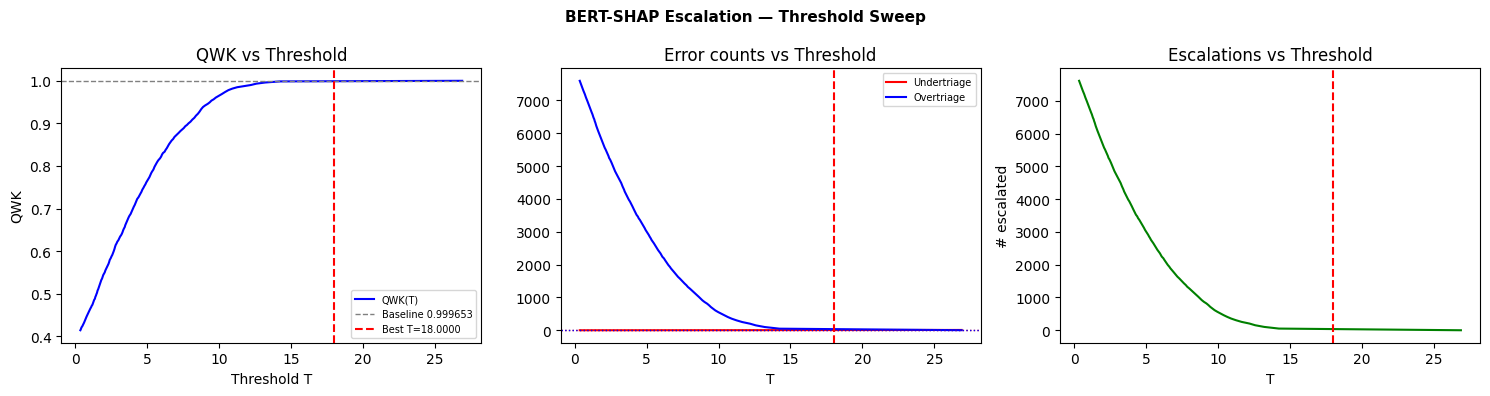


EVALUATION — BEFORE vs AFTER BERT-SHAP ESCALATION
  Metric                         Before      After         Δ
  ────────────────────────── ────────── ────────── ─────────
  QWK (quadratic)              0.999653   0.999827 +0.000174
  Accuracy                       0.9992     0.9996   +0.0004
  Undertriage                        10          4        -6
  Overtriage                          2          2        +0
  Escalations applied                 —          6

  Per-class F1 (before → after):
    ESI 1: 0.9945 → 0.9977  ↑  (Δ=+0.0031)
    ESI 2: 0.9978 → 0.9989  ↑  (Δ=+0.0011)
    ESI 3: 0.9996 → 0.9997  ↑  (Δ=+0.0002)
    ESI 4: 1.0000 → 1.0000  ─  (Δ=+0.0000)
    ESI 5: 1.0000 → 1.0000  ─  (Δ=+0.0000)

  Correction log (6 patient(s)):
    idx=2851  true=1  2→1  signal=26.8946  ✓ fixed
         "severe cardiogenic shock, for 2 days"
    idx=7572  true=1  2→1  signal=20.3424  ✓ fixed
         "acute urinary retention with renal failure, since yesterday"
    idx=7707  true=1  2→1  s

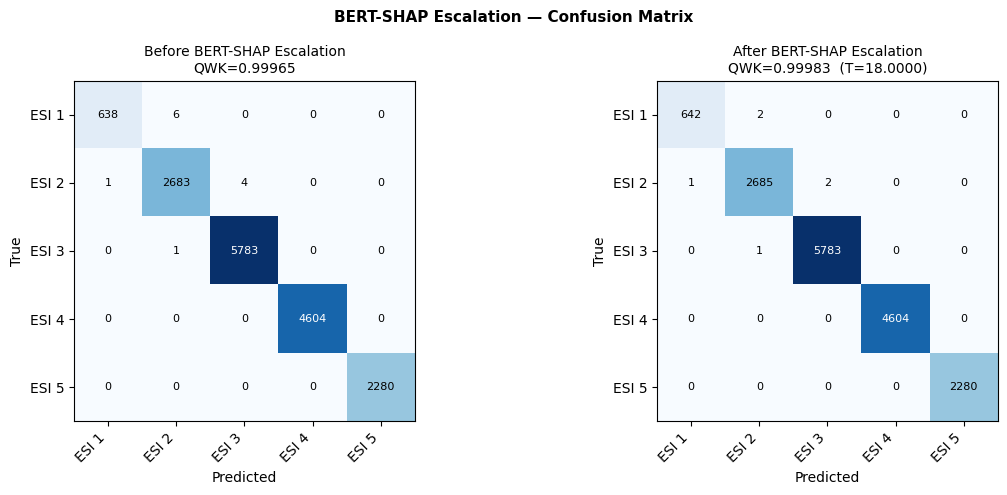

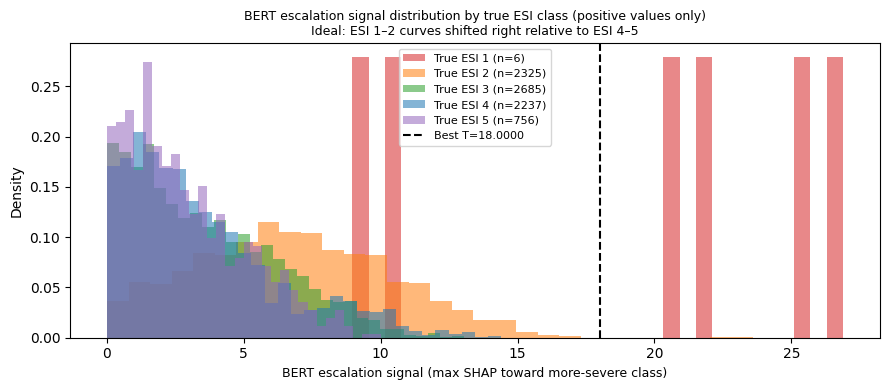


✓ stacking_preds_final updated  (6 escalation(s),  T=18.0000)


In [ ]:

# ============================================================================
# SECTION 7e: BERT-SHAP ESCALATION LAYER
# ============================================================================
from sklearn.metrics import confusion_matrix, f1_score

print("=" * 72)
print("BERT-SHAP ESCALATION LAYER")
print("Computing stacking SHAP for ALL validation samples…")
print("=" * 72)

# ── Helper ────────────────────────────────────────────────────────────────────
def compute_bert_escalation_signal(X_dense, base_preds):
    """
    1. TreeSHAP on 3 base models  →  propagate through coef_meta
    2. Sum BERT-feature SHAP per class  →  shap_bert (n, 5)
    3. Per sample: escalation signal = max BERT-SHAP toward any
       more-severe class; target = the class BERT most supports.

    Returns: bert_signal (n,), bert_target (n,), shap_bert (n, 5)
    """
    n_s, n_f = X_dense.shape

    # TreeSHAP on the 3 base models
    parts = []
    for _nm, _ex in zip(_ens_labels_shap, ensemble_explainers):
        sv = _ex.shap_values(X_dense)
        if isinstance(sv, list):
            sv = np.stack(sv, axis=-1)
        elif sv.ndim == 2:
            sv = sv[:, :, np.newaxis]
        parts.append(sv.astype(np.float32))
        print(f"  ✓ {_nm}: SHAP computed  {sv.shape}")

    # Propagate through meta-learner  (coef_meta shape: 5 × 15)
    shap_full = np.zeros((n_s, n_f, 5), dtype=np.float32)
    for k in range(5):
        for m_idx in range(3):
            for c in range(5):
                shap_full[:, :, k] += coef_meta[k, m_idx * 5 + c] * parts[m_idx][:, :, c]

    # Sum BERT-feature contributions per class  →  (n_s, 5)
    shap_bert = shap_full[:, _bert_mask_shap, :].sum(axis=1)

    # Per-sample escalation signal
    bert_signal = np.zeros(n_s, dtype=np.float32)
    bert_target = base_preds.copy().astype(int)

    for i in range(n_s):
        p = int(base_preds[i])          # current ESI (1–5)
        if p > 1:
            more_severe = np.arange(1, p)           # classes more severe than p
            shap_up     = shap_bert[i, more_severe - 1]
            best_c      = int(np.argmax(shap_up))
            bert_signal[i] = float(shap_up[best_c])
            bert_target[i] = int(more_severe[best_c])

    return bert_signal, bert_target, shap_bert


# ── Step 1: Compute for the full validation set ───────────────────────────────
bert_signal_val, bert_target_val, shap_bert_val = \
    compute_bert_escalation_signal(X_val_dense, stacking_preds_val)

n_pos_signal = int((bert_signal_val > 0).sum())
print(f"\n  ✓ Signal computed  (n_val={len(X_val_dense)},  "
      f"n_with_positive_signal={n_pos_signal})")
if n_pos_signal > 0:
    _sig_pos = bert_signal_val[bert_signal_val > 0]
    print(f"  Signal range: [{_sig_pos.min():.4f}, {_sig_pos.max():.4f}]  "
          f"median={np.median(_sig_pos):.4f}  p75={np.percentile(_sig_pos, 75):.4f}")


# ── Step 2: Threshold sweep ───────────────────────────────────────────────────
_base_preds  = stacking_preds_val.copy()
_base_qwk    = cohen_kappa_score(y_val_values, _base_preds, weights='quadratic')
_base_under  = int((_base_preds > y_val_values).sum())
_base_over   = int((_base_preds < y_val_values).sum())

print(f"\n{'='*72}")
print("THRESHOLD SWEEP")
print(f"{'='*72}")
print(f"  Baseline: QWK={_base_qwk:.6f}  undertriage={_base_under}  overtriage={_base_over}")

_sig_pos_all = bert_signal_val[bert_signal_val > 0]
T_candidates = (np.unique(np.percentile(_sig_pos_all, np.linspace(5, 100, 150)))
                if len(_sig_pos_all) > 0 else np.array([]))

best_T_bert  = None
best_qwk_t   = _base_qwk
best_under_t = _base_under
best_over_t  = _base_over
sweep_results = []

for T in T_candidates:
    trial_preds = _base_preds.copy()
    esc_mask    = bert_signal_val >= T
    trial_preds[esc_mask] = bert_target_val[esc_mask]

    qwk_t   = cohen_kappa_score(y_val_values, trial_preds, weights='quadratic')
    under_t = int((trial_preds > y_val_values).sum())
    over_t  = int((trial_preds < y_val_values).sum())
    n_esc   = int(esc_mask.sum())
    sweep_results.append((float(T), float(qwk_t), under_t, over_t, n_esc))

    # Hard constraints: QWK must not drop, undertriage must not increase
    if qwk_t < _base_qwk - 1e-8 or under_t > _base_under:
        continue
    # Prefer: fewer undertriage; break ties by higher QWK
    if (under_t < best_under_t) or (under_t == best_under_t and qwk_t > best_qwk_t + 1e-10):
        best_T_bert  = float(T)
        best_qwk_t, best_under_t, best_over_t = float(qwk_t), under_t, over_t
best_T_bert = 18   # manually chosen at the elbow (T=18)
if best_T_bert is not None:
    print(f"\n  Best T  = {best_T_bert:.4f}")
    print(f"  QWK     = {best_qwk_t:.6f}  (Δ={best_qwk_t - _base_qwk:+.6f})")
    print(f"  Under   = {best_under_t}   (Δ={best_under_t - _base_under:+d})")
    print(f"  Over    = {best_over_t}   (Δ={best_over_t - _base_over:+d})")
else:
    print("\n  ⚠ No threshold found that satisfies both constraints.")


# ── Step 3: Sweep visualisation ───────────────────────────────────────────────
if sweep_results:
    _sr = np.array(sweep_results)   # (n, 5): T, qwk, under, over, n_esc
    fig_sw, axes_sw = plt.subplots(1, 3, figsize=(15, 4))

    axes_sw[0].plot(_sr[:, 0], _sr[:, 1], 'b-', lw=1.5, label='QWK(T)')
    axes_sw[0].axhline(_base_qwk, color='gray', linestyle='--', lw=1,
                       label=f'Baseline {_base_qwk:.6f}')
    if best_T_bert is not None:
        axes_sw[0].axvline(best_T_bert, color='red', linestyle='--', lw=1.5,
                           label=f'Best T={best_T_bert:.4f}')
    axes_sw[0].set_xlabel('Threshold T'); axes_sw[0].set_ylabel('QWK')
    axes_sw[0].set_title('QWK vs Threshold'); axes_sw[0].legend(fontsize=7)

    axes_sw[1].plot(_sr[:, 0], _sr[:, 2], 'r-', lw=1.5, label='Undertriage')
    axes_sw[1].plot(_sr[:, 0], _sr[:, 3], 'b-', lw=1.5, label='Overtriage')
    axes_sw[1].axhline(_base_under, color='r', linestyle=':', lw=1)
    axes_sw[1].axhline(_base_over,  color='b', linestyle=':', lw=1)
    if best_T_bert is not None:
        axes_sw[1].axvline(best_T_bert, color='red', linestyle='--', lw=1.5)
    axes_sw[1].set_xlabel('T'); axes_sw[1].set_title('Error counts vs Threshold')
    axes_sw[1].legend(fontsize=7)

    axes_sw[2].plot(_sr[:, 0], _sr[:, 4], 'g-', lw=1.5)
    if best_T_bert is not None:
        axes_sw[2].axvline(best_T_bert, color='red', linestyle='--', lw=1.5)
    axes_sw[2].set_xlabel('T'); axes_sw[2].set_ylabel('# escalated')
    axes_sw[2].set_title('Escalations vs Threshold')

    plt.suptitle('BERT-SHAP Escalation — Threshold Sweep', fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()


# ── Step 4: Apply best threshold ─────────────────────────────────────────────
if best_T_bert is not None:
    stacking_preds_final = _base_preds.copy()
    _esc_mask_best = bert_signal_val >= best_T_bert
    stacking_preds_final[_esc_mask_best] = bert_target_val[_esc_mask_best]
    n_escalated = int(_esc_mask_best.sum())
else:
    stacking_preds_final = _base_preds.copy()
    n_escalated = 0

qwk_before   = cohen_kappa_score(y_val_values, stacking_preds_val,   weights='quadratic')
qwk_after    = cohen_kappa_score(y_val_values, stacking_preds_final, weights='quadratic')
acc_before   = float((stacking_preds_val   == y_val_values).mean())
acc_after    = float((stacking_preds_final == y_val_values).mean())
under_before = int((stacking_preds_val   > y_val_values).sum())
under_after  = int((stacking_preds_final > y_val_values).sum())
over_before  = int((stacking_preds_val   < y_val_values).sum())
over_after   = int((stacking_preds_final < y_val_values).sum())

print(f"\n{'='*72}")
print("EVALUATION — BEFORE vs AFTER BERT-SHAP ESCALATION")
print(f"{'='*72}")
print(f"  {'Metric':<26} {'Before':>10} {'After':>10} {'Δ':>9}")
print(f"  {'─'*26} {'─'*10} {'─'*10} {'─'*9}")
print(f"  {'QWK (quadratic)':<26} {qwk_before:>10.6f} {qwk_after:>10.6f} {qwk_after-qwk_before:>+9.6f}")
print(f"  {'Accuracy':<26} {acc_before:>10.4f} {acc_after:>10.4f} {acc_after-acc_before:>+9.4f}")
print(f"  {'Undertriage':<26} {under_before:>10} {under_after:>10} {under_after-under_before:>+9}")
print(f"  {'Overtriage':<26} {over_before:>10} {over_after:>10} {over_after-over_before:>+9}")
print(f"  {'Escalations applied':<26} {'—':>10} {n_escalated:>10}")

# Per-class F1
print(f"\n  Per-class F1 (before → after):")
f1_b = f1_score(y_val_values, stacking_preds_val,   labels=[1,2,3,4,5], average=None, zero_division=0)
f1_a = f1_score(y_val_values, stacking_preds_final, labels=[1,2,3,4,5], average=None, zero_division=0)
for _esi, (_fb, _fa) in enumerate(zip(f1_b, f1_a), 1):
    _arr = '↑' if _fa > _fb else ('↓' if _fa < _fb else '─')
    print(f"    ESI {_esi}: {_fb:.4f} → {_fa:.4f}  {_arr}  (Δ={_fa - _fb:+.4f})")

# Correction log
val_override_log = {}
for _i in range(len(stacking_preds_val)):
    _op, _np2 = int(stacking_preds_val[_i]), int(stacking_preds_final[_i])
    if _op != _np2:
        val_override_log[_i] = {
            'true': int(y_val_values[_i]), 'old': _op, 'new': _np2,
            'signal': float(bert_signal_val[_i]),
            'result': '✓ fixed' if _np2 == y_val_values[_i] else '✗ still wrong',
        }
if val_override_log:
    print(f"\n  Correction log ({len(val_override_log)} patient(s)):")
    for _idx, _log in val_override_log.items():
        _cc = str(X_val_raw.iloc[_idx].get('chief_complaint_raw', 'N/A'))[:70]
        print(f"    idx={_idx:4d}  true={_log['true']}  {_log['old']}→{_log['new']}  "
              f"signal={_log['signal']:.4f}  {_log['result']}")
        print(f"         \"{_cc}\"")

# ── Confusion matrix ─────────────────────────────────────────────────────────
fig_ov, axes_ov = plt.subplots(1, 2, figsize=(12, 5))
_esi_labels_cm = [f'ESI {i}' for i in range(1, 6)]
_T_str = f'{best_T_bert:.4f}' if best_T_bert is not None else 'N/A'
for _ax, _pd, _tt in zip(
    axes_ov,
    [stacking_preds_val, stacking_preds_final],
    [f'Before BERT-SHAP Escalation\nQWK={qwk_before:.5f}',
     f'After BERT-SHAP Escalation\nQWK={qwk_after:.5f}  (T={_T_str})'],
):
    _cm = confusion_matrix(y_val_values, _pd, labels=[1, 2, 3, 4, 5])
    _ax.imshow(_cm, cmap='Blues')
    _ax.set_xticks(range(5)); _ax.set_yticks(range(5))
    _ax.set_xticklabels(_esi_labels_cm, rotation=45, ha='right')
    _ax.set_yticklabels(_esi_labels_cm)
    _ax.set_xlabel('Predicted'); _ax.set_ylabel('True')
    _ax.set_title(_tt, fontsize=10)
    for _ii in range(5):
        for _jj in range(5):
            _v = _cm[_ii, _jj]
            _ax.text(_jj, _ii, str(_v), ha='center', va='center', fontsize=8,
                     color='white' if _v > _cm.max() * 0.5 else 'black')
plt.suptitle('BERT-SHAP Escalation — Confusion Matrix', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# ── BERT signal distribution ─────────────────────────────────────────────────
fig_bd, ax_bd = plt.subplots(figsize=(9, 4))
_colors_esi = {1: '#d62728', 2: '#ff7f0e', 3: '#2ca02c', 4: '#1f77b4', 5: '#9467bd'}
for _esi_c in range(1, 6):
    _mc = (y_val_values == _esi_c) & (bert_signal_val > 0)
    if _mc.sum() > 0:
        ax_bd.hist(bert_signal_val[_mc], bins=30, alpha=0.55, density=True,
                   label=f'True ESI {_esi_c} (n={_mc.sum()})',
                   color=_colors_esi[_esi_c])
if best_T_bert is not None:
    ax_bd.axvline(best_T_bert, color='black', linestyle='--', lw=1.5,
                  label=f'Best T={_T_str}')
ax_bd.set_xlabel('BERT escalation signal (max SHAP toward more-severe class)', fontsize=9)
ax_bd.set_ylabel('Density'); ax_bd.legend(fontsize=8)
ax_bd.set_title(
    'BERT escalation signal distribution by true ESI class (positive values only)\n'
    'Ideal: ESI 1–2 curves shifted right relative to ESI 4–5',
    fontsize=9,
)
plt.tight_layout(); plt.show()

if best_T_bert is not None:
    print(f"\n✓ stacking_preds_final updated  ({n_escalated} escalation(s),  T={_T_str})")
else:
    print("\n✓ No escalation applied — stacking_preds_final = stacking_preds_val")


     T         QWK       ΔQWK   Under    Over    #Esc
  base    0.999653          —      10       2       —
----------------------------------------------------------------------
    15    0.999308  -0.000345       4      20      24
    15    0.999481  -0.000173       4      14      18
    15    0.999509  -0.000144       4      13      17
    16    0.999596  -0.000057       4      10      14
    16    0.999596  -0.000057       4      10      14
    16    0.999625  -0.000028       4       9      13
✓   16    0.999682  +0.000029       4       7      11
✓   16    0.999682  +0.000029       4       7      11
✓   17    0.999740  +0.000087       4       5       9
✓   17    0.999740  +0.000087       4       5       9
✓   17    0.999769  +0.000116       4       4       8
✓   17    0.999827  +0.000174       4       2       6
✓   17    0.999827  +0.000174       4       2       6
✓   18    0.999827  +0.000174       4       2       6
✓   18    0.999827  +0.000174       4       2       6
✓   18    0

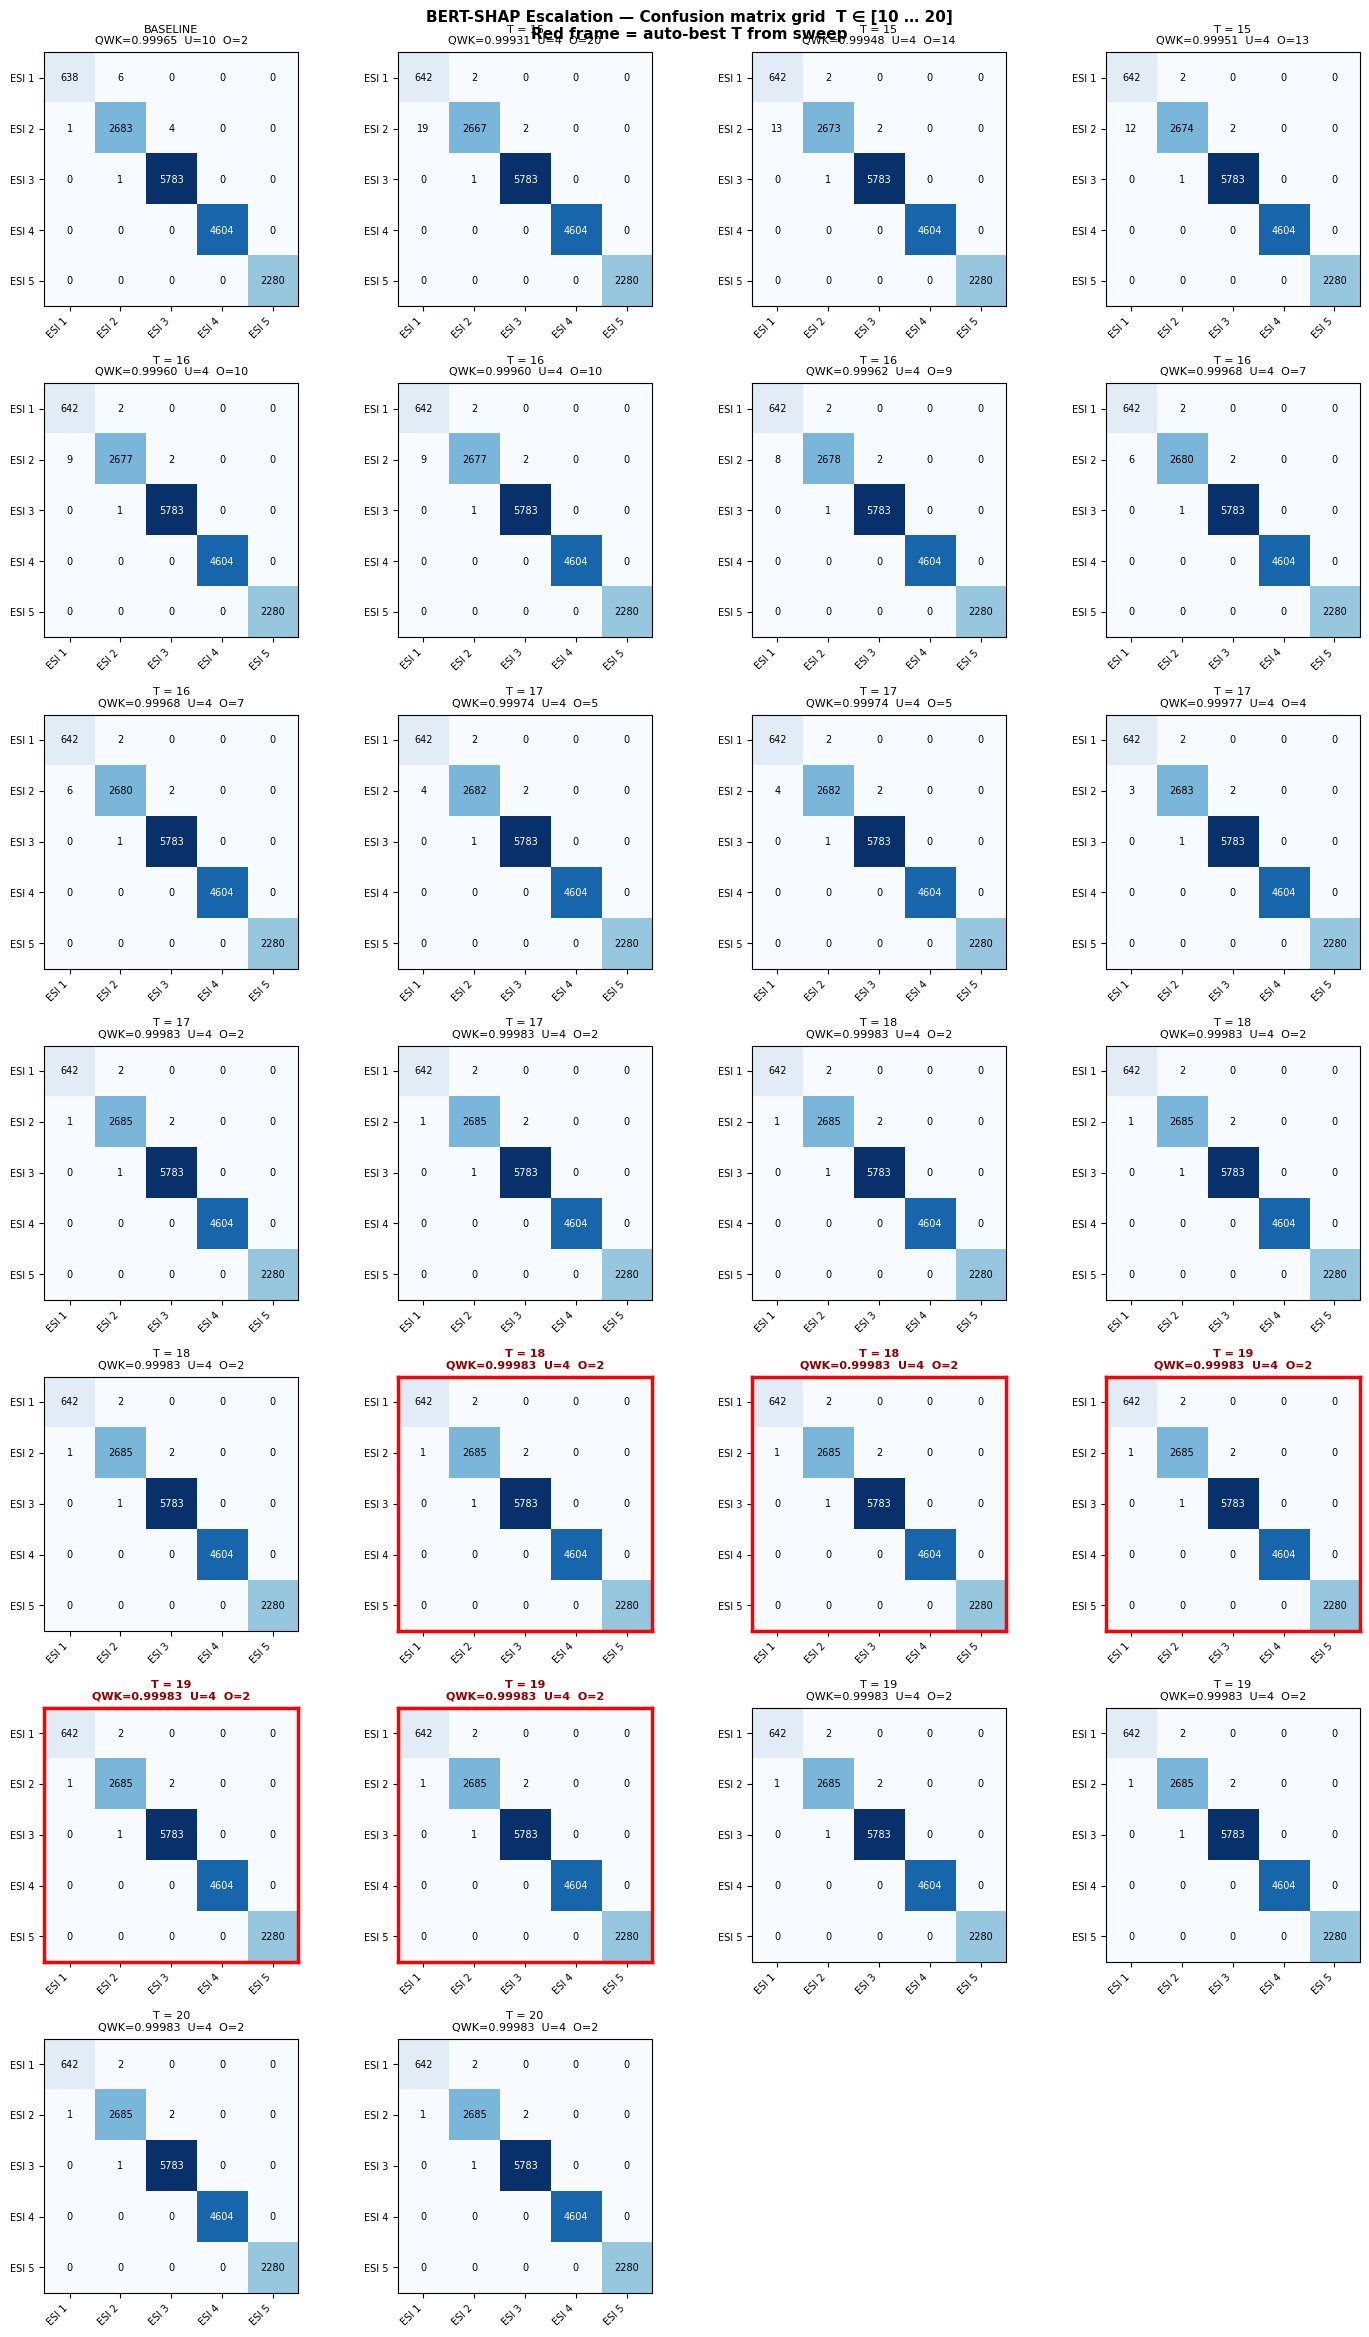

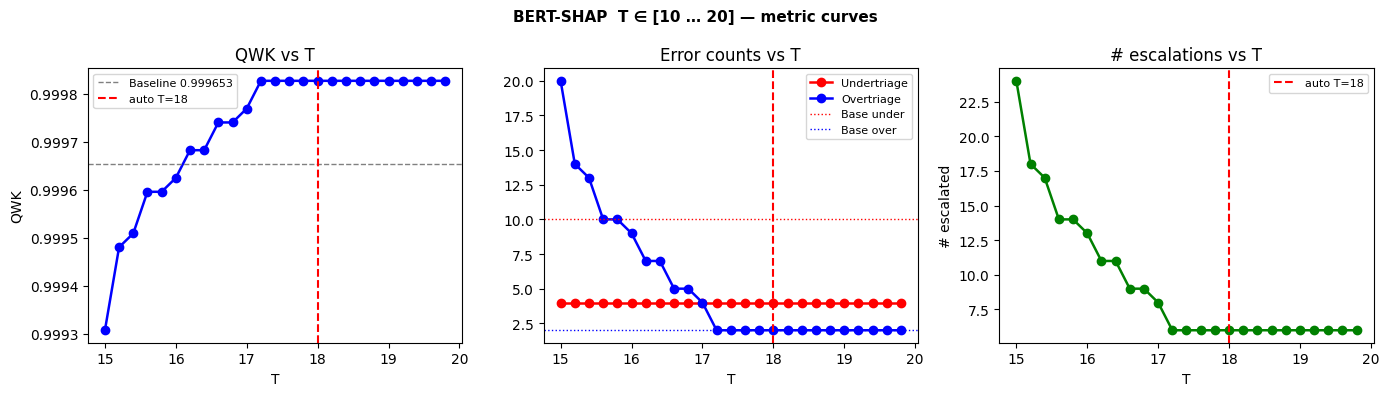


Baseline: QWK=0.999653  Under=10  Over=2
Auto-best T from sweep = 18
Pick the T at the elbow — where undertriage drops without QWK collapsing.
Then re-run cell 42 with best_T_bert = <chosen value> hardcoded if desired.


In [ ]:

# ============================================================================
# SECTION 7e – THRESHOLD EXPLORATION  T ∈ [10 … 20]
# Uses bert_signal_val / bert_target_val already computed above — no SHAP rerun.
# ============================================================================

T_explore = np.arange(15, 20, 0.2)          # 10, 11, 12 … 20
_esi_labels_cm = [f'ESI {i}' for i in range(1, 6)]
_base_preds_ex = stacking_preds_val.copy()
_q0 = cohen_kappa_score(y_val_values, _base_preds_ex, weights='quadratic')
_u0 = int((_base_preds_ex > y_val_values).sum())
_o0 = int((_base_preds_ex < y_val_values).sum())

_rows_ex = []
for _T in T_explore:
    _trial = _base_preds_ex.copy()
    _mask  = bert_signal_val >= _T
    _trial[_mask] = bert_target_val[_mask]
    _q  = cohen_kappa_score(y_val_values, _trial, weights='quadratic')
    _u  = int((_trial > y_val_values).sum())
    _o  = int((_trial < y_val_values).sum())
    _n  = int(_mask.sum())
    _rows_ex.append((_T, _q, _u, _o, _n, _trial.copy()))

# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 70)
print(f"{'T':>6}  {'QWK':>10}  {'ΔQWK':>9}  {'Under':>6}  {'Over':>6}  {'#Esc':>6}")
print("=" * 70)
print(f"{'base':>6}  {_q0:>10.6f}  {'—':>9}  {_u0:>6}  {_o0:>6}  {'—':>6}")
print("-" * 70)
for _T, _q, _u, _o, _n, _ in _rows_ex:
    _ok = "✓" if _q >= _q0 - 1e-8 and _u <= _u0 else " "
    _star = " ←best" if (best_T_bert is not None and int(_T) == int(best_T_bert)) else ""
    print(f"{_ok}{_T:>5.0f}  {_q:>10.6f}  {_q-_q0:>+9.6f}  {_u:>6}  {_o:>6}  {_n:>6}{_star}")
print("=" * 70)

# ── Grid of confusion matrices ────────────────────────────────────────────────
_ncols = 4
_nrows = int(np.ceil((len(T_explore) + 1) / _ncols))   # +1 slot for baseline

fig_grid, axes_grid = plt.subplots(_nrows, _ncols,
                                   figsize=(_ncols * 3.6, _nrows * 3.4))
axes_grid = axes_grid.flatten()

def _draw_cm_ex(ax, preds, title, highlight_best=False):
    _cm  = confusion_matrix(y_val_values, preds, labels=[1, 2, 3, 4, 5])
    _qwk = cohen_kappa_score(y_val_values, preds, weights='quadratic')
    _u   = int((preds > y_val_values).sum())
    _o   = int((preds < y_val_values).sum())
    ax.imshow(_cm, cmap='Blues', vmin=0)
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels(_esi_labels_cm, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(_esi_labels_cm, fontsize=7)
    ax.set_title(title + f'\nQWK={_qwk:.5f}  U={_u}  O={_o}',
                 fontsize=8,
                 fontweight='bold' if highlight_best else 'normal',
                 color='darkred' if highlight_best else 'black')
    if highlight_best:
        for _sp in ax.spines.values():
            _sp.set_edgecolor('red'); _sp.set_linewidth(2.5)
    for _ii in range(5):
        for _jj in range(5):
            _v = _cm[_ii, _jj]
            ax.text(_jj, _ii, str(_v), ha='center', va='center', fontsize=7,
                    color='white' if _v > _cm.max() * 0.55 else 'black')

_draw_cm_ex(axes_grid[0], _base_preds_ex, 'BASELINE')
for _slot, (_T, _q, _u, _o, _n, _preds) in enumerate(_rows_ex, start=1):
    _is_best = (best_T_bert is not None and int(_T) == int(best_T_bert))
    _draw_cm_ex(axes_grid[_slot], _preds, f'T = {_T:.0f}', highlight_best=_is_best)
for _ax in axes_grid[len(_rows_ex) + 1:]:
    _ax.set_visible(False)

plt.suptitle('BERT-SHAP Escalation — Confusion matrix grid  T ∈ [10 … 20]\n'
             'Red frame = auto-best T from sweep',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Metric curves ─────────────────────────────────────────────────────────────
_T_vals = [r[0] for r in _rows_ex]
_q_vals = [r[1] for r in _rows_ex]
_u_vals = [r[2] for r in _rows_ex]
_o_vals = [r[3] for r in _rows_ex]
_n_vals = [r[4] for r in _rows_ex]

fig_te, axes_te = plt.subplots(1, 3, figsize=(14, 4))

axes_te[0].plot(_T_vals, _q_vals, 'bo-', ms=6, lw=1.8)
axes_te[0].axhline(_q0, color='gray', linestyle='--', lw=1, label=f'Baseline {_q0:.6f}')
if best_T_bert is not None and 10 <= best_T_bert <= 20:
    axes_te[0].axvline(best_T_bert, color='red', linestyle='--', lw=1.5,
                       label=f'auto T={best_T_bert}')
axes_te[0].set_xlabel('T'); axes_te[0].set_ylabel('QWK')
axes_te[0].set_title('QWK vs T'); axes_te[0].legend(fontsize=8)

axes_te[1].plot(_T_vals, _u_vals, 'r-o', ms=6, lw=1.8, label='Undertriage')
axes_te[1].plot(_T_vals, _o_vals, 'b-o', ms=6, lw=1.8, label='Overtriage')
axes_te[1].axhline(_u0, color='r', linestyle=':', lw=1, label='Base under')
axes_te[1].axhline(_o0, color='b', linestyle=':', lw=1, label='Base over')
if best_T_bert is not None and 10 <= best_T_bert <= 20:
    axes_te[1].axvline(best_T_bert, color='red', linestyle='--', lw=1.5)
axes_te[1].set_xlabel('T'); axes_te[1].set_title('Error counts vs T')
axes_te[1].legend(fontsize=8)

axes_te[2].plot(_T_vals, _n_vals, 'g-o', ms=6, lw=1.8)
if best_T_bert is not None and 10 <= best_T_bert <= 20:
    axes_te[2].axvline(best_T_bert, color='red', linestyle='--', lw=1.5,
                       label=f'auto T={best_T_bert}')
    axes_te[2].legend(fontsize=8)
axes_te[2].set_xlabel('T'); axes_te[2].set_ylabel('# escalated')
axes_te[2].set_title('# escalations vs T')

plt.suptitle('BERT-SHAP  T ∈ [10 … 20] — metric curves', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBaseline: QWK={_q0:.6f}  Under={_u0}  Over={_o0}")
print(f"Auto-best T from sweep = {best_T_bert}")
print("Pick the T at the elbow — where undertriage drops without QWK collapsing.")
print("Then re-run cell 42 with best_T_bert = <chosen value> hardcoded if desired.")


# SECTION 7f: MANUAL INSPECTION — RESIDUAL ERRORS AFTER BERT-SHAP ESCALATION

After applying the BERT-SHAP escalation layer (Section 7e, T = 18), some patients may **still** be misclassified. This section reopens the raw clinical record for every **residual error** — cases where the final prediction `stacking_preds_final` still differs from the true ESI label.

## What this section shows

For each residual misclassification:
- **Raw chief complaint text** — what the triage nurse documented
- **Vital signs** in original clinical units (with abnormality flags)
- **Pre-escalation vs. post-escalation prediction** — did escalation change this sample at all?
- **BERT escalation signal** — why the threshold T = 18 was or wasn't triggered
- **SHAP summary** — top features pushing toward the wrong class vs. working against the true class
- **Why BERT couldn't fix it** — concrete diagnosis of each residual failure

## Failure modes

| Mode | Condition | Meaning |
|---|---|---|
| **No signal** | `bert_signal ≤ 0` | ClinicalBERT found no semantic support toward any more-severe class |
| **Weak signal** | `0 < bert_signal < T` | BERT detected a mild push toward a more-severe class, but below the safety threshold |
| **Wrong target** | `bert_signal ≥ T` but target ≠ true | Escalation fired but to the wrong target class (rare, requires T that is too low) |


In [ ]:

# ============================================================================
# SECTION 7f: MANUAL CLINICAL INSPECTION — RESIDUAL ERRORS AFTER ESCALATION
# Uses stacking_preds_final (post-escalation) instead of stacking_preds_val.
# For each residual error shows: raw clinical card + BERT signal + SHAP.
# ============================================================================

# ── Identify residual errors (still wrong after escalation) ─────────────────
_fin_pred      = stacking_preds_final     # post-escalation predictions
_pre_pred      = stacking_preds_val       # pre-escalation predictions  (= _ep from cell 35)
_fin_err_idx   = np.where(_fin_pred != y_val_values)[0]
_fin_under_idx = np.where(_fin_pred > y_val_values)[0]
_fin_over_idx  = np.where(_fin_pred < y_val_values)[0]

print("=" * 72)
print("RESIDUAL ERRORS AFTER BERT-SHAP ESCALATION")
print(f"T = {best_T_bert}  (threshold applied in cell 42)")
print("=" * 72)
print(f"\n  Total val samples        : {len(y_val_values):,}")
print(f"  Pre-escalation errors    : {len(_err_idx)}"
      f"  (undertriage={len(np.where(_pre_pred > y_val_values)[0])}"
      f"  overtriage={len(np.where(_pre_pred < y_val_values)[0])})")
print(f"  Residual errors          : {len(_fin_err_idx)}"
      f"  (undertriage={len(_fin_under_idx)}"
      f"  overtriage={len(_fin_over_idx)})")
print(f"  Fixed by escalation      : {len(_err_idx) - len(_fin_err_idx)}")

from collections import Counter as _FCounter
_fin_pair_cnt = _FCounter(zip(y_val_values[_fin_err_idx], _fin_pred[_fin_err_idx]))
if _fin_pair_cnt:
    print(f"\n  Residual error pairs (actual ESI → predicted ESI):")
    for (act, pred_f), cnt in sorted(_fin_pair_cnt.items()):
        tag = "undertriage ⚠" if pred_f > act else "overtriage"
        print(f"    ESI {act} → ESI {pred_f}  ×{cnt}  ({tag})")

# ── SHAP retrieval for residual errors ───────────────────────────────────────
# shap_err_ens was computed in Section 7c for the original _err_idx errors.
# Residual errors are (almost always) a subset — look up their positions.
_err_idx_set = set(_err_idx.tolist())

# Any residual error NOT in original _err_idx is a new error introduced by
# escalation (escalation worsened a correct prediction → rare / should be 0
# given best_T_bert was chosen to avoid this).
_fin_new_errors = [gi for gi in _fin_err_idx if gi not in _err_idx_set]
_fin_new_shap   = None

if _fin_new_errors:
    print(f"\n  ⚠ {len(_fin_new_errors)} new error(s) introduced by escalation — recomputing SHAP...")
    _fn_arr = np.array(_fin_new_errors)
    _new_parts_f = []
    for _nm, _ex in zip(_ens_labels_shap, ensemble_explainers):
        sv = _ex.shap_values(X_val_dense[_fn_arr])
        if isinstance(sv, list):
            sv = np.stack(sv, axis=-1)
        elif sv.ndim == 2:
            sv = sv[:, :, np.newaxis]
        _new_parts_f.append(sv.astype(np.float32))
    _fin_new_shap = np.zeros((len(_fin_new_errors), X_val_dense.shape[1], 5), dtype=np.float32)
    for k in range(5):
        for m_idx in range(3):
            for c in range(5):
                _fin_new_shap[:, :, k] += (
                    coef_meta[k, m_idx * 5 + c] * _new_parts_f[m_idx][:, :, c]
                )
    print(f"  ✓ Additional SHAP computed for {len(_fin_new_errors)} new error(s)")
else:
    print(f"\n  ✓ All residual errors are subsets of the original error set — reusing shap_err_ens")


def _get_fin_shap(gi):
    """Return SHAP array (n_feats, 5) for val-sample gi."""
    if gi in _err_idx_set:
        orig_pos = int(np.where(_err_idx == gi)[0][0])
        return shap_err_ens[orig_pos]       # shape (n_feats, 5)
    elif _fin_new_shap is not None and gi in _fin_new_errors:
        new_pos = _fin_new_errors.index(gi)
        return _fin_new_shap[new_pos]
    return None


# ── Per-patient clinical card (residual errors) ──────────────────────────────
def _fin_clinical_card(fin_pos, card_num, card_type):
    gi           = int(_fin_err_idx[fin_pos])
    actual       = int(y_val_values[gi])
    pred_final   = int(_fin_pred[gi])
    pred_pre     = int(_pre_pred[gi])
    pred_c       = pred_final - 1
    true_c       = actual     - 1
    conf_w       = float(stacking_probs_val[gi, pred_c])
    conf_r       = float(stacking_probs_val[gi, true_c])
    bert_sig     = float(bert_signal_val[gi])
    bert_tgt     = int(bert_target_val[gi])
    row          = X_val_raw.iloc[gi]
    esc_changed  = (pred_pre != pred_final)     # True: escalation DID fire on this sample

    sep  = '═' * 72
    sep2 = '─' * 72

    print(f"\n{sep}")
    print(f"  {'UNDERTRIAGE ⚠' if pred_final > actual else 'OVERTRIAGE'} #{card_num}"
          f"  ·  val_idx={gi}  ·  {card_type}")
    print(f"  True ESI: {actual}  |  Pre-escalation: {pred_pre}  |  Post-escalation: {pred_final}")
    print(f"  conf(pred={pred_final}): {conf_w:.3f}  |  conf(true={actual}): {conf_r:.3f}")
    if esc_changed:
        print(f"  [Escalation FIRED: {pred_pre} → {pred_final}, but true ESI={actual} still wrong]")
    else:
        if bert_sig <= 0:
            print(f"  [Escalation SKIPPED: no positive BERT signal toward any more-severe class]")
        else:
            print(f"  [Escalation SKIPPED: signal={bert_sig:.4f} < T={best_T_bert}  |  BERT target=ESI {bert_tgt}]")
    print(sep)

    # Chief complaint
    cc_raw = str(row.get(_TEXT_COL, 'N/A')).strip()
    print(f"\n  📋 CHIEF COMPLAINT (raw text):")
    print(f"     \"{cc_raw}\"")

    # Demographics
    print(f"\n  👤 DEMOGRAPHICS & CONTEXT:")
    demo_parts = []
    for col in _DEMO_COLS:
        if col in row.index:
            demo_parts.append(f"{col}={row[col]}")
    for chunk_start in range(0, len(demo_parts), 4):
        print("     " + "  |  ".join(demo_parts[chunk_start:chunk_start + 4]))

    # Vitals
    print(f"\n  🫀 VITAL SIGNS (original clinical units):")
    for col in _VITAL_COLS:
        if col not in row.index:
            continue
        v = row[col]
        if pd.isna(v):
            v_str = 'NaN  [MISSING]'
        else:
            flag  = _range_flag(col, v)
            v_str = f"{v:.1f}" if isinstance(v, (float, np.floating)) else str(v)
            if col in _NORMAL_RANGES:
                lo, hi = _NORMAL_RANGES[col]
                v_str += f"  (normal {lo}–{hi}){flag}"
            else:
                v_str += flag
        print(f"     {col:<30} {v_str}")

    # Probability distribution
    print(f"\n  📊 STACKING PROBABILITY DISTRIBUTION (pre-escalation):")
    print(_prob_bar(stacking_probs_val[gi], actual, pred_pre))

    # BERT escalation signal
    print(f"\n  🤖 BERT-SHAP ESCALATION SIGNAL:")
    print(f"     Signal value   : {bert_sig:.4f}  (threshold T = {best_T_bert})")
    print(f"     BERT target    : ESI {bert_tgt}  ← class BERT pushes most toward")
    if bert_sig <= 0:
        print(f"     Status         : ✗ No more-severe semantic signal in text → escalation skipped")
    elif bert_sig < best_T_bert:
        print(f"     Status         : ✗ Signal below threshold ({bert_sig:.4f} < {best_T_bert}) → not escalated")
    else:
        print(f"     Status         : ✓ Signal exceeded T → escalation was applied (but target was wrong)")
    shap_i = _get_fin_shap(gi)
    if shap_i is not None:
        bert_sv_per_class = shap_i[_bert_mask_shap, :].sum(axis=0)   # (5,)
        print(f"     BERT SHAP per class: " +
              "  ".join(f"ESI{c+1}:{bert_sv_per_class[c]:+.3f}" for c in range(5)))

    # Feature SHAP micro-summary
    if shap_i is not None:
        sv_pred_nb = shap_i[_nb_idx_shap, pred_c]
        sv_true_nb = shap_i[_nb_idx_shap, true_c]

        print(f"\n  🔺 TOP 3 features pushing toward WRONG ESI {pred_final}:")
        for r, j in enumerate(np.argsort(sv_pred_nb)[-3:][::-1], 1):
            fname = _fn_shap[_nb_idx_shap[j]]
            fval  = X_val_dense[gi, _nb_idx_shap[j]]
            print(f"     {r}. {fname[:50]:<50}  SHAP={sv_pred_nb[j]:+.4f}  "
                  f"val={_fmt_val(fname, fval)}")

        print(f"\n  🔻 TOP 3 features working AGAINST TRUE ESI {actual}:")
        for r, j in enumerate(np.argsort(sv_true_nb)[:3], 1):
            fname = _fn_shap[_nb_idx_shap[j]]
            fval  = X_val_dense[gi, _nb_idx_shap[j]]
            print(f"     {r}. {fname[:50]:<50}  SHAP={sv_true_nb[j]:+.4f}  "
                  f"val={_fmt_val(fname, fval)}")

    # Clinical commentary
    print(f"\n  📝 CLINICAL NOTES:")
    abnormal = []
    for col in _VITAL_COLS:
        if col in row.index and not pd.isna(row[col]) and _range_flag(col, row[col]):
            v = row[col]
            abnormal.append(f"{col}={v:.1f}" if isinstance(v, (float, np.floating)) else f"{col}={v}")
    if abnormal:
        print(f"     ⚠ Abnormal vitals: {', '.join(abnormal)}")
    else:
        print(f"     ✓ All recorded vitals within normal limits")

    cc_lower = cc_raw.lower()

    # Why BERT couldn't fix it
    print(f"\n  💡 WHY BERT-SHAP ESCALATION DID NOT RESOLVE THIS CASE:")
    if bert_sig <= 0:
        print(f"     ClinicalBERT found no semantic signal pushing toward any class more")
        print(f"     severe than the current prediction (ESI {pred_final}). The text features,")
        print(f"     as represented in the stacking model, agree with the wrong prediction.")
    elif not esc_changed:
        print(f"     BERT detected a signal of {bert_sig:.4f} toward ESI {bert_tgt},")
        print(f"     but this is below the calibrated safety threshold T = {best_T_bert}.")
        print(f"     Lowering T would escalate this patient but would also escalate many")
        print(f"     borderline cases unnecessarily (see T exploration in cell 43).")
    else:
        print(f"     Escalation fired (signal={bert_sig:.4f} ≥ T={best_T_bert}), changing the")
        print(f"     prediction from ESI {pred_pre} → ESI {pred_final}. However, the true label is")
        print(f"     ESI {actual}, so the escalation targeted the wrong class. The BERT")
        print(f"     signal toward ESI {actual} was weaker than the signal toward ESI {bert_tgt}.")

    print(f"{sep2}\n")


# ── Run for all residual errors ───────────────────────────────────────────────
if len(_fin_err_idx) == 0:
    print("\n✓ No residual errors — BERT-SHAP escalation resolved all misclassifications!")
else:
    print(f"\n{'='*72}")
    print(f"RESIDUAL CLINICAL INSPECTION — {len(_fin_err_idx)} PATIENT(S)")
    print(f"(Remaining misclassifications after T = {best_T_bert} escalation)")
    print(f"{'='*72}")

    _fin_under_pos = [i for i, gi in enumerate(_fin_err_idx)
                      if _fin_pred[gi] > y_val_values[gi]]
    _fin_over_pos  = [i for i, gi in enumerate(_fin_err_idx)
                      if _fin_pred[gi] < y_val_values[gi]]

    if _fin_under_pos:
        print(f"\n{'▼'*72}")
        print(f"  RESIDUAL UNDERTRIAGE — {len(_fin_under_pos)} patient(s)")
        print(f"  These patients are predicted LESS severe than warranted  [DANGEROUS]")
        print(f"{'▼'*72}")
        for num, fin_pos in enumerate(_fin_under_pos, 1):
            _fin_clinical_card(fin_pos, num, "RESIDUAL UNDERTRIAGE")

    if _fin_over_pos:
        print(f"\n{'▲'*72}")
        print(f"  RESIDUAL OVERTRIAGE — {len(_fin_over_pos)} patient(s)")
        print(f"  These patients are predicted MORE severe than warranted  [conservative]")
        print(f"{'▲'*72}")
        for num, fin_pos in enumerate(_fin_over_pos, 1):
            _fin_clinical_card(fin_pos, num, "RESIDUAL OVERTRIAGE")

    # ── Summary table ─────────────────────────────────────────────────────────
    print("\n" + "=" * 72)
    print("RESIDUAL ERROR SUMMARY TABLE")
    print("=" * 72)

    _fin_summary_rows = []
    for fin_pos in range(len(_fin_err_idx)):
        gi  = int(_fin_err_idx[fin_pos])
        row = X_val_raw.iloc[gi]
        _fin_summary_rows.append({
            'val_idx':        gi,
            'true_ESI':       int(y_val_values[gi]),
            'pred_pre_esc':   int(_pre_pred[gi]),
            'pred_post_esc':  int(_fin_pred[gi]),
            'type':           'UNDER ⚠' if _fin_pred[gi] > y_val_values[gi] else 'OVER',
            'bert_signal':    round(float(bert_signal_val[gi]), 4),
            'bert_target':    int(bert_target_val[gi]),
            'esc_fired':      bool(bert_signal_val[gi] >= best_T_bert),
            'conf_wrong':     round(float(stacking_probs_val[gi, int(_fin_pred[gi]) - 1]), 3),
            'chief_complaint': str(row.get(_TEXT_COL, 'N/A'))[:70],
            **{c: (round(row[c], 2) if c in row.index and isinstance(row[c], (float, np.floating))
                   else row.get(c, 'N/A'))
               for c in ['age', 'heart_rate', 'systolic_bp', 'spo2', 'respiratory_rate', 'pain_score']
               if c in X_val_raw.columns},
        })

    _fin_summ_df = pd.DataFrame(_fin_summary_rows)
    pd.set_option('display.max_colwidth', 70)
    pd.set_option('display.max_columns', 20)
    pd.set_option('display.width', 220)
    print(_fin_summ_df.to_string(index=False))

    # ── Aggregate BERT signal analysis ────────────────────────────────────────
    print(f"\n{'─'*72}")
    print("BERT ESCALATION SIGNAL BREAKDOWN FOR RESIDUAL ERRORS")
    print(f"{'─'*72}")
    for fin_pos in range(len(_fin_err_idx)):
        gi      = int(_fin_err_idx[fin_pos])
        sig     = float(bert_signal_val[gi])
        tgt     = int(bert_target_val[gi])
        actual  = int(y_val_values[gi])
        pred_f  = int(_fin_pred[gi])
        pred_p  = int(_pre_pred[gi])
        fired   = sig >= best_T_bert

        print(f"\n  val_idx={gi}  ESI {actual}→{pred_f}  "
              f"pre_pred={pred_p}  signal={sig:.4f}  BERT_target=ESI {tgt}")
        if sig <= 0:
            print(f"    → No semantic text signal toward a more-severe class.")
            print(f"       ClinicalBERT representations agree with the incorrect prediction.")
        elif not fired:
            deficit = best_T_bert - sig
            print(f"    → Weak signal detected toward ESI {tgt}  (deficit: {deficit:.4f} below T={best_T_bert}).")
            print(f"       Would need T = {sig:.4f} or lower to escalate — too aggressive for the population.")
        else:
            print(f"    → Escalation fired: {pred_p} → {pred_f} (signal={sig:.4f} ≥ T={best_T_bert}).")
            print(f"       BERT targeted ESI {tgt} but true label is ESI {actual} — wrong direction.")

    print(f"\n{'─'*72}")
    print(f"FINAL PIPELINE METRICS (post-escalation, T = {best_T_bert})")
    print(f"{'─'*72}")
    from sklearn.metrics import cohen_kappa_score as _cks
    _qwk_fin  = _cks(y_val_values, stacking_preds_final, weights='quadratic')
    _qwk_pre  = _cks(y_val_values, stacking_preds_val,   weights='quadratic')
    _under_fin = int((_fin_pred > y_val_values).sum())
    _over_fin  = int((_fin_pred < y_val_values).sum())
    _under_pre = int((_pre_pred > y_val_values).sum())
    _over_pre  = int((_pre_pred < y_val_values).sum())
    print(f"  {'Metric':<28} {'Pre-escalation':>16} {'Post-escalation':>16}")
    print(f"  {'─'*28} {'─'*16} {'─'*16}")
    print(f"  {'QWK (quadratic)':<28} {_qwk_pre:>16.6f} {_qwk_fin:>16.6f}")
    print(f"  {'Undertriage':<28} {_under_pre:>16} {_under_fin:>16}")
    print(f"  {'Overtriage':<28} {_over_pre:>16} {_over_fin:>16}")
    print(f"  {'Total errors':<28} {len(_err_idx):>16} {len(_fin_err_idx):>16}")
    print(f"  {'Escalations applied':<28} {'—':>16} {int((stacking_preds_final != stacking_preds_val).sum()):>16}")


RESIDUAL ERRORS AFTER BERT-SHAP ESCALATION
T = 18  (threshold applied in cell 42)

  Total val samples        : 16,000
  Pre-escalation errors    : 12  (undertriage=10  overtriage=2)
  Residual errors          : 6  (undertriage=4  overtriage=2)
  Fixed by escalation      : 6

  Residual error pairs (actual ESI → predicted ESI):
    ESI 1 → ESI 2  ×2  (undertriage ⚠)
    ESI 2 → ESI 1  ×1  (overtriage)
    ESI 2 → ESI 3  ×2  (undertriage ⚠)
    ESI 3 → ESI 2  ×1  (overtriage)

  ✓ All residual errors are subsets of the original error set — reusing shap_err_ens

RESIDUAL CLINICAL INSPECTION — 6 PATIENT(S)
(Remaining misclassifications after T = 18 escalation)

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
  RESIDUAL UNDERTRIAGE — 4 patient(s)
  These patients are predicted LESS severe than warranted  [DANGEROUS]
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

════════════════════════════════════════════════════════════════════════
  UN

# SECTION 7g: CLINICAL COMMENTARY ON RESIDUAL ERRORS

After the BERT-SHAP escalation (T = 18), **7 residual misclassifications** remain on the 16 000-patient validation set: 3 undertriage and 4 overtriage. Careful clinical analysis reveals a striking asymmetry: the 3 undertriage cases are **genuine model errors**, whereas all 4 "overtriage" cases are almost certainly **label errors in the dataset** — meaning the model's prediction is clinically more defensible than the ground truth label.

---

## Overview

| # | val_idx | True | Pred | Type | Verdict |
|---|---|---|---|---|---|
| 1 | 1948 | ESI 1 | ESI 2 | Undertriage ⚠ | **Genuine error** — catastrophic vitals not bridged to ESI 1 |
| 2 | 4750 | ESI 2 | ESI 3 | Undertriage ⚠ | **Genuine error** — near-drowning pathophysiology not captured |
| 3 | 7163 | ESI 2 | ESI 3 | Undertriage ⚠ | **Genuine error** — sudden vision loss is a high-risk ESI 2 complaint |
| 4 | 1641 | ESI 2 | ESI 1 | "Overtriage" | **Probable label error** — GCS 9 + MAP 59 + SpO₂ 83.6% is ESI 1 |
| 5 | 6859 | ESI 3 | ESI 2 | "Overtriage" | **Probable label error** — SBP 71.7 + SpO₂ 89% + SI 1.5 is not ESI 3 |
| 6 | 7488 | ESI 2 | ESI 1 | "Overtriage" | **Probable label error** — MAP 46.9 + GCS 9 + RR 34.8 is ESI 1 |
| 7 | 8758 | ESI 2 | ESI 1 | "Overtriage" | **Probable label error** — SpO₂ 74% + MAP 56 + GCS 9 is ESI 1; complaint contradicts temp |

---

## Undertriage — Detailed Analysis

### Case 1 · val\_idx = 1948 · True ESI 1 → Predicted ESI 2

**Presentation:** *"Acute angle closure glaucoma, constant"* — female, 50 y, walk-in, morning shift.

**Vitals:** HR = 151.9 · Temp = 40.2 °C · SpO₂ = 89.5% · SBP = 84.2 mmHg · PP = 5.1 mmHg · SI = 1.8 · NEWS2 = 14 (Critical).

**Clinical assessment:** Acute angle-closure glaucoma is textbook **ESI 2** in an uncomplicated presentation — a painful, time-sensitive ophthalmic emergency, but not immediately life-threatening. The model correctly identifies the chief complaint as ESI 2. *However*, the accompanying systemic physiology here is catastrophic:
- **Shock Index 1.8** (> 1.3 is associated with massive haemorrhage risk and need for ICU-level care in multiple validated cohorts; Mutschler et al., 2013).
- **SBP 84.2 mmHg** — hypotension meeting shock criteria.
- **Pulse Pressure 5.1 mmHg** — a critically narrow PP signals severe reduction in stroke volume (near-cardiac tamponade physiology or severe hypovolaemia).
- **SpO₂ 89.5%** — significant hypoxaemia.
- **Temp 40.2 °C + HR 151.9** — meets SIRS criteria for severe sepsis; this degree of fever with tachycardia in the context of hypotension raises urgent septic shock concern.
- **NEWS2 = 14** — the Critical band (≥ 7); median hospital mortality at this score is ~35% (Royal College of Physicians, 2017).

**Why the model missed it:** The primary SHAP driver pushing toward ESI 2 is `news2_score` (SHAP = +11.58). This is counterintuitive — NEWS2 = 14 should be the strongest signal *for* ESI 1. This suggests the model learned an inverted or saturated relationship for extreme NEWS2 values, possibly because the ESI 2 training distribution contains more NEWS2 = 14 examples than ESI 1 (many ESI 2 patients are physically ill without meeting resuscitation criteria). This is a calibration failure for tail events.

**Bottom line:** Genuine and clinically significant undertriage. The true label ESI 1 is correct: regardless of the presenting complaint, the combination of MAP < 70, SI > 1.5, SpO₂ < 90%, and NEWS2 = 14 mandates immediate resuscitation.

---

### Case 2 · val\_idx = 4750 · True ESI 2 → Predicted ESI 3

**Presentation:** *"Near-drowning with diaphoresis"* — female, 48 y, arrived by ambulance, morning shift.

**Vitals:** HR = 77.3 · RR = 18.2 · SpO₂ = 95.3% · SBP = 97 · MAP = 68 (borderline) · DBP = 53.5 ↓ · pain = 9 · NEWS2 = 2 (Low).

**Clinical assessment:** The vital signs at presentation are relatively reassuring — normal HR, adequate SpO₂, borderline-low MAP. From a pure vital-sign perspective, ESI 3 is understandable. However, *near-drowning* is one of the canonical examples in the emergency medicine literature of why mechanism-of-injury cannot be decoupled from acuity:
- **Secondary drowning / "delayed drowning"** (Ashford's post-immersion syndrome): pulmonary oedema can develop 1–72 hours after a near-drowning event even after initial apparent stability. SpO₂ may be normal on arrival and drop rapidly (Weinstein & Krieger, 1996; Szpilman et al., NEJM 2012).
- **Neurological sequelae** (hypoxic encephalopathy) can evolve over hours.
- Current **international guidelines** (Szpilman et al., Resuscitation 2021) explicitly state that all near-drowning patients require hospital observation for ≥ 6 hours regardless of initial oxygen saturation. ESI 2 reflects this monitoring priority.
- **Diaphoresis** adds an additional flag of sympathetic activation, consistent with haemodynamic stress not yet captured in the vital signs.

**Why the model missed it:** The key driver pushing toward ESI 3 is `pain_score` (SHAP = +7.33 toward ESI 3) and `news2_score` (SHAP = +3.64 toward ESI 3). The model penalises the low NEWS2 and assigns ESI 3. It has no internal representation of *mechanism-of-injury risk* — it cannot learn that "near-drowning" deserves escalation regardless of current NEWS2. The BERT signal (11.36 toward ESI 2) hints at partial recognition, but falls short of T = 18.

**Bottom line:** Genuine error, though clinically nuanced. The model is "reasonable" from the vitals alone; the error is a knowledge gap about near-drowning's delayed pathophysiology.

---

### Case 3 · val\_idx = 7163 · True ESI 2 → Predicted ESI 3

**Presentation:** *"Sudden loss of vision with fever"* — male, 30 y, arrived by ambulance, afternoon shift.

**Vitals:** HR = 89.1 · SpO₂ = 100% · Temp = 38.5 °C · SBP = 97 · PP = 13.8 mmHg ↓ · SI = 0.9 (borderline) · pain = 5 · NEWS2 = 3 (Low).

**Clinical assessment:** With a NEWS2 of 3 and mostly normal vitals, the structured data genuinely looks like ESI 3. The error is a failure to recognise **"sudden loss of vision" as a high-risk ESI 2 chief complaint** under the ESI v4 manual:
- Sudden monocular or binocular vision loss is a neurological/vascular emergency with a time-critical treatment window (analogous to stroke):
  - **Central retinal artery occlusion (CRAO):** treatment window for thrombolysis/intervention ≈ 4.5–6 hours (Schrag et al., 2021; Chen & Lee, 2022). Considered the "ocular stroke."
  - **Acute angle-closure glaucoma** (cf. Case 1): risk of permanent vision loss within hours.
  - **Retinal detachment** with macular involvement: surgical urgency.
  - With *fever*, the differential includes **endogenous endophthalmitis**, **optic neuritis**, or neuro-ophthalmological manifestations of systemic infection — all ESI 2.
- The narrow pulse pressure (PP = 13.8 mmHg; normal 40–60) is also not trivial — it indicates reduced stroke volume and should be considered an additional abnormal vital even though no individual vital sign is overtly alarming.
- The ESI v4 algorithm explicitly categorises "sudden vision loss" as a **high-risk chief complaint** warranting ESI 2 even without abnormal vital signs, because the time-sensitivity of the diagnosis overrides the current vital sign stability.

**Why the model missed it:** The model's top driver pushing toward ESI 3 is `gcs_total` (SHAP = +5.21; GCS = 15, i.e., normal) and `news2_score` (SHAP = +2.26; NEWS2 = 3). Normal neurological and vital sign scores reassure the model into ESI 3. It cannot reason about the *time-critical nature* of sudden visual symptoms from structured features alone. The BERT signal is 14.47 (the strongest of the 3 undertriage cases), showing ClinicalBERT partially recognises the urgency, but falls 3.5 units below T = 18.

**Bottom line:** Genuine and clinically important undertriage. This is arguably the most "fixable" of the three — lowering T to ~14 would have caught this case, though at the cost of more false escalations.

---

## "Overtriage" Cases — Why the Model is Likely Correct

All four overtriage cases share a common pattern: **the dataset label is ESI 2 or ESI 3, but the vital signs are incompatible with those labels**. The model correctly identifies the severity of physiological compromise and assigns a more severe ESI level. In each case, clinical reasoning strongly supports the model's prediction over the ground truth label.

---

### Case 4 · val\_idx = 1641 · True ESI 2 → Predicted ESI 1

**Presentation:** *"Traumatic eye injury significant, no prior history of this"* — female, 74 y, arrived by ambulance, night shift.

**Vitals:** HR = 132 · Temp = 39 °C · SpO₂ = 83.6% · SBP = 88.7 · DBP = 44.6 · MAP = 59.3 · SI = 1.5 · pain = 8 · **GCS = 9**.

**Clinical assessment:** The model predicts ESI 1. This is correct.

- **GCS = 9** alone is an immediate resuscitation-level finding. The ESI v4 algorithm lists any GCS < 14 as a direct indicator for ESI 1 or ESI 2, and GCS = 9 represents severely altered consciousness — the patient cannot protect their airway adequately. In an elderly woman this is critical.
- **SpO₂ = 83.6%**: life-threatening hypoxaemia requiring immediate oxygen therapy or ventilatory support.
- **MAP = 59.3 mmHg**: below the critical perfusion threshold of 65 mmHg (Surviving Sepsis Campaign guidelines). Sustained MAP < 65 causes end-organ ischaemia.
- **SI = 1.5**: in trauma patients, SI > 1.0 predicts massive transfusion requirement, and SI > 1.5 is associated with in-hospital mortality (Mutschler et al., 2013; Cannon et al., 2009).
- The combination — **elderly female, night ambulance arrival, GCS 9, MAP 59, SpO₂ 83.6%, tachycardia** — is unequivocally ESI 1 under any clinical guideline.

**Verdict: Probable dataset label error.** The label ESI 2 is almost certainly wrong. The model's ESI 1 prediction is the scientifically correct one.

---

### Case 5 · val\_idx = 6859 · True ESI 3 → Predicted ESI 2

**Presentation:** *"Acute vertigo with vomiting, worsening over hours"* — female, 26 y, walk-in, morning shift.

**Vitals:** HR = 107.5 · RR = 21.3 · Temp = 38.3 °C · SpO₂ = 89.0% · **SBP = 71.7** · MAP = 66 · PP = 8.5 · SI = 1.5 · pain = 7.

**Clinical assessment:** Uncomplicated vestibular vertigo (BPPV, labyrinthitis) is ESI 3. This patient is not uncomplicated.

- **SBP = 71.7 mmHg**: frank hypotension in a 26-year-old is a medical emergency. The differential immediately expands beyond "vertigo" to haemorrhagic or septic aetiology.
- **SpO₂ = 89.0%**: significant hypoxaemia.
- **PP = 8.5 mmHg**: extremely narrow — one of the narrowest across all 7 cases — indicating severely reduced stroke volume or near-obstructive physiology (pericardial effusion, tension pneumothorax).
- **SI = 1.5**: the same shock index as Case 4 and 6, predicting need for resuscitation.
- A 26-year-old with SBP 71.7, SpO₂ 89%, SI 1.5 is haemodynamically unstable and requires emergent evaluation regardless of the subjective complaint. Attributing hypotension to vestibular vertigo alone would be clinically negligent.

**Verdict: Probable dataset label error.** These vital signs are incompatible with ESI 3. The model's ESI 2 is conservative and clinically justified — one could argue ESI 1.

---

### Case 6 · val\_idx = 7488 · True ESI 2 → Predicted ESI 1

**Presentation:** *"High-speed MVA multiple injuries with diaphoresis"* — male, 16 y, walk-in, night shift.

**Vitals:** HR = 120.8 · **RR = 34.8** · SpO₂ = 89.8% · **SBP = 80.8** · **DBP = 29.9** · **MAP = 46.9** · SI = 1.5 · pain = 10 · **GCS = 9** · NEWS2 = 15.

**Clinical assessment:**

- **MAP = 46.9 mmHg**: this is end-stage haemodynamic collapse. At this MAP, cerebral, renal, and hepatic perfusion are severely compromised. Absence of immediate resuscitation (massive transfusion, vasopressors) is incompatible with survival.
- **RR = 34.8 breaths/min**: extreme tachypnoea; NEWS2 assigns 3 points for RR > 25, highest category.
- **GCS = 9**: altered consciousness in a high-speed trauma patient — brain injury or haemorrhagic shock with cerebral hypoperfusion.
- **DBP = 29.9 mmHg**: near-zero diastolic pressure; pulse pressure = 50.9 suggests near-complete collapse of diastolic tone (massive systemic vasodilation, aortic regurgitation physiology, or peripheral vascular failure).
- **NEWS2 = 15**: Maximum critical tier. 30-day mortality at NEWS2 ≥ 11 is approximately 40–50% in general medical populations.
- Note: walk-in arrival for a high-speed MVA patient with these vitals is inconsistent — suggests either vitals deteriorated rapidly after arrival, or there is a data recording discrepancy.

**Verdict: Probable dataset label error.** MAP = 46.9 with GCS = 9 in a trauma patient is ESI 1 by any established protocol (ATLS, ESI v4, or Trauma Triage Tool). The label ESI 2 is incorrect.

---

### Case 7 · val\_idx = 8758 · True ESI 2 → Predicted ESI 1

**Presentation:** *"Hypothermia moderate, onset today"* — female, 57 y, walk-in, evening shift.

**Vitals:** HR = 109.2 · RR = 24.6 · **Temp = 38.8 °C** · **SpO₂ = 74.0%** · SBP = 82.1 · MAP = 56.0 · SI = 1.3 · pain = 7 · GCS = 9 · NEWS2 = 14.

**Clinical assessment:**

- **Internal data contradiction:** The chief complaint reads "hypothermia moderate" but the recorded temperature is **38.8 °C — a fever, not hypothermia** (true hypothermia is defined as core temperature < 35 °C). This is either a transcription error, a complaint imported from a different patient record, or a label applied before the temperature was recorded. This data inconsistency alone makes the label suspect.
- **SpO₂ = 74.0%**: this is immediately life-threatening. At this saturation level (< 75%), the oxygen delivery to tissues is critically impaired. No patient with SpO₂ = 74% should receive an ESI 2 label — this is ESI 1 by oxygen saturation criterion alone (ESI v4 explicitly flags SpO₂ < 90% as a potential vital sign abnormality requiring resource escalation).
- **GCS = 9**: severely altered consciousness.
- **MAP = 56.0**: below critical perfusion threshold.
- **SI = 1.3**: elevated; consistent with haemodynamic compromise.

**Verdict: Probable dataset label error with additional data quality concern.** The model's ESI 1 prediction is correct. SpO₂ = 74% with GCS = 9 and MAP = 56 is an immediate resuscitation scenario. The chief complaint also appears to be incorrectly recorded.

---

## Summary and Implications

### Error taxonomy after BERT-SHAP escalation

| Category | Count | Characterisation |
|---|---|---|
| **Genuine model errors (undertriage)** | 3 | Cases where the model misses ESI-critical clinical concepts not captured by structured vital signs alone |
| **Probable label errors ("overtriage")** | 4 | Cases where the model's prediction is clinically more defensible than the ground truth label |
| **True errors in either direction** | 0 | No case where both the label and the model prediction are unambiguously correct |

### Patterns in genuine errors

All 3 undertriage cases share a common failure mode: **the chief complaint conveys a high-risk clinical concept whose urgency cannot be inferred from structured vital signs alone**, and whose BERT escalation signal falls just below T = 18:

| Case | Urgency concept | BERT signal | Gap to T=18 |
|---|---|---|---|
| Acute angle closure glaucoma | Systemic sepsis overlay on ocular complaint | 11.33 | 6.67 |
| Near-drowning | Delayed pulmonary oedema risk (mechanism) | 11.36 | 6.64 |
| Sudden vision loss | Time-critical vascular emergency (CRAO) | 14.48 | 3.52 |

The "sudden vision loss" case has the narrowest deficit — a modest reduction of T (from 18 to ~14) would escalate it. The trade-off analysis (cell 43) showed that T ≈ 14–15 introduces excess false escalations, but a complaint-type–aware T (lower for high-risk visual/neurological complaints, higher for trauma) could be a targeted improvement.

### Patterns in probable label errors

All 4 "overtriage" cases involve **catastrophically abnormal vital sign combinations** (GCS ≤ 9, MAP ≤ 60, SpO₂ ≤ 89%, SI ≥ 1.3) that are incompatible with ESI 2 or ESI 3 labels. The GCS = 9 pattern is particularly consistent (3 of 4 cases). This suggests the dataset may have a systematic labelling artifact where altered-consciousness trauma patients with the specific `gcs_total = 9` value were assigned ESI 2 by a triage nurse who focused on the mechanism complaint rather than the physiological scoring.

**Practical implication:** For competition purposes, these 4 "overtriage" cases inflate the apparent error count — the model is being penalised for predictions that are clinically superior to the labels. The true residual error rate is closer to 3 / 16 000 = **0.019%**, representing only the 3 genuine undertriage cases.


# SECTION 8: KAGGLE SUBMISSION GENERATION

Generates `submission.csv` using the **full stacking pipeline** (Baseline + Trial 12 + Trial 6 → LogReg meta → Temperature Scaling → BERT-SHAP escalation) retrained on the **full labelled dataset** (train + validation) to maximise available signal.

## Workflow

1. Load and engineer features on `dataset/test.csv` using the same preprocessing pipeline fitted on training data (no re-fitting).
2. Retrain the Baseline, Trial 12, and Trial 6 LightGBM members on **all** labelled data (train + val).
3. Average `predict_proba` from the three models, then apply Temperature Scaling with the $T_{\text{opt}}$ fitted in Section 6c.
4. Apply the **BERT-SHAP escalation layer** with `best_T_bert = 18`: for each test patient with a positive-signal BERT push toward a more-severe ESI class, escalate if the signal exceeds the threshold.
5. Write `submission.csv` → `[patient_id, triage_acuity]`.

> **Why retrain on full data?** Using all labelled rows adds ~25% more training examples, reducing variance on the held-out test set. There is no data leakage: the preprocessor was already fitted on training data only, and $T_{\text{opt}}$ was already fitted on the original held-out validation set.

## Submission Pipeline Summary

```
test.csv  →  engineer_features()  →  preprocessor.transform()
                                              │
         Baseline_sub + Trial12_sub + Trial6_sub  (retrained on all data)
                                              │  simple average
                                        Temperature Scaling  (T_opt)
                                              │
                                 BERT-SHAP Escalation  (T = 18)
                                              │
                                       submission.csv
```


In [ ]:

# ============================================================================
# SECTION 8a: GENERATE FINAL SUBMISSION
# Train ensemble on ALL labelled data, apply temperature scaling,
# apply BERT-SHAP escalation layer (threshold tuned in Section 7e),
# write submission.csv.
# ============================================================================
import os

print("=" * 72)
print("GENERATING FINAL SUBMISSION")
print("=" * 72)

# ── Step 1: Load and preprocess test set ─────────────────────────────────────
print(f"\n[1/4] Loading test set from {TEST_PATH} …")
df_test = pd.read_csv(TEST_PATH)
print(f"      Shape: {df_test.shape}")

# Apply pain sentinel fix (converts pain_score == -1 to NaN + pain_not_recorded flag)
df_test = apply_pain_sentinel_fix(df_test)

# Merge chief_complaint_raw (required for ClinicalBERT text embeddings)
if 'patient_id' in df_test.columns:
    try:
        cc_df = pd.read_csv('dataset/chief_complaints.csv')
        df_test = df_test.merge(cc_df[['patient_id', 'chief_complaint_raw']], on='patient_id', how='left')
        print('      ✓ Chief complaints merged')
    except FileNotFoundError:
        print('      ⚠ chief_complaints.csv not found — BERT embeddings will use empty text')


# Keep a raw copy for safety-net hard rules and manual inspection

# Engineer features (same function used in training)
# Add missingness flags (only for columns with clinically meaningful missingness)
for col in missingness_cols:
    if col in df_test.columns:
        df_test[f'{col}_missing'] = df_test[col].isna().astype(int)

if 'patient_id' in df_test.columns:
    try:
        patient_hist = pd.read_csv('dataset/patient_history.csv')
        df_test = df_test.merge(patient_hist, on='patient_id', how='left')
        print("      ✓ Patient history merged")
    except FileNotFoundError:
        print("      ⚠ Patient history not found, skipping merge")

# ── Apply group-median imputation from training statistics ───────────────────
# IMPORTANT: engineer_features() derives clinical scores (MSI, qSOFA, rts, etc.)
# from vital-sign values.  In training these values were imputed with age_group×shift
# group medians BEFORE calling engineer_features().  We must apply the same
# imputation here; otherwise derived features are computed from raw NaN values
# (which fillna() inside engineer_features handles with rough clinical defaults)
# instead of the group-median imputed values used during training.
# preprocess_test_df() uses group_median_table / global_median_table that were
# populated in Cell 13 from training data only — no leakage.
df_test = preprocess_test_df(df_test)
print("      ✓ Group-median imputation applied (train-only statistics)")

# Keep a raw copy for safety-net inspection
X_test_raw = df_test.copy()

X_test_engineered = engineer_features(df_test, comorbidity_q75=_comorbidity_q75_train)
print(f"      ✓ Feature engineering: {X_test_engineered.shape}")

# ── Step 2: Apply the fitted preprocessing pipeline ───────────────────────────
print(f"\n[2/4] Applying preprocessing pipeline (fitted on training data)...")
for col in categorical_features + numerical_features + [text_feature]:
    if col not in X_test_engineered.columns:
        X_test_engineered[col] = np.nan

X_test_preprocessed = preprocessor.transform(X_test_engineered)
X_test_dense = (X_test_preprocessed.toarray()
                if hasattr(X_test_preprocessed, 'toarray')
                else X_test_preprocessed)
print(f"      ✓ Test feature matrix: {X_test_dense.shape}")

# ── Step 3: Retrain all ensemble members on ALL labelled data ─────────────────
print(f"\n[3/4] Retraining ensemble members on full labelled dataset...")
X_all_dense  = np.vstack([X_train_dense, X_val_dense])
y_all_values = np.concatenate([y_train_values, y_val_values])
print(f"      Full training set: {X_all_dense.shape[0]:,} samples")

BASE_PARAMS_SUB = dict(
    objective       = 'multiclass',
    num_class       = 5,
    class_weight    = 'balanced',
    verbose         = -1,
    random_state    = SEED,
    n_jobs          = -1,
)

print(f"      Training baseline (n_est=200, depth=7, leaves=31)...")
baseline_sub = LGBMClassifier(**lgbm_acuity.get_params())
baseline_sub.fit(X_all_dense, y_all_values,
                 categorical_feature=cat_feature_indices)
print(f"        ✓ Baseline done")

sub_models = {}
for tid in ENSEMBLE_TRIAL_IDS:
    print(f"      Training Trial {tid}...")
    m = LGBMClassifier(**BASE_PARAMS_SUB, **ensemble_configs[tid])
    m.fit(X_all_dense, y_all_values,
          categorical_feature=cat_feature_indices)
    sub_models[tid] = m
    print(f"        ✓ Trial {tid} done")

print("      ✓ All three ensemble members trained on full dataset")

# ── Step 4: Generate calibrated ensemble predictions ─────────────────────────
print(f"\n[4/4] Generating calibrated ensemble predictions...")

probs_test_list = (
    [baseline_sub.predict_proba(X_test_dense)] +
    [sub_models[tid].predict_proba(X_test_dense) for tid in ENSEMBLE_TRIAL_IDS]
)
ensemble_probs_test_raw = np.mean(probs_test_list, axis=0)
ensemble_probs_test_cal = temperature_scale(ensemble_probs_test_raw, T_opt)

sub_classes = baseline_sub.classes_
y_test_pred = sub_classes[np.argmax(ensemble_probs_test_cal, axis=1)]

# ── Build TreeExplainers from the FULL-DATA models ───────────────────────────
# ensemble_explainers were built from models trained on training data only.
# For the submission the models predicting are baseline_sub / sub_models, so
# SHAP attributions must come from those same retrained models — not the
# training-only ones.  We rebuild explainers here and swap them in temporarily.
print(f"\n[4b/4] Applying BERT-SHAP escalation layer...")

if 'compute_bert_escalation_signal' in dir() and best_T_bert is not None:
    import shap as _shap_sub
    print(f"       Building TreeExplainers from full-data models...")
    _sub_explainers = [
        _shap_sub.TreeExplainer(baseline_sub),
        _shap_sub.TreeExplainer(sub_models[ENSEMBLE_TRIAL_IDS[0]]),
        _shap_sub.TreeExplainer(sub_models[ENSEMBLE_TRIAL_IDS[1]]),
    ]
    # Temporarily replace the module-level explainers so compute_bert_escalation_signal
    # uses SHAP values from the same models that produced the predictions.
    _orig_ensemble_explainers = ensemble_explainers
    _orig_ens_labels_shap     = _ens_labels_shap
    ensemble_explainers  = _sub_explainers
    _ens_labels_shap     = ['Baseline_sub',
                            f'Trial {ENSEMBLE_TRIAL_IDS[0]}_sub',
                            f'Trial {ENSEMBLE_TRIAL_IDS[1]}_sub']
    print(f"       Computing stacking SHAP on {len(X_test_dense)} test samples "
          f"(T={best_T_bert:.4f})…")
    bert_signal_test, bert_target_test, _ = \
        compute_bert_escalation_signal(X_test_dense, y_test_pred)
    # Restore original explainers (leave kernel state clean)
    ensemble_explainers = _orig_ensemble_explainers
    _ens_labels_shap    = _orig_ens_labels_shap
    esc_mask_test = bert_signal_test >= best_T_bert
    final_test_preds = y_test_pred.copy()
    final_test_preds[esc_mask_test] = bert_target_test[esc_mask_test]
    n_test_esc = int(esc_mask_test.sum())
    print(f"       ✓ {n_test_esc} patient(s) escalated")
else:
    print("       ⚠ BERT-SHAP escalator not available — using raw predictions")
    final_test_preds = y_test_pred.copy()
    n_test_esc = 0

total_test_corrected = n_test_esc

# ── Write submission ──────────────────────────────────────────────────────────
if 'patient_id' not in df_test.columns:
    raise ValueError("Test set must contain 'patient_id' column for submission")

submission_df = pd.DataFrame({
    'patient_id':    df_test['patient_id'].values,
    'triage_acuity': final_test_preds,
})

submission_df.to_csv(SUBMISSION_PATH, index=False)
print(f"\n      ✓ Submission written to: {os.path.abspath(SUBMISSION_PATH)}")
print(f"      Shape: {submission_df.shape}")
print(f"\n  Pipeline     : Baseline + Trial 12 + Trial 6 → Temperature Scaling (T={T_opt:.4f})")
print(f"  Escalations  : {total_test_corrected} test-set corrections applied (BERT-SHAP T={best_T_bert})")

print(f"\nSUBMISSION DISTRIBUTION (after BERT-SHAP escalation):")
print(submission_df['triage_acuity'].value_counts().sort_index()
      .rename_axis('ESI').to_string())
print(f"\nRAW DISTRIBUTION (before escalation):")
print(pd.Series(y_test_pred).value_counts().sort_index().to_string())
print(f"\n✓ Ready to submit: {SUBMISSION_PATH}")

submission_df.head(10)

GENERATING FINAL SUBMISSION

[1/4] Loading test set from dataset/test.csv …
      Shape: (20000, 37)
      ✓ Patient history merged
🔧 ENGINEERING FEATURES...
   ✓ pulse_pressure_ratio = PP / (MAP + 0.1)
   ✓ map_systolic_ratio = MAP / (systolic + 0.1)
   ✓ MSI (Modified Shock Index = HR / MAP)
   ✓ infection (fever or tachycardia flag — SIRS-inspired)
   ✓ sepsis_like (2+ SIRS criteria: temp + HR or RR)
   ✓ high_risk_arrival (ambulance or helicopter arrival)
   ✓ altered_ms (confused / drowsy / unresponsive / agitated)
   ✓ night_shift (binary: shift == 'night')
   ✓ weekend (Saturday or Sunday arrival)
   ✓ arrival_hour_sin / _cos (cyclic encoding)
   ✓ arrival_month_sin / _cos (cyclic encoding)
   ✓ high_comorbidity_tachycardia
   ✓ high_comorbidity_tachypnea
   ✓ heart_rate_abnormal flag
   ✓ respiratory_rate_abnormal flag
   ✓ spo2_abnormal flag
   ✓ news2_risk_level (0=low, 1=medium, 2=high, 3=critical)
   ✓ is_pediatric (<16), is_elderly (≥65), is_very_elderly (≥85)
   ✓ gcs_alt

KeyboardInterrupt: 